In [ ]:
# Ячейка параметров. Значения ниже — умолчания для ручного прогона в Jupyter.
# При запуске из веб-сервиса opercom.notebook_runner подставляет сюда фактические
# пути прогона (см. opercom/config.py :: Settings.notebook_parameters).
from pathlib import Path

PROJECT_ROOT = Path.cwd()

# Шаблон презентации и файл результата.
TEMPLATE_PPTX = PROJECT_ROOT / "templates_pptx" / "Х5_Оперком_март_v3_fin_named.pptx"
OUTPUT_PPTX = PROJECT_ROOT / "main_2_filled.pptx"

# Корни сетевых шар с исходными Excel-файлами.
MMO_DATA_ROOT = r"Z:\clients\!market_data\data_bases"
DIGITAL_DATA_ROOT = r"Z:\clients\retail\food_retail\x5\data_bases"

# Локальные снимки данных (используются только вариантом source:csv).
DUMMY_DF_ROOT = PROJECT_ROOT / "dummy_df"

# Google-таблица со словарём чистки.
FIVE_DICT = (
    "https://docs.google.com/spreadsheets/d/e/2PACX-1vRHjJj5hSOWJgEWCgjBLCKVaL"
    "wmjJqX9BKTDw-LrDCGcuwp4bKHfaCjjHYLCmac83UiZadPkDLCP0Lk/pub"
    "?gid=1375455515&single=true&output=csv"
)


In [1]:
import pandas as pd
from lxml import etree
from lxml import etree
from app.sql_oop import MySQL
import ssl


from app.sql_dict_connection import TV_SQL, OOH_SQL, RADIO_SQL, PRESS_SQL # оффлайн база
from app.sql_dict_connection import OPERCOM_TV_RATE_NAT, OPERCOM_TV_RATE_REG # рейтинги

from functions.constants import months, renamer_media_type, renamer_delivery, cities, media_type_order
from functions.build_tables import *

pd.set_option('display.float_format', '{:.2f}'.format)
ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
import os
from dotenv import load_dotenv

load_dotenv('.env', override=True)
HOST = os.getenv('HOST')
USER = os.getenv('USER')
PASSWORD = os.getenv('PASSWORD')
DB_NAME = os.getenv('DB_NAME')

In [3]:
CONSIDER_BRANDS = ['пятерочка', 'перекресток', 'чижик (супермаркет)', "о'кей", 'магнит', 'spar', 'дикси', 'лента', 'монетка', 'metro', 'globus (гипермаркет)', 'ашан', 'вкусвилл', 'азбука вкуса', 'ozon fresh', 'яндекс.лавка', 'купер', 'самокат (доставка)']
HAVE_TO_DROP=['газпром-медиа', 'LEOMAX', 'leomax', 'ГАЗПРОМ-МЕДИА', 'МОЙ МИР', 'мой мир']
BRAND_ORDER = ['магнит', 'самокат (доставка)', 'пятерочка', 'купер', 'яндекс.лавка', 'ozon fresh', 'лента', 'перекресток', 'чижик (супермаркет)']

In [4]:
# Исходный словарь
message_type_ls = {
    'промо': ['акция (без цены)', 'ценовое промо', 'стм'],
    'имидж': ['имидж (без промо и продукта)', 'имидж (без цены и промо)', 'продукт без ценового промо']
}

# Создаём обратное отображение: значение -> ключ
reverse_map = {val: key for key, vals in message_type_ls.items() for val in vals}

In [5]:
OPERCOM_BRANDS = [
    'globus (гипермаркет)',
    'metro',
    'ozon fresh',
    'spar',
    'азбука вкуса',
    'ашан',
    'вкусвилл',
    'дикси',
    'купер',
    'лента',
    'магнит',
    'монетка',
    "о'кей",
    'перекресток',
    'пятерочка',
    'самокат (доставка)',
    'чижик (супермаркет)',
    'яндекс.лавка'
]

In [6]:
sorted(tv_norm.brand_main.unique().tolist())

NameError: name 'tv_norm' is not defined

In [ ]:
sorted(ooh_norm.brand_main.unique().tolist())

NameError: name 'ooh_norm' is not defined

In [7]:
#словарь с чисткой
# FIVE_DICT приходит из ячейки параметров.

link_dict = pd.read_csv(FIVE_DICT, low_memory = False)
link_dict = link_dict[[
    'adId',
    'media_type',
    'advertiser_type',
    'advertiser_main',
    'brand_main',
    'competitor',
    'category',
    'include_exclude',
    'retail_category',
    'delivery',
    'product_type',
    'message_type',
    'loyalty_category'
]]

link_dict['keys'] = link_dict['media_type'].str.strip().str.lower() + link_dict['adId'].astype('str').str.strip()

db = MySQL(HOST, USER, PASSWORD, DB_NAME)

tv_adex = pd.DataFrame(db.fetch_all(TV_SQL))
radio_adex = pd.DataFrame(db.fetch_all(RADIO_SQL))
ooh_adex = pd.DataFrame(db.fetch_all(OOH_SQL)) 
press_adex = pd.DataFrame(db.fetch_all(PRESS_SQL))  
tv_nat_rate = pd.DataFrame(db.fetch_all(OPERCOM_TV_RATE_NAT))
tv_reg_rate = pd.DataFrame(db.fetch_all(OPERCOM_TV_RATE_REG))

# к диджитал подключаемся отдельно через excel 
# Z:\clients\retail\food_retail\x5\data_bases\X5_DigitalInvestments_jan'2024-feb'2026_with_opercom_brands_2026-03-11.xlsx

# перед работой данные необходимо нормализовать и соединить со словарем
# убедись что нет дубликатов, привиди все obj/str к одному регистру 
# link_dict['keys'] left join 

✅ Успешное подключение к БД
✅ Данные успешно получены
✅ Данные успешно получены
✅ Данные успешно получены
✅ Данные успешно получены
✅ Данные успешно получены
✅ Данные успешно получены


In [8]:
DUMMY_DF_ROOT.mkdir(parents=True, exist_ok=True)

tv_adex.to_csv(DUMMY_DF_ROOT / 'tv_adex.csv', index=False)
radio_adex.to_csv(DUMMY_DF_ROOT / 'radio_adex.csv', index=False)
ooh_adex.to_csv(DUMMY_DF_ROOT / 'ooh_adex.csv', index=False)
press_adex.to_csv(DUMMY_DF_ROOT / 'press_adex.csv', index=False)
tv_nat_rate.to_csv(DUMMY_DF_ROOT / 'tv_nat_rate.csv', index=False)
tv_reg_rate.to_csv(DUMMY_DF_ROOT / 'tv_reg_rate.csv', index=False)

In [15]:
link_dict = pd.read_csv(DUMMY_DF_ROOT / "X5_automatization_dictionary_upd - filter_id (2).csv", low_memory = False)
link_dict = link_dict[[
    'adId',
    'media_type',
    'advertiser_type',
    'advertiser_main',
    'brand_main',
    'competitor',
    'category',
    'include_exclude',
    'retail_category',
    'delivery',
    'product_type',
    'message_type',
    'loyalty_category'
]]

link_dict['keys'] = link_dict['media_type'] + link_dict['adId'].astype('str')

In [16]:
tv_adex = pd.read_csv(DUMMY_DF_ROOT / 'tv_adex.csv')
radio_adex = pd.read_csv(DUMMY_DF_ROOT / 'radio_adex.csv')
ooh_adex = pd.read_csv(DUMMY_DF_ROOT / 'ooh_adex.csv')
press_adex = pd.read_csv(DUMMY_DF_ROOT / 'press_adex.csv')
tv_nat_rate = pd.read_csv(DUMMY_DF_ROOT / 'tv_nat_rate.csv')
tv_reg_rate = pd.read_csv(DUMMY_DF_ROOT / 'tv_reg_rate.csv')

In [8]:
tv_adex

,region_tv,tv_duration,tv_comapny,ad_id,media_type,media_type_detail,type_name,placement_name,date,cost_rub_disc
0,СЕТЕВОЕ ВЕЩАНИЕ,10,тнт,4811161,tv,tv_nat,ролик,o,2025-08-01,42124.80
1,ТВЕРЬ,5,россия 1,4800094,tv,tv_reg,ролик,l,2025-07-01,656.70
2,МОСКВА,15,рен тв,4637399,tv,tv_reg,ролик,l,2024-06-01,166566.95
3,МОСКВА,10,россия 1,4798492,tv,tv_reg,ролик,l,2025-07-01,253305.25
4,КЕМЕРОВО,10,россия 1,4843356,tv,tv_reg,ролик,l,2025-10-01,12580.15
...,...,...,...,...,...,...,...,...,...,...
1398027,ИРКУТСК,10,нтв,4741972,tv,tv_reg,ролик,l,2025-02-01,9087.65
1398028,САМАРА,10,домашний,4587608,tv,tv_reg,ролик,l,2024-02-01,5203.00
1398029,СЕТЕВОЕ ВЕЩАНИЕ,15,стс,4608523,tv,tv_nat,ролик,n,2024-05-01,4058588.80
1398030,ИРКУТСК,10,нтв,4919879,tv,tv_reg,ролик,l,2026-04-01,17195.75


### Приведем столбцы из рейтингов и `five_dict` к похожему формату как и у затрат

In [9]:
for df in [tv_nat_rate, tv_reg_rate]:
    df.rename(columns={'id': 'ad_id', 'ad_type_name': 'type_name', 'duration': 'tv_duration'}, inplace=True)

tv_nat_rate['media_type'] = 'tv'
tv_reg_rate['media_type'] = 'tv'

link_dict.rename(columns={'adId': 'ad_id'}, inplace=True)

###  Приведём все в нижним регистр


In [10]:
for col in tv_adex.select_dtypes(['str', 'object']).columns:
    tv_adex[col] = tv_adex[col].str.lower().str.strip()

for col in radio_adex.select_dtypes(['str', 'object']).columns:
    radio_adex[col] = radio_adex[col].str.lower().str.strip()

for col in ooh_adex.select_dtypes(['str', 'object']).columns:
    ooh_adex[col] = ooh_adex[col].str.lower().str.strip()

for col in press_adex.select_dtypes(['str', 'object']).columns:
    press_adex[col] = press_adex[col].str.lower().str.strip()

for col in tv_nat_rate.select_dtypes(['str', 'object']).columns:
    tv_nat_rate[col] = tv_nat_rate[col].str.lower().str.strip()

for col in tv_reg_rate.select_dtypes(['str', 'object']).columns:
    tv_reg_rate[col] = tv_reg_rate[col].str.lower().str.strip()

for col in link_dict.select_dtypes(['str', 'object']).columns:
    link_dict[col] = link_dict[col].str.lower().str.strip()

In [11]:
tv_adex

,region_tv,tv_duration,tv_comapny,ad_id,media_type,media_type_detail,type_name,placement_name,date,cost_rub_disc
0,сетевое вещание,10,тнт,4811161,tv,tv_nat,ролик,o,2025-08-01,42124.80
1,тверь,5,россия 1,4800094,tv,tv_reg,ролик,l,2025-07-01,656.70
2,москва,15,рен тв,4637399,tv,tv_reg,ролик,l,2024-06-01,166566.95
3,москва,10,россия 1,4798492,tv,tv_reg,ролик,l,2025-07-01,253305.25
4,кемерово,10,россия 1,4843356,tv,tv_reg,ролик,l,2025-10-01,12580.15
...,...,...,...,...,...,...,...,...,...,...
1398027,иркутск,10,нтв,4741972,tv,tv_reg,ролик,l,2025-02-01,9087.65
1398028,самара,10,домашний,4587608,tv,tv_reg,ролик,l,2024-02-01,5203.00
1398029,сетевое вещание,15,стс,4608523,tv,tv_nat,ролик,n,2024-05-01,4058588.80
1398030,иркутск,10,нтв,4919879,tv,tv_reg,ролик,l,2026-04-01,17195.75


In [12]:
tv_nat_rate

,ad_id,date,ad_placement_id,type_name,tv_duration,regionName,media_type_detail,tvr_18,st_tvr,media_type
0,4644529,2024-07-11,n,ролик,5,сетевое вещание,tv_nat,31.60,7.88,tv
1,4659551,2024-08-19,n,ролик,20,сетевое вещание,tv_nat,0.80,0.80,tv
2,4605866,2024-04-12,n,ролик,25,сетевое вещание,tv_nat,26.77,33.49,tv
3,4631293,2024-06-08,n,ролик,5,сетевое вещание,tv_nat,12.55,3.12,tv
4,4565405,2024-01-10,o,ролик,5,сетевое вещание,tv_nat,24.33,6.08,tv
...,...,...,...,...,...,...,...,...,...,...
252578,4896376,2026-03-09,n,ролик,10,интернет,tv_nat,0.30,0.15,tv
252579,4938336,2026-06-23,n,ролик,10,сетевое вещание,tv_nat,15.88,7.94,tv
252580,4926379,2026-05-21,o,ролик,20,сетевое вещание,tv_nat,0.91,0.91,tv
252581,4932782,2026-06-03,o,ролик,10,сетевое вещание,tv_nat,0.59,0.29,tv


In [13]:
tv_reg_rate

,ad_id,date,ad_placement_id,type_name,tv_duration,regionName,media_type_detail,tvr_18,tvr_18_not_weighted,st_tvr,media_type
0,4644218,2024-07-29,n,ролик,10,екатеринбург,tv_nat,0.13,12.25,6.12,tv
1,4722855,2024-12-30,o,ролик,5,пермь,tv_nat,0.12,16.16,4.04,tv
2,4689671,2024-11-01,n,ролик,15,барнаул,tv_nat,0.04,9.35,7.01,tv
3,4822624,2025-09-29,n,ролик,10,саратов,tv_nat,0.03,4.86,2.43,tv
4,4699112,2024-11-11,n,ролик,10,санкт-петербург,tv_nat,2.83,72.17,36.08,tv
...,...,...,...,...,...,...,...,...,...,...,...
1490410,4660209,2024-08-12,n,спонсорская заставка,10,ярославль,tv_spon,0.01,1.69,0.85,tv
1490411,4582169,2024-03-18,n,ролик,10,тверь,tv_nat,0.08,25.96,12.98,tv
1490412,4581629,2024-02-19,n,ролик,15,тюмень,tv_nat,0.16,28.97,21.73,tv
1490413,3963843,2024-04-15,n,спонсор,0,тверь,tv_spon,0.00,1.38,0.00,tv


In [14]:
link_dict

,ad_id,media_type,advertiser_type,advertiser_main,brand_main,competitor,category,include_exclude,retail_category,delivery,product_type,message_type,loyalty_category,keys
0,adid,media_type,advertiser_type,advertiser_main,brand_main,category_1,category_2,include_exclude,category_4,category_5,category_6,category_7,category_8,media_typeadid
1,1641600,press,producer,тандер,магнит,yes,супермаркеты,include,yes,оффлайн,другое,продукт без ценового промо,no,press1641600
2,2476,outdoor,producer,crocus group,!other,no,супермаркеты,exclude,no,NaN,NaN,NaN,no,outdoor2476
3,1642847,press,producer,тандер,магнит,yes,супермаркеты,include,yes,оффлайн,другое,продукт без ценового промо,no,press1642847
4,16060,outdoor,producer,авоська (магазин),авоська (магазин),no,супермаркеты,include,yes,NaN,NaN,NaN,no,outdoor16060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107725,804299,outdoor,producer,лента,монетка,yes,супермаркеты,include,yes,оффлайн,нет продукта,имидж (без промо и продукта),no,outdoor804299
107726,2515660,radio,producer,тандер,азбука вкуса,yes,супермаркеты,include,yes,оффлайн,нет продукта,имидж (без промо и продукта),no,radio2515660
107727,804301,outdoor,producer,тандер,азбука вкуса,yes,супермаркеты,include,yes,оффлайн,нет продукта,имидж (без промо и продукта),no,outdoor804301
107728,689870,outdoor,producer,metro group,metro,yes,супермаркеты,include,yes,оффлайн,напитки б/а,акция (без цены),no,outdoor689870


In [15]:
from functions.clean_brand_names import clean_brand_name

In [16]:
def normalizer(df, link_dict):
    df = df.copy()
    df['key'] = df['media_type'].str.lower() + df['ad_id'].astype(str)
    df = df.merge(link_dict, how='left', left_on='key', right_on='keys')
    df = df[(df['include_exclude'] == 'include') & (df['competitor'] == 'yes') & (df['advertiser_type'] == 'producer') & (df['retail_category'] == 'yes')]

    # Оставим только нужные бренды и приведём их в `правильные` названия
    df = df[df['brand_main'].isin(OPERCOM_BRANDS)]
    df['brand_main'] = df['brand_main'].apply(clean_brand_name)

    # Сразу же приведём столбец 'date' к типу 'datetime'
    df['date'] = pd.to_datetime(df['date'])

    # Feature Engineering. Создадим новые признаки, которые нам 100% понадобятся для след. слайдов.
    df['year'] = df['date'].dt.year
    df['quarter'] = df['date'].dt.quarter    
    df['month'] = df['date'].dt.month
    df['week'] = df['date'].dt.isocalendar().week

    # Приведём все значения 'строчных' столбцов в нижнией регистр и почистим от лишних проблелов в начале и в конце
    for col in df.select_dtypes([str, object]).columns:
        df[col] = df[col].str.strip().str.lower()

    return df

In [17]:
tv_norm = normalizer(tv_adex, link_dict)
ooh_norm = normalizer(ooh_adex, link_dict)
radio_norm = normalizer(radio_adex, link_dict)
press_norm = normalizer(press_adex, link_dict)
tv_rate_nat_norm = normalizer(tv_nat_rate, link_dict)
tv_rate_reg_norm = normalizer(tv_reg_rate, link_dict)

In [18]:
ooh_norm['media_type_detail'] = 'outdoor'

In [19]:
tv_rate_nat_norm.rename(columns={'date': 'full_date', 'media_type_x': 'media_type'}, inplace=True)
tv_rate_nat_norm['date'] = tv_rate_nat_norm['full_date'].dt.to_period('M').dt.to_timestamp()
tv_rate_nat_norm['media_type'] = 'tv_nat'
tv_rate_nat_norm['message_type'] = tv_rate_nat_norm['message_type'].map(reverse_map)

tv_rate_reg_norm.rename(columns={'date': 'full_date', 'media_type_x': 'media_type'}, inplace=True)
tv_rate_reg_norm['date'] = tv_rate_reg_norm['full_date'].dt.to_period('M').dt.to_timestamp()
tv_rate_reg_norm['media_type'] = 'tv_reg'
tv_rate_reg_norm['message_type'] = tv_rate_reg_norm['message_type'].map(reverse_map)

In [20]:
set(tv_rate_nat_norm.brand_main.unique()) | set(tv_rate_reg_norm.brand_main.unique()) | set(tv_norm.brand_main.unique())

{'globus',
 'metro',
 'ozon fresh',
 'spar',
 'ашан',
 'вкусвилл',
 'дикси',
 'купер',
 'лента',
 'магнит',
 'монетка',
 "о'кей",
 'перекресток',
 'пятерочка',
 'самокат',
 'чижик',
 'яндекс.лавка'}

In [21]:
tv_rate_nat_norm.head().T

,0,3,4,10,12
ad_id_x,4644529,4631293,4565405,4592140,4715901
full_date,2024-07-11 00:00:00,2024-06-08 00:00:00,2024-01-10 00:00:00,2024-03-28 00:00:00,2024-12-20 00:00:00
ad_placement_id,n,n,o,o,n
type_name,ролик,ролик,ролик,ролик,ролик
tv_duration,5,5,5,20,15
regionName,сетевое вещание,сетевое вещание,сетевое вещание,сетевое вещание,сетевое вещание
media_type_detail,tv_nat,tv_nat,tv_nat,tv_nat,tv_nat
tvr_18,31.60,12.55,24.33,2.14,10.29
st_tvr,7.88,3.12,6.08,2.14,7.72
media_type,tv_nat,tv_nat,tv_nat,tv_nat,tv_nat


In [22]:
tv_norm.head().T

,0,1,2,3,4
region_tv,сетевое вещание,тверь,москва,москва,кемерово
tv_duration,10,5,15,10,10
tv_comapny,тнт,россия 1,рен тв,россия 1,россия 1
ad_id_x,4811161,4800094,4637399,4798492,4843356
media_type_x,tv,tv,tv,tv,tv
media_type_detail,tv_nat,tv_reg,tv_reg,tv_reg,tv_reg
type_name,ролик,ролик,ролик,ролик,ролик
placement_name,o,l,l,l,l
date,2025-08-01 00:00:00,2025-07-01 00:00:00,2024-06-01 00:00:00,2025-07-01 00:00:00,2025-10-01 00:00:00
cost_rub_disc,42124.80,656.70,166566.95,253305.25,12580.15


In [23]:
tv_norm[(tv_norm['date'] == '2026-04-01')].drop_duplicates("ad_id_x").sort_values("cost_rub_disc", ascending=False).groupby("brand_main").head(10)

,region_tv,tv_duration,tv_comapny,ad_id_x,media_type_x,media_type_detail,type_name,placement_name,date,cost_rub_disc,...,retail_category,delivery,product_type,message_type,loyalty_category,keys,year,quarter,month,week
24868,сетевое вещание,10,тнт,4917014,tv,tv_nat,ролик,n,2026-04-01,10377431.10,...,yes,доставка,фрукты и овощи,ценовое промо,yes,tv4917014,2026,2,4,14
538978,сетевое вещание,10,стс,4902167,tv,tv_spon,спонсорская заставка,n,2026-04-01,6139921.15,...,yes,доставка,готовая еда,продукт без ценового промо,no,tv4902167,2026,2,4,14
52226,сетевое вещание,10,пятница,4915061,tv,tv_nat,ролик,n,2026-04-01,6127135.80,...,yes,доставка,другое,ценовое промо,yes,tv4915061,2026,2,4,14
434,москва,30,тв центр,4915067,tv,tv_reg,ролик,l,2026-04-01,6104937.85,...,yes,оффлайн,"молочные продукты, яйца",стм,no,tv4915067,2026,2,4,14
735097,сетевое вещание,10,тнт,4902876,tv,tv_spon,спонсорская заставка,n,2026-04-01,5958055.95,...,yes,доставка,готовая еда,продукт без ценового промо,no,tv4902876,2026,2,4,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6219,омск,10,пятый канал,4917477,tv,tv_reg,ролик,l,2026-04-01,3051.95,...,yes,оффлайн,колбасные изделия; мясо и птица; фрукты и овощи,акция (без цены),no,tv4917477,2026,2,4,14
4271,красноярск,20,тнт,4922450,tv,tv_reg,ролик,l,2026-04-01,2792.35,...,yes,оффлайн,мясо и птица; фрукты и овощи,ценовое промо,no,tv4922450,2026,2,4,14
1358,ростов-на-дону,10,домашний,4914590,tv,tv_reg,ролик,l,2026-04-01,1483.35,...,yes,оффлайн,мясо и птица; фрукты и овощи,акция (без цены),no,tv4914590,2026,2,4,14
4685,саратов,10,рен тв,4917478,tv,tv_reg,ролик,l,2026-04-01,1233.65,...,yes,оффлайн,напитки б/а,акция (без цены),no,tv4917478,2026,2,4,14


---

In [24]:
tv_norm[(tv_norm['date'] == '2026-04-01')].drop_duplicates("ad_id_x").sort_values("cost_rub_disc", ascending=False).groupby("brand_main").head(5)

,region_tv,tv_duration,tv_comapny,ad_id_x,media_type_x,media_type_detail,type_name,placement_name,date,cost_rub_disc,...,retail_category,delivery,product_type,message_type,loyalty_category,keys,year,quarter,month,week
24868,сетевое вещание,10,тнт,4917014,tv,tv_nat,ролик,n,2026-04-01,10377431.10,...,yes,доставка,фрукты и овощи,ценовое промо,yes,tv4917014,2026,2,4,14
538978,сетевое вещание,10,стс,4902167,tv,tv_spon,спонсорская заставка,n,2026-04-01,6139921.15,...,yes,доставка,готовая еда,продукт без ценового промо,no,tv4902167,2026,2,4,14
52226,сетевое вещание,10,пятница,4915061,tv,tv_nat,ролик,n,2026-04-01,6127135.80,...,yes,доставка,другое,ценовое промо,yes,tv4915061,2026,2,4,14
434,москва,30,тв центр,4915067,tv,tv_reg,ролик,l,2026-04-01,6104937.85,...,yes,оффлайн,"молочные продукты, яйца",стм,no,tv4915067,2026,2,4,14
735097,сетевое вещание,10,тнт,4902876,tv,tv_spon,спонсорская заставка,n,2026-04-01,5958055.95,...,yes,доставка,готовая еда,продукт без ценового промо,no,tv4902876,2026,2,4,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152843,екатеринбург,5,тнт,4913360,tv,tv_reg,ролик,l,2026-04-01,16959.80,...,yes,доставка/оффлайн,бакалея,ценовое промо,no,tv4913360,2026,2,4,14
28056,новосибирск,5,россия 1,4910002,tv,tv_reg,ролик,l,2026-04-01,12845.25,...,yes,оффлайн,бакалея,ценовое промо,no,tv4910002,2026,2,4,14
584,санкт-петербург,10,тв центр,4920948,tv,tv_reg,ролик,l,2026-04-01,10776.70,...,yes,оффлайн,напитки б/а,акция (без цены),no,tv4920948,2026,2,4,14
13488,екатеринбург,20,пятница,4919989,tv,tv_reg,ролик,l,2026-04-01,10591.90,...,yes,оффлайн,рыба,ценовое промо,no,tv4919989,2026,2,4,14


## Найдем текущие года и месяцы

In [25]:
import importlib
import functions.define_dates  # имя твоего модуля
importlib.reload(functions.define_dates)
from functions.define_dates import define_cur_year



last_year_adex, cur_year_adex, cur_month_adex = define_cur_year([tv_norm, ooh_norm, press_norm, radio_norm])
last_year_rate, cur_year_rate, cur_month_rate = define_cur_year([tv_rate_nat_norm, tv_rate_reg_norm])

In [26]:
last_year_adex, cur_year_adex, cur_month_adex

(2025, 2026, 6)

In [182]:
cur_month_adex -= 1

In [27]:
last_year_rate, cur_year_rate, cur_month_rate

(2025, 2026, 6)

## Импортируем те таблицы, которые нам нужны для других графиков(top advertiser)

### Сначала возьмем таблицы с digital расходами + full offline

In [28]:
import importlib
import functions.read_digital_adv  # имя твоего модуля
importlib.reload(functions.read_digital_adv)
from functions.read_digital_adv import *

In [29]:
from functions.find_files import find_data_file

# MMO_DATA_ROOT и DIGITAL_DATA_ROOT приходят из ячейки параметров.
TOP_ADVERTISER_PATTERN = "top_advertisers_investments_2024*.xlsx"
TOP_NATTV_BRANDS_PATTERN = "top_brands_nattv_2024*.xlsx"
X5_DIGITAL_PATTERN = "X5_DigitalInvestments_jan'2024*.xlsx"

In [30]:
top_adveriser_investment_ytd, meta = read_top_advertisers_period(
    file_path=find_data_file(TOP_ADVERTISER_PATTERN,  MMO_DATA_ROOT, exclude=("forNB", )), 
    sheet_name="tops(with formula)",
    current_year=cur_year_adex,
    previous_year=last_year_adex,
    period_type='ytd'
)


display(meta)
display(top_adveriser_investment_ytd)

{'sheet_name': 'tops(with formula)',
 'period_type': 'ytd',
 'title': 'Январь-май 2026,Январь-май 2025',
 'month_num': 5,
 'title_row_excel': 571,
 'start_col_excel': 1,
 'manual_block': False}

,rank,advertiser_main,offline_2026,digital_2026,total_2026,offline_2025,digital_2025,total_2025,delta_total
573,1,WILDBERRIES,17491325694.70,13808098901.24,31299424595.94,10582391225.20,8354009707.42,18936400932.62,0.65
574,2,СБЕР,13355521136.85,13563889598.90,26919410735.75,10760285649.05,10928164097.89,21688449746.94,0.24
575,3,ИНТЕРНЕТ РЕШЕНИЯ,8301587245.55,7548955805.25,15850543050.80,6696416481.80,6089311667.69,12785728149.49,0.24
576,4,Т-ТЕХНОЛОГИИ,7372748251.40,5212444516.06,12585192767.46,6786139204.75,4797718961.36,11583858166.11,0.09
577,5,АЛЬФА-БАНК,7364920227.85,4707880198.04,12072800425.89,4896624248.10,3130070607.92,8026694856.02,0.50
578,6,ВТБ,6279009997.55,3566644979.46,9845654977.01,7921483430.60,4499613652.25,12421097082.85,-0.21
579,7,МЕГАФОН,5711648807.90,2755393038.72,8467041846.62,3650657583.15,1761137077.87,5411794661.02,0.56
580,8,МТС,4886673893.85,3012658177.28,7899332071.13,3769752761.95,2324070877.51,6093823639.46,0.30
581,9,ВКУСНО - И ТОЧКА,4870484991.65,2117407537.73,6987892529.38,3914569682.80,1701830386.00,5616400068.80,0.24
582,10,X5 GROUP,4758350588.70,3170812292.18,7929162880.88,4322128611.70,2880127950.83,7202256562.53,0.10


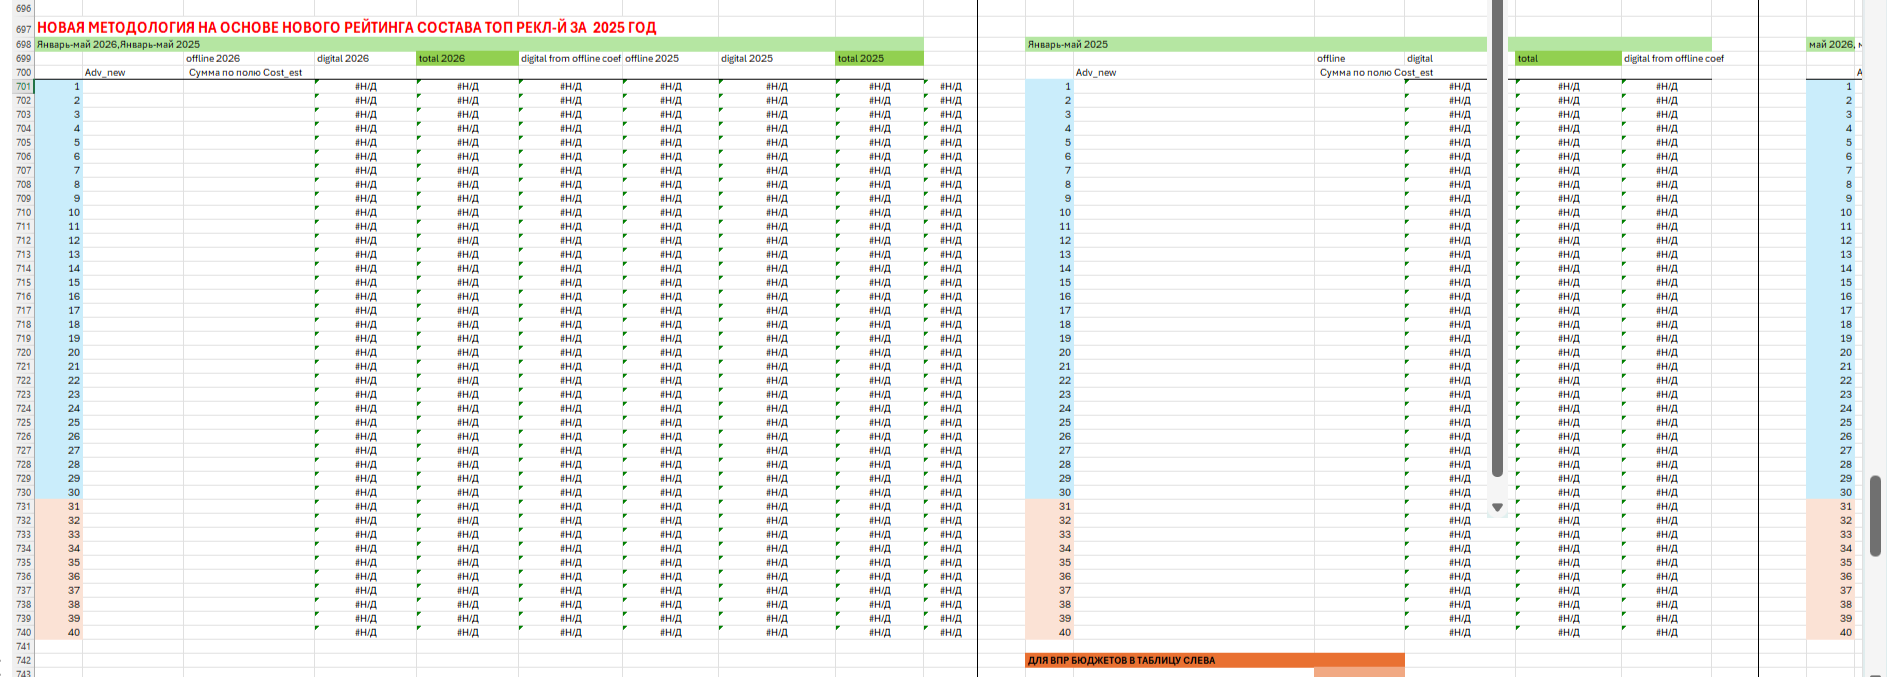

In [31]:
top_adveriser_investment_month, meta = read_top_advertisers_period(
    file_path=find_data_file(TOP_ADVERTISER_PATTERN,  MMO_DATA_ROOT, exclude=("forNB", )), 
    sheet_name="tops(with formula)",
    current_year=cur_year_adex,
    previous_year=last_year_adex,
    period_type='month'
)

display(meta)
display(top_adveriser_investment_month)

{'sheet_name': 'tops(with formula)',
 'period_type': 'month',
 'title': 'май 2026, май 2025',
 'month_num': 5,
 'title_row_excel': 571,
 'start_col_excel': 20,
 'manual_block': False}

,rank,advertiser_main,offline_2026,digital_2026,total_2026,offline_2025,digital_2025,total_2025,delta_total
573,1,WILDBERRIES,3946072581.70,3115130404.10,7061202985.80,2525855074.10,1993974458.09,4519829532.19,0.56
574,2,СБЕР,2376389335.25,2413464982.54,4789854317.79,1771903257.20,1799547910.88,3571451168.08,0.34
575,3,АЛЬФА-БАНК,1900903205.65,1215114934.50,3116018140.15,1230926589.15,786845578.09,2017772167.24,0.54
576,4,Т-ТЕХНОЛОГИИ,1225784002.85,866614576.50,2092398579.35,831722381.50,588017740.27,1419740121.77,0.47
577,5,ВТБ,1155983832.90,656629617.66,1812613450.56,1351330249.90,767591587.41,2118921837.31,-0.14
578,6,ВКУСНО - И ТОЧКА,985126295.90,428276413.57,1413402709.47,737032527.10,320419471.80,1057451998.90,0.34
579,7,ТАНДЕР,982995327.15,624316876.42,1607312203.57,704002620.00,447123912.57,1151126532.57,0.40
580,8,ИНТЕРНЕТ РЕШЕНИЯ,977881452.50,889225596.18,1867107048.68,565222230.95,513978533.91,1079200764.86,0.73
581,9,X5 GROUP,884166111.80,589179952.88,1473346064.68,922111747.30,614465707.94,1536577455.24,-0.04
582,10,T2,801185341.50,437337016.29,1238522357.79,604817734.20,330147307.46,934965041.66,0.32


In [32]:
for col in top_adveriser_investment_ytd.select_dtypes([str]).columns:
    top_adveriser_investment_ytd[col] = top_adveriser_investment_ytd[col].str.lower()

for col in top_adveriser_investment_month.select_dtypes([str]).columns:
    top_adveriser_investment_month[col] = top_adveriser_investment_month[col].str.lower()

top_adveriser_investment_ytd_for_merge = top_adveriser_investment_ytd.copy()
top_adveriser_investment_month_for_merge = top_adveriser_investment_month.copy()

### Теперь возьмем просто таблицу с offline затратами

In [33]:
offline_adex_df = pd.read_excel(find_data_file(TOP_ADVERTISER_PATTERN,  MMO_DATA_ROOT, exclude=("forNB", )), sheet_name="data_offline_2025-26")

In [34]:
tv_norm.head().T

,0,1,2,3,4
region_tv,сетевое вещание,тверь,москва,москва,кемерово
tv_duration,10,5,15,10,10
tv_comapny,тнт,россия 1,рен тв,россия 1,россия 1
ad_id_x,4811161,4800094,4637399,4798492,4843356
media_type_x,tv,tv,tv,tv,tv
media_type_detail,tv_nat,tv_reg,tv_reg,tv_reg,tv_reg
type_name,ролик,ролик,ролик,ролик,ролик
placement_name,o,l,l,l,l
date,2025-08-01 00:00:00,2025-07-01 00:00:00,2024-06-01 00:00:00,2025-07-01 00:00:00,2025-10-01 00:00:00
cost_rub_disc,42124.80,656.70,166566.95,253305.25,12580.15


In [35]:
for col in offline_adex_df.select_dtypes([str, object]).columns:
    offline_adex_df[col] = offline_adex_df[col].str.strip().str.lower()

offline_adex_df.columns = offline_adex_df.columns.str.lower().str.strip()
offline_adex_df.rename(columns={"cost est": "cost_rub_disc", "month": "year_month", "month num": "month", "media type": "media_type_old", "media type_new": "media_type"}, inplace=True)

offline_adex_df.loc[offline_adex_df['media_type_old'] == 'outdoor', 'media_type'] = 'outdoor'
offline_adex_df['date'] = pd.to_datetime(
    dict(
        year=offline_adex_df['year'],
        month=offline_adex_df['month'],
        day=1
    )
)

In [36]:
offline_adex_df

,advertiser_main,advertiser,brands list,year_month,month,year,media_type_old,media_type,placement,region,advertisement type,cost rub,volume,quantity,cost_rub_disc,date
0,NaN,NaN,NaN,2025-01-01,1,2025,tv,tv reg,локальный,санкт-петербург,нестандартная реклама,0,11.00,193.00,0.00,2025-01-01
1,NaN,NaN,NaN,2025-01-01,1,2025,tv,tv reg,локальный,тверь,нестандартная реклама,0,16.00,56.00,0.00,2025-01-01
2,NaN,NaN,NaN,2025-01-01,1,2025,tv,tv reg,локальный,нижний новгород,нестандартная реклама,0,20.00,371.00,0.00,2025-01-01
3,NaN,NaN,NaN,2025-01-01,1,2025,tv,tv reg,локальный,волгоград,нестандартная реклама,0,1.00,5.00,0.00,2025-01-01
4,NaN,NaN,NaN,2025-01-01,1,2025,tv,tv reg,локальный,самара,нестандартная реклама,0,6.00,61.00,0.00,2025-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681718,творческая мастерская елены литвиненко,творческая мастерская елены литвиненко,творческая мастерская елены литвиненко,2026-05-01,5,2026,tv,tv nat,сетевой,сетевое вещание,спонсор,0,1.00,0.00,0.00,2026-05-01
681719,rudnev.pro,rudnev.pro,rudnev.pro,2026-05-01,5,2026,tv,tv nat,сетевой,сетевое вещание,спонсор,0,1.00,0.00,0.00,2026-05-01
681720,ig-pro technical production,ig-pro technical production,ig-pro technical production,2026-05-01,5,2026,tv,tv nat,сетевой,сетевое вещание,спонсор,0,1.00,0.00,0.00,2026-05-01
681721,d-construction,d-construction,d-construction,2026-05-01,5,2026,tv,tv nat,сетевой,сетевое вещание,спонсор,0,1.00,0.00,0.00,2026-05-01


### Теперь возьмем таблицу с рейтингами по брендам

In [37]:
tvr_brands_df = pd.read_excel(find_data_file(TOP_NATTV_BRANDS_PATTERN,  MMO_DATA_ROOT), sheet_name='ТОП помесячный')
tvr_brands_df.columns = tvr_brands_df.columns.str.lower().str.strip()

for col in tvr_brands_df.select_dtypes(['str', 'object']).columns:
    tvr_brands_df[col] = tvr_brands_df[col].str.lower().str.strip()

tvr_brands_df = tvr_brands_df.rename(columns={'month': 'date', 'month№': 'month', 'brandname': 'brand_main'})

### Теперь возьмем таблицу с `digital` расходами по оперком брендам 

In [38]:
from datetime import datetime

digital_adex = pd.read_excel(find_data_file("X5_DigitalInvestments_jan'2024*.xlsx",  DIGITAL_DATA_ROOT), sheet_name="data")

digital_adex['date'] = pd.to_datetime(digital_adex['year'].astype(str) + '-' + digital_adex['month'].astype(str) + '-01')
digital_adex.rename(columns={'cost_estimated': 'cost_rub_disc', 'advertiser': 'advertiser_main'}, inplace=True)

for col in digital_adex.select_dtypes([object, str]):
    digital_adex[col] = digital_adex[col].str.lower().str.strip()

digital_adex['media_type_detail'] = 'digital' 

# Оставим только нужные бренды и приведём их в `правильные` названия
digital_adex = digital_adex[digital_adex['brand_main'].isin(OPERCOM_BRANDS)]
digital_adex['brand_main'] = digital_adex['brand_main'].apply(clean_brand_name)

In [39]:
digital_adex

,brand_main,brand_segment,advertiser_main,brand,delivery,site,marketing_channel,date,year,quarter,month,paid_marketing_channels,cost_NOT_FOR_USE,cost_rub_disc,help,coef,media_type_detail
0,перекресток,оперком,x5 group,перекресток,оффлайн,perekrestok.ru,direct,2024-01-01,2024,1,1,0,0.00,0.00,20241перекресток,0.00,digital
1,перекресток,оперком,x5 group,перекресток,оффлайн,perekrestok.ru,direct,2024-02-01,2024,1,2,0,0.00,0.00,20242перекресток,0.00,digital
2,перекресток,оперком,x5 group,перекресток,оффлайн,perekrestok.ru,direct,2024-03-01,2024,1,3,0,0.00,0.00,20243перекресток,0.01,digital
3,перекресток,оперком,x5 group,перекресток,оффлайн,perekrestok.ru,direct,2024-04-01,2024,2,4,0,0.00,0.00,20244перекресток,0.03,digital
4,перекресток,оперком,x5 group,перекресток,оффлайн,perekrestok.ru,direct,2024-05-01,2024,2,5,0,0.00,0.00,20245перекресток,0.02,digital
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47437,ozon fresh,доп,интернет решения,ozon,доставка/оффлайн,ozon.ru,online_video,2026-06-01,2026,2,6,1,2901484.80,0.00,20266ozon fresh,0.00,digital
47438,ozon fresh,доп,интернет решения,ozon,доставка/оффлайн,ozon.ru,online_video,2026-06-01,2026,2,6,1,3055968.00,0.00,20266ozon fresh,0.00,digital
47439,ozon fresh,доп,интернет решения,ozon,доставка/оффлайн,ozon.ru,online_video,2026-06-01,2026,2,6,1,3223929.60,0.00,20266ozon fresh,0.00,digital
47440,ozon fresh,доп,интернет решения,ozon,доставка/оффлайн,ozon.ru,online_video,2026-06-01,2026,2,6,1,2479766.40,0.00,20266ozon fresh,0.00,digital


---

In [40]:
cur_month_adex_mmo = offline_adex_df.date.max().month
cur_month_adex_mmo

5

In [41]:
cur_month_rate_mmo = tvr_brands_df.date.max().month
cur_month_rate_mmo

6

# Импортируем нужные функции для построения

In [42]:
from functions.build_tables import *

# Начнём строить таблицы

In [183]:
dataframes = {}
dataframes.clear()

In [184]:
df_ytd_slide = renamer_jan_cur_month(make_top_advertisers_view(
    top_adveriser_investment_ytd,
    top_n=40,
    required_advertisers=("ТАНДЕР", "X5 GROUP"),
    strict_top_n=False,
)[["advertiser_main", f"total_{last_year_adex}", f"total_{cur_year_adex}"]], cur_month_adex_mmo)


df_month_slide =  rename_to_month(make_top_advertisers_view(
    top_adveriser_investment_month,
    top_n=40,
    required_advertisers=("ТАНДЕР", "X5 GROUP"),
    strict_top_n=False,
)[["advertiser_main", f"total_{last_year_adex}", f"total_{cur_year_adex}"]], cur_month_adex_mmo)

## Слайд 4 верхняя таблица

In [185]:
dataframes['market_top20_invest_ytd'] = df_ytd_slide.copy().set_index('advertiser_main')[:20]
dataframes['market_top20_invest_ytd']

,янв-май'25,янв-май'26
advertiser_main,,
wildberries,18936400932.62,31299424595.94
сбер,21688449746.94,26919410735.75
интернет решения,12785728149.49,15850543050.80
т-технологии,11583858166.11,12585192767.46
альфа-банк,8026694856.02,12072800425.89
втб,12421097082.85,9845654977.01
мегафон,5411794661.02,8467041846.62
мтс,6093823639.46,7899332071.13
вкусно - и точка,5616400068.80,6987892529.38


In [186]:
dataframes['market_top20_invest_labels_ytd'] = find_diff_between_periods(dataframes['market_top20_invest_ytd'])
dataframes['market_top20_invest_labels_ytd']

,diff
advertiser_main,
wildberries,0.65
сбер,0.24
интернет решения,0.24
т-технологии,0.09
альфа-банк,0.50
втб,-0.21
мегафон,0.56
мтс,0.30
вкусно - и точка,0.24


## Слайд 4 нижняя таблица

In [187]:
dataframes['market_top20_media_mix_ytd'] = filter_indexes(build_media_mix_from_adv(
                                                        offline_adex_df, 
                                                        indexes=['advertiser_main'],
                                                        cols=['media_type'],
                                                        estimate_col='cost_rub_disc',
                                                        top_advertisers=top_adveriser_investment_ytd,
                                                        key_order_df=df_ytd_slide,
                                                        cur_year=cur_year_adex,
                                                        dates=make_interval_jan_to_cur_month(cur_year_adex, cur_month_adex_mmo),
                                            ).rename(columns=renamer_media_type)[:20], columns=media_type_order)
dataframes['market_top20_media_mix_ytd']

,Нац ТВ,Рег ТВ,Интернет,OOH,Радио,Пресса
advertiser_main,,,,,,
wildberries,4613350919.70,0.00,13808098901.24,12747352207.00,189664666.00,8194500.00
сбер,8070073140.30,324636659.05,13563889598.90,3692765885.00,1173928563.25,104679488.25
интернет решения,7301644544.70,325279540.85,7548955805.25,559533469.00,114790184.00,1668750.00
т-технологии,6127989242.10,18793533.55,5212444516.06,381496941.00,824043431.00,20756373.75
альфа-банк,6161779487.10,448629.50,4707880198.04,643124683.00,541052406.00,18799454.25
втб,4674929240.40,41127.90,3566644979.46,1431340890.00,190470611.00,11886371.25
мегафон,5608965728.40,0.00,2755393038.72,102547832.00,0.00,135247.50
мтс,3844741974.90,104860964.45,3012658177.28,602400399.00,340372279.25,1136462.25
вкусно - и точка,4296260661.90,0.00,2117407537.73,561207984.00,23190168.75,0.00


---

## Слайд 5 верхняя таблица

In [188]:
dataframes['market_top20_invest_month'] = df_month_slide.copy().set_index('advertiser_main')[:20]
dataframes['market_top20_invest_month']

,май'25,май'26
advertiser_main,,
wildberries,4519829532.19,7061202985.80
сбер,3571451168.08,4789854317.79
альфа-банк,2017772167.24,3116018140.15
т-технологии,1419740121.77,2092398579.35
втб,2118921837.31,1812613450.56
вкусно - и точка,1057451998.90,1413402709.47
тандер,1151126532.57,1607312203.57
интернет решения,1079200764.86,1867107048.68
x5 group,1536577455.24,1473346064.68


In [189]:
dataframes['market_top20_invest_labels_month'] = find_diff_between_periods(dataframes['market_top20_invest_month'])
dataframes['market_top20_invest_labels_month']

,diff
advertiser_main,
wildberries,0.56
сбер,0.34
альфа-банк,0.54
т-технологии,0.47
втб,-0.14
вкусно - и точка,0.34
тандер,0.40
интернет решения,0.73
x5 group,-0.04


## Слайд 5 нижняя таблица

In [190]:
dataframes['market_top20_media_mix_month'] = filter_indexes(build_media_mix_from_adv(
                                                offline_adex_df, 
                                                indexes=['advertiser_main'],
                                                cols=['media_type'],
                                                estimate_col='cost_rub_disc',
                                                top_advertisers=top_adveriser_investment_month,
                                                key_order_df=df_month_slide,
                                                cur_year=cur_year_adex,
                                                dates=[f"{cur_year_adex}-{cur_month_adex_mmo}-01"],
                                            ).rename(columns=renamer_media_type)[:20], columns=media_type_order)
dataframes['market_top20_media_mix_month']

,Нац ТВ,Рег ТВ,Интернет,OOH,Радио,Пресса
advertiser_main,,,,,,
wildberries,1265462498.70,0.00,3115130404.10,2599497866.00,92002256.00,3312000.00
сбер,1295912457.60,93657749.90,2413464982.54,753053628.00,201867212.75,33027375.00
альфа-банк,1610416995.60,30478.80,1215114934.50,112973982.00,177766181.25,0.00
т-технологии,1036489831.20,5429109.40,866614576.50,51522214.00,128986598.25,3356250.00
втб,856572618.90,0.00,656629617.66,244842509.00,59478450.00,0.00
вкусно - и точка,833439978.90,0.00,428276413.57,154034371.00,0.00,0.00
тандер,657400010.10,177128072.55,624316876.42,88193539.00,60982712.50,525000.00
интернет решения,820537176.00,53398526.50,889225596.18,91663609.00,12373245.00,0.00
x5 group,375797818.80,305057681.50,589179952.88,173348934.00,30662867.50,1132008.00


---

### Если что насчет несходоса по следующим слайдам по рейтингам: 
#### Я посмотрел откуда были взяты данные(из базы old по март), я же беру актуальную базу по апрель. В ней данные изменены.

## Слайд 6 верхняя таблица

In [191]:
dataframes['nat_tv_top_brands_ytd'] = renamer_jan_cur_month(build_table(
                                            tvr_brands_df,
                                            indexes=['brand_main'],
                                            cols=['year'],
                                            estimate_col='tvr all 18+',
                                            dates=list(pd.date_range(f"{last_year_rate}-01-01", f"{last_year_rate}-{str(cur_month_rate_mmo).rjust(2, '0')}-01")) + list(pd.date_range(f"{cur_year_rate}-01-01", f"{cur_year_rate}-{str(cur_month_rate_mmo).rjust(2, '0')}-01"))
                                        ).sort_values(cur_year_adex, ascending=False)[:20], cur_month_rate_mmo)

dataframes['nat_tv_top_brands_ytd']

year,янв-июн'25,янв-июн'26
brand_main,,
ozon,76913.49,84182.58
альфа-банк,58974.62,79739.52
wildberries,46423.80,76248.61
avito,46102.89,53689.27
вкусно - и точка,55412.73,50389.72
сбер,31659.31,49571.79
втб,62417.60,44485.97
магнит (сеть магазинов),50143.64,43014.39
яндекс,54010.90,41655.12


In [192]:
dataframes['nat_tv_summary'] = renamer_jan_cur_month(build_table(
                                            tvr_brands_df,
                                            indexes=['brand_main'],
                                            cols=['year'],
                                            estimate_col='tvr all 18+',
                                            dates=list(pd.date_range(f"{last_year_rate}-01-01", f"{last_year_rate}-{str(cur_month_rate_mmo).rjust(2, '0')}-01")) + list(pd.date_range(f"{cur_year_rate}-01-01", f"{cur_year_rate}-{str(cur_month_rate_mmo).rjust(2, '0')}-01"))
                                        ).sort_values(cur_year_adex, ascending=False), cur_month_rate_mmo).loc[['пятерочка', 'перекресток', 'чижик (супермаркет)']]

dataframes['nat_tv_summary']

year,янв-июн'25,янв-июн'26
brand_main,,
пятерочка,30377.40,26453.25
перекресток,3505.90,5948.71
чижик (супермаркет),9.15,111.65


In [193]:
dataframes['nat_tv_top_brands_delta_ytd'] = find_diff_between_periods(dataframes['nat_tv_top_brands_ytd'])
dataframes['nat_tv_top_brands_delta_ytd']

,diff
brand_main,
ozon,0.09
альфа-банк,0.35
wildberries,0.64
avito,0.16
вкусно - и точка,-0.09
сбер,0.57
втб,-0.29
магнит (сеть магазинов),-0.14
яндекс,-0.23


---

## Слайд 7 верхняя таблица

In [194]:
dataframes['nat_tv_top_brands_ytd_extended'] = renamer_jan_cur_month(build_table(
                                            tvr_brands_df,
                                            indexes=['brand_main'],
                                            cols=['year'],
                                            estimate_col='stand tvr all 18+',
                                            dates=list(pd.date_range(f"{last_year_rate}-01-01", f"{last_year_rate}-{str(cur_month_rate_mmo).rjust(2, '0')}-01")) + list(pd.date_range(f"{cur_year_rate}-01-01", f"{cur_year_rate}-{str(cur_month_rate_mmo).rjust(2, '0')}-01"))
                                        ).sort_values(cur_year_adex, ascending=False)[:20], cur_month_rate_mmo)

dataframes['nat_tv_top_brands_ytd_extended']

year,янв-июн'25,янв-июн'26
brand_main,,
альфа-банк,56664.40,72935.76
ozon,55846.54,63177.89
втб,70138.51,52245.92
wildberries,33789.28,51125.84
сбер,27644.48,43442.74
avito,37715.06,43130.60
т-банк,61003.66,42885.82
мегафон,27891.99,40622.47
сбер банк,57211.82,39340.48


In [195]:
dataframes['nat_tv_extended_summary'] = renamer_jan_cur_month(build_table(
                    tvr_brands_df,
                    indexes=['brand_main'],
                    cols=['year'],
                    estimate_col='stand tvr all 18+',
                    dates=list(pd.date_range(f"{last_year_rate}-01-01", f"{last_year_rate}-{str(cur_month_rate_mmo).rjust(2, '0')}-01")) + list(pd.date_range(f"{cur_year_rate}-01-01", f"{cur_year_rate}-{str(cur_month_rate_mmo).rjust(2, '0')}-01"))
                ).sort_values(cur_year_adex, ascending=False), cur_month_rate_mmo).loc[['пятерочка', 'перекресток', 'чижик (супермаркет)']]

dataframes['nat_tv_extended_summary']

year,янв-июн'25,янв-июн'26
brand_main,,
пятерочка,20289.78,16814.55
перекресток,3577.79,2911.10
чижик (супермаркет),10.82,58.91


In [196]:
dataframes['nat_tv_extended_labels'] = find_diff_between_periods(dataframes['nat_tv_top_brands_ytd_extended'])
dataframes['nat_tv_extended_labels']

,diff
brand_main,
альфа-банк,0.29
ozon,0.13
втб,-0.26
wildberries,0.51
сбер,0.57
avito,0.14
т-банк,-0.30
мегафон,0.46
сбер банк,-0.31


---

## Слайд 8 верхняя таблица

In [197]:
dataframes['nat_tv_top_brands_month'] = rename_to_month(build_table(
                                            tvr_brands_df,
                                            indexes=['brand_main'],
                                            cols=['year'],
                                            estimate_col='tvr all 18+',
                                            dates=[f"{last_year_rate}-{str(cur_month_rate_mmo).rjust(2, '0')}-01", f"{cur_year_rate}-{str(cur_month_rate_mmo).rjust(2, '0')}-01"],
                                        ).sort_values(cur_year_adex, ascending=False)[:20], cur_month_rate_mmo)

dataframes['nat_tv_top_brands_month']

year,июн'25,июн'26
brand_main,,
ozon,13365.33,19012.60
альфа-банк,14064.28,13892.31
втб,6857.07,13657.98
магнит,0.00,11527.03
wildberries,15356.16,10738.68
avito,8308.53,9292.20
сбер банк,12709.93,8680.10
яндекс,6397.81,8383.73
совкомбанк,7407.26,6165.45


In [198]:
dataframes['nat_tv_month_labels'] = find_diff_between_periods(dataframes['nat_tv_top_brands_month'])
dataframes['nat_tv_month_labels']

,diff
brand_main,
ozon,0.42
альфа-банк,-0.01
втб,0.99
магнит,new
wildberries,-0.30
avito,0.12
сбер банк,-0.32
яндекс,0.31
совкомбанк,-0.17


---

## Слайд 9 верхняя таблица

In [199]:
dataframes['nat_tv_top_brands_month_extended'] = rename_to_month(build_table(
                                            tvr_brands_df,
                                            indexes=['brand_main'],
                                            cols=['year'],
                                            estimate_col='stand tvr all 18+',
                                            dates=[f"{last_year_rate}-{str(cur_month_rate_mmo).rjust(2, '0')}-01", f"{cur_year_rate}-{str(cur_month_rate_mmo).rjust(2, '0')}-01"],
                                        ).sort_values(cur_year_adex, ascending=False)[:20], cur_month_rate_mmo)

dataframes['nat_tv_top_brands_month_extended']

year,июн'25,июн'26
brand_main,,
альфа-банк,14184.28,14955.43
ozon,10746.19,14361.39
втб,9029.59,14330.68
avito,5179.74,9412.61
wildberries,10324.20,7937.85
мтс,3808.06,6487.21
сбер банк,10501.49,6375.61
магнит,0.00,6327.78
совкомбанк,6069.45,6163.22


In [200]:
dataframes['nat_tv_month_extended_labels'] = find_diff_between_periods(dataframes['nat_tv_top_brands_month_extended'])
dataframes['nat_tv_month_extended_labels']

,diff
brand_main,
альфа-банк,0.05
ozon,0.34
втб,0.59
avito,0.82
wildberries,-0.23
мтс,0.70
сбер банк,-0.39
магнит,new
совкомбанк,0.02


---

# Фуд Ритейл

## Слайд 11 верхний график

#### Определим общий порядок брендов для 3-ех последующих таблиц

In [201]:
all_brands_order = build_table(
    tv_norm[~tv_norm['media_type_detail'].isin(['tv_spon'])],
    indexes=['brand_main'],
    cols=['year'],
    estimate_col='cost_rub_disc',
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{last_year_adex}-12-01")
).sort_values(by=last_year_adex, ascending=False).index.tolist()

all_brands_order

['магнит',
 'самокат',
 'пятерочка',
 'купер',
 'яндекс.лавка',
 'лента',
 'чижик',
 'ашан',
 'перекресток',
 'дикси',
 'metro',
 'spar',
 'ozon fresh',
 'монетка',
 "о'кей",
 'вкусвилл']

In [202]:
dataframes['all_retail_brand_yoy'] = add_empty_col(sort_necessary_cols(renamer_jan_cur_month(build_table(
    tv_norm[~tv_norm['media_type_detail'].isin(['tv_spon'])],
    indexes=['brand_main'],
    cols=['year'],
    estimate_col='cost_rub_disc',
    dates=make_interval_jan_to_cur_month(last_year_adex-1, cur_month_adex) + make_interval_jan_to_cur_month(last_year_adex, cur_month_adex) + make_interval_jan_to_cur_month(cur_year_adex, cur_month_adex)
), cur_month_adex).T, all_brands_order))

dataframes['all_retail_brand_yoy']

brand_main,магнит,самокат,пятерочка,купер,яндекс.лавка,лента,чижик,ашан,перекресток,дикси,metro,spar,ozon fresh,монетка,о'кей,вкусвилл,
year,,,,,,,,,,,,,,,,,
янв-май'24,1205549562.50,1378885960.50,1099471727.15,1188252989.60,259874657.35,274677315.55,715.00,163500777.55,190795385.55,159669428.05,58286848.95,71404382.50,201207025.25,7745205.05,72033456.00,21014174.50,0
янв-май'25,2393781248.45,1561300584.40,1618757352.65,505228843.20,461592362.55,365252054.20,298133463.10,387176092.60,354783545.05,222860895.95,108929027.90,102844097.95,72263251.50,24296050.35,17895669.00,2994670.25,0
янв-май'26,2910971251.05,1711689638.25,2439980450.95,887240094.30,0.00,73561494.05,542657020.95,114453297.20,650314336.25,299795982.75,86886980.95,106183935.00,174368013.05,21842667.55,23920288.15,0.00,0


In [203]:
dataframes['all_retail_brand_yoy_labels'] = find_diff_between_periods(dataframes['all_retail_brand_yoy'].iloc[1:].T)
dataframes['all_retail_brand_yoy_labels']

,diff
brand_main,
магнит,0.22
самокат,0.10
пятерочка,0.51
купер,0.76
яндекс.лавка,-1.00
лента,-0.80
чижик,0.82
ашан,-0.70
перекресток,0.83


## Слайд 11 нижняя левая таблица

In [204]:
dataframes['all_retail_tv_invest_year'] = sort_necessary_cols(add_total(rename_month_year(add_empty_month(build_table(
    tv_norm[~tv_norm['media_type_detail'].isin(['tv_spon'])],
    indexes=['brand_main'],
    cols=['date'],
    estimate_col='cost_rub_disc',
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{cur_year_adex}-{str(12).rjust(2, "0")}-01", freq='MS')
).T))), all_brands_order)

dataframes['all_retail_tv_invest_year']

brand_main,магнит,самокат,пятерочка,купер,яндекс.лавка,лента,чижик,ашан,перекресток,дикси,metro,spar,ozon fresh,монетка,о'кей,вкусвилл,total
янв.25,227745021.95,154584600.50,175770391.55,0.00,99049639.15,16809663.75,24271801.40,0.00,38097534.20,23861140.05,7161417.45,11737189.75,5947141.75,2936882.30,0.00,0.00,787972423.80
фев.25,497143624.80,202181397.55,277140638.25,299674912.50,116498107.00,116337513.60,37632263.90,130043552.65,53110189.55,53655643.80,22857792.65,17638111.70,22008328.65,4518878.10,6652575.05,0.00,1857093529.75
мар.25,608619736.25,641743581.75,394114963.05,116628036.60,114207970.80,50707884.70,69650309.30,67125915.45,77828830.20,47527296.30,25846728.60,23721989.50,25124540.10,5914150.00,11243093.95,2994670.25,2282999696.80
апр.25,549740602.70,368787171.50,421908014.20,88925894.10,125248390.30,107147565.25,101217832.10,81809979.90,96681536.60,51523465.95,32331262.70,25028141.05,11260927.15,6554176.20,0.00,0.00,2068164959.70
май.25,510532262.75,194003833.10,349823345.60,0.00,6588255.30,74249426.90,65361256.40,108196644.60,89065454.50,46293349.85,20731826.50,24718665.95,7922313.85,4371963.75,0.00,0.00,1501858599.05
июн.25,368992343.55,181585952.90,271524759.85,0.00,45588887.30,23740022.35,94244181.35,69482925.05,48026504.90,32876690.55,0.00,15476098.00,13251872.15,3571356.25,0.00,0.00,1168361594.20
июл.25,315319369.00,256187949.05,214798206.90,29949516.90,74380194.90,4451077.40,43286120.35,43714837.10,34524139.10,27282705.45,0.00,14637706.60,10263768.90,2445944.60,0.00,0.00,1071241536.25
авг.25,392374884.55,780870417.85,261158969.40,257308407.30,81524550.80,208356225.00,45449669.10,126120976.85,60463725.30,53701444.50,5556366.20,16450338.85,7825297.70,3423661.45,6137065.00,0.00,2306721999.85
сен.25,874848784.55,1058656508.50,502929769.00,426407548.50,158551012.40,120466712.85,87891474.00,85366413.55,137956620.45,77124097.60,33466854.85,27300969.85,13228516.40,5691195.40,11948572.35,9013094.20,3630848144.45
окт.25,870037546.80,868321275.00,611165053.80,329102734.00,263668705.85,131662803.80,248078435.55,0.00,78626322.75,78273091.60,54498452.25,29582283.50,28469283.15,9273850.30,0.00,9009188.65,3609769027.00


## Слайд 11 нижняя правая таблица

In [205]:
dataframes['all_retail_tvr_dynamic'] = sort_necessary_cols(add_total(rename_month_year(add_empty_month(build_table(
    # [tv_rate_nat_norm[tv_rate_nat_norm['type_name'].isin(['ролик'])], tv_rate_reg_norm[tv_rate_reg_norm['type_name'].isin(['ролик'])]],
    [tv_rate_nat_norm[(tv_rate_nat_norm['media_type_detail'] == 'tv_nat')], tv_rate_reg_norm[(tv_rate_reg_norm['media_type_detail'] == 'tv_reg')]],
    indexes=['brand_main'],
    cols=['date'],
    estimate_col='tvr_18',
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{cur_year_rate}-{str(cur_month_rate).rjust(2, "0")}-01")
).T))), all_brands_order)

dataframes['all_retail_tvr_dynamic']

brand_main,магнит,самокат,пятерочка,купер,яндекс.лавка,лента,чижик,ашан,перекресток,дикси,metro,spar,ozon fresh,монетка,о'кей,вкусвилл,total
янв.25,6024.90,1245.08,4864.84,0.00,768.82,266.90,410.86,0.00,1014.85,537.39,223.39,264.06,33.08,34.17,0.00,0.00,15688.35
фев.25,8513.19,1159.55,4433.00,3059.32,699.44,943.72,412.01,1247.38,942.98,657.92,241.20,266.80,59.44,36.16,43.58,0.00,22715.71
мар.25,9850.47,5171.02,5662.37,1240.84,534.80,383.58,556.62,767.62,955.45,592.63,237.51,293.70,57.78,32.87,62.86,21.09,26421.23
апр.25,8444.73,1648.67,5948.45,832.19,605.64,1056.52,735.76,868.38,1085.84,634.54,287.29,287.89,30.63,34.52,0.00,0.00,22501.06
май.25,10245.39,1068.95,7290.50,0.00,43.50,997.31,689.92,1390.13,1143.87,688.43,237.40,316.06,26.07,29.84,0.00,0.00,24167.37
июн.25,6813.32,1082.53,4786.57,0.00,340.88,412.67,798.55,1039.01,708.12,495.75,0.00,227.71,37.89,29.08,0.00,0.00,16772.07
июл.25,7339.40,2199.95,5026.18,495.71,738.21,68.93,580.60,483.57,749.58,553.48,0.00,264.94,41.05,28.21,0.00,0.00,18569.79
авг.25,8023.32,7776.82,4612.82,3617.55,667.08,1121.73,505.20,1145.74,832.86,688.77,62.31,224.20,26.90,33.11,49.12,0.00,29387.53
сен.25,8891.34,5707.31,5564.70,3917.61,660.44,404.22,447.24,628.07,1062.21,693.92,188.99,226.66,24.34,28.69,47.68,32.22,28525.65
окт.25,10740.08,5428.44,6766.02,2400.88,785.47,883.25,1060.76,0.00,653.82,645.03,436.11,239.31,58.71,44.97,0.00,34.52,30177.37


---

## Слайд 12 левая таблица

In [206]:
dataframes['all_retail_sov_year'] = add_total(build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['advertiser_main'],
    cols=['brand_main'],
    estimate_col='cost_rub_disc',
    dates=[f"{cur_year_adex}-{cur_month_adex}-01"],
    requires_brands=['магнит', 'дикси', 'перекресток', 'пятерочка', 'чижик']
).loc[['тандер', 'x5 group']][['магнит', 'пятерочка', 'чижик', 'перекресток', 'дикси']])

dataframes['all_retail_sov_year']

brand_main,магнит,пятерочка,чижик,перекресток,дикси,total
advertiser_main,,,,,,
тандер,1147198273.62,0.00,0.00,0.00,110829487.99,1258027761.61
x5 group,0.00,993794308.15,171074976.37,175831994.15,0.00,1340701278.67


## Слайд 12 правая таблица

In [207]:
dataframes['all_retail_sov_month'] = rename_to_month(build_table(
    tv_norm,
    indexes=['brand_main'],
    cols=['year'],
    estimate_col='cost_rub_disc',
    dates=[f"{last_year_adex}-{str(cur_month_adex).rjust(2, '0')}-01", f"{cur_year_adex}-{str(cur_month_adex).rjust(2, '0')}-01"]
).sort_values(cur_year_adex, ascending=False), cur_month_adex)

dataframes['all_retail_sov_month']

year,май'25,май'26
brand_main,,
магнит,514589144.15,643126535.50
пятерочка,429694051.70,488686244.30
самокат,194003833.10,257153132.55
купер,1612434.90,210079575.60
чижик,65361256.40,101598296.00
перекресток,89125673.80,86927377.20
ozon fresh,32287283.60,53398526.50
дикси,46293349.85,46857936.95
ашан,108196644.60,44358130.30


In [208]:
dataframes['all_retail_tvr_month_labels'] = find_diff_between_periods(dataframes['all_retail_sov_month'])
dataframes['all_retail_tvr_month_labels']

,diff
brand_main,
магнит,0.25
пятерочка,0.14
самокат,0.33
купер,129.29
чижик,0.55
перекресток,-0.02
ozon fresh,0.65
дикси,0.01
ашан,-0.59


## Слайд 13 верхняя таблица

In [209]:
dataframes['pyaterochka_duration_nat'] = build_avg_duration_table(
    tv_rate_nat_norm[(tv_rate_nat_norm['type_name']=='ролик') & (tv_rate_nat_norm['brand_main']=='пятерочка') & (tv_rate_nat_norm['media_type_detail']=='tv_nat')],
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{cur_year_rate}-{str(cur_month_rate).rjust(2, "0")}-01")
)

dataframes['pyaterochka_duration_nat']

duration_bucket,5,10,15,20,25,,50,Ср.Хроно
date,,,,,,,,
янв.25,172.00,2771.00,0.00,0.00,0.00,0,0,9.71
фев.25,119.00,1776.00,339.00,261.00,325.00,0,0,13.04
мар.25,181.00,1875.00,895.00,764.00,355.00,0,0,14.06
апр.25,452.00,1691.00,635.00,826.00,711.00,0,0,14.60
май.25,2608.00,1729.00,531.00,516.00,195.00,0,0,9.59
июн.25,351.00,2001.00,381.00,151.00,353.00,0,0,12.15
июл.25,480.00,2030.00,250.00,266.00,238.00,0,0,11.56
авг.25,143.00,1383.00,1110.00,316.00,269.00,0,0,13.73
сен.25,176.00,2010.00,1078.00,368.00,336.00,0,0,13.33


## Слайд 13 нижняя таблица

In [210]:
dataframes['magnit_duration_nat'] = build_avg_duration_table(
    tv_rate_nat_norm[(tv_rate_nat_norm['type_name']=='ролик') & (tv_rate_nat_norm['brand_main']=='магнит') & (tv_rate_nat_norm['media_type_detail']=='tv_nat')],
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{cur_year_rate}-{str(cur_month_rate).rjust(2, "0")}-01")
)

dataframes['magnit_duration_nat']

duration_bucket,5,10,15,20,25,,50,Ср.Хроно
date,,,,,,,,
янв.25,0.00,4309.00,542.00,0.00,0,0,0,10.56
фев.25,447.00,5801.00,512.00,484.00,0,0,0,10.71
мар.25,956.00,7077.00,0.00,490.00,0,0,0,10.01
апр.25,291.00,5967.00,699.00,190.00,0,0,0,10.55
май.25,826.00,7794.00,0.00,405.00,0,0,0,9.99
июн.25,411.00,4803.00,184.00,375.00,0,0,0,10.45
июл.25,0.00,5413.00,692.00,102.00,0,0,0,10.72
авг.25,696.00,5584.00,0.00,497.00,0,0,0,10.22
сен.25,281.00,5307.00,556.00,1537.00,0,0,0,12.18


In [211]:
pyaterka = build_chrono_rating_table(
    dfs=tv_rate_nat_norm[(tv_rate_nat_norm['brand_main']=='пятерочка') & (tv_rate_nat_norm['media_type_detail']=='tv_nat')],
    last_year=last_year_rate,
    cur_year=cur_year_rate,
    current_month=cur_month_rate,
    date_col="date",
    segment_col="message_type",
    rating_col="tvr_18",
    chrono_col="tv_duration",
    promo_values=("промо",),
    image_values=("имидж",),
    chrono_method="weighted",
)

magnit = build_chrono_rating_table(
    dfs=tv_rate_nat_norm[(tv_rate_nat_norm['brand_main']=='магнит') & (tv_rate_nat_norm['media_type_detail']=='tv_nat')],
    last_year=last_year_rate,
    cur_year=cur_year_rate,
    current_month=cur_month_rate,
    date_col="date",
    segment_col="message_type",
    rating_col="tvr_18",
    chrono_col="tv_duration",
    promo_values=("промо",),
    image_values=("имидж",),
    chrono_method="weighted",
)

separator = pd.DataFrame([[0] * len(pyaterka.columns)], columns=pyaterka.columns)

dataframes['nat_duration_table'] = pd.concat([pyaterka, separator, magnit])
dataframes['nat_duration_table']

_period_group,Q1'25,Q2'25,Q3'25,Q4'25,янв.26,фев.26,мар.26,апр.26,май.26,июн.26
Промо,12.34,11.35,12.45,13.58,9.52,12.62,11.81,14.19,13.59,12.33
Имидж,17.35,15.28,16.26,0.00,0.00,0.00,0.00,0.00,0.00,9.71
Итого,12.47,11.87,12.90,13.58,9.52,12.62,11.81,14.19,13.59,12.20
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Промо,10.40,10.06,11.11,10.66,12.79,10.57,10.72,10.30,10.76,11.34
Имидж,10.00,16.67,10.00,10.00,0.00,14.72,15.00,13.39,14.60,10.00
Итого,10.39,10.30,11.10,10.65,12.79,11.63,10.85,10.68,11.28,11.23


---

## Слайд 14 верхняя таблица

In [212]:
dataframes['pyaterochka_duration_reg'] = build_avg_duration_table(
    tv_rate_reg_norm[(tv_rate_reg_norm['type_name']=='ролик') & (tv_rate_reg_norm['brand_main']=='пятерочка') & (tv_rate_reg_norm['media_type_detail']=='tv_reg')],
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{cur_year_rate}-{str(cur_month_rate).rjust(2, "0")}-01")
)

dataframes['pyaterochka_duration_reg']

duration_bucket,5,10,15,20,25,,50,Ср.Хроно
date,,,,,,,,
янв.25,1088.00,834.00,0.00,0,0.00,0,0.00,7.17
фев.25,967.00,647.00,0.00,0,0.00,0,0.00,7.00
мар.25,939.00,653.00,0.00,0,0.00,0,0.00,7.05
апр.25,1002.00,631.00,0.00,0,0.00,0,0.00,6.93
май.25,1009.00,703.00,0.00,0,0.00,0,0.00,7.05
июн.25,973.00,576.00,0.00,0,0.00,0,0.00,6.86
июл.25,1149.00,614.00,0.00,0,0.00,0,0.00,6.74
авг.25,868.00,525.00,0.00,0,0.00,0,0.00,6.88
сен.25,1171.00,411.00,15.00,0,0.00,0,0.00,6.38


## Слайд 14 нижняя таблица

In [213]:
dataframes['magnit_duration_reg'] = build_avg_duration_table(
    tv_rate_reg_norm[(tv_rate_reg_norm['type_name']=='ролик') & (tv_rate_reg_norm['brand_main']=='магнит') & (tv_rate_reg_norm['media_type_detail']=='tv_reg')],
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{cur_year_rate}-{str(cur_month_rate).rjust(2, "0")}-01")
)

dataframes['magnit_duration_reg']

duration_bucket,5,10,15,20,25,,50,Ср.Хроно
date,,,,,,,,
янв.25,494.00,539.00,140.00,0.00,0,0,0,8.49
фев.25,446.00,754.00,68.00,0.00,0,0,0,8.51
мар.25,422.00,906.00,0.00,0.00,0,0,0,8.41
апр.25,440.00,858.00,0.00,0.00,0,0,0,8.31
май.25,360.00,860.00,0.00,0.00,0,0,0,8.52
июн.25,332.00,708.00,0.00,0.00,0,0,0,8.40
июл.25,312.00,820.00,0.00,0.00,0,0,0,8.62
авг.25,355.00,891.00,0.00,0.00,0,0,0,8.58
сен.25,344.00,794.00,0.00,72.00,0,0,0,9.17


In [214]:
pyaterka = build_chrono_rating_table(
    dfs=tv_rate_reg_norm[(tv_rate_reg_norm['brand_main']=='пятерочка') & (tv_rate_reg_norm['media_type_detail']=='tv_reg')],
    last_year=last_year_rate,
    cur_year=cur_year_rate,
    current_month=cur_month_rate,
    date_col="date",
    segment_col="message_type",
    rating_col="tvr_18",
    chrono_col="tv_duration",
    promo_values=("промо",),
    image_values=("имидж",),
    chrono_method="weighted",
)

magnit = build_chrono_rating_table(
    dfs=tv_rate_reg_norm[(tv_rate_reg_norm['brand_main']=='магнит') & (tv_rate_reg_norm['media_type_detail']=='tv_reg')],
    last_year=last_year_rate,
    cur_year=cur_year_rate,
    current_month=cur_month_rate,
    date_col="date",
    segment_col="message_type",
    rating_col="tvr_18",
    chrono_col="tv_duration",
    promo_values=("промо",),
    image_values=("имидж",),
    chrono_method="weighted",
)

separator = pd.DataFrame([[0] * len(pyaterka.columns)], columns=pyaterka.columns)

dataframes['reg_duration_table'] = pd.concat([pyaterka, separator, magnit])
dataframes['reg_duration_table']

_period_group,Q1'25,Q2'25,Q3'25,Q4'25,янв.26,фев.26,мар.26,апр.26,май.26,июн.26
Промо,7.08,6.95,6.66,7.40,6.59,6.91,7.16,6.46,6.19,6.13
Имидж,0.00,0.00,0.00,109.15,0.00,0.00,0.00,0.00,0.00,0.00
Итого,7.08,6.95,6.66,7.40,6.59,6.91,7.16,6.46,6.19,6.13
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Промо,8.47,8.41,8.79,8.60,10.00,10.00,10.00,10.00,10.00,10.00
Имидж,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Итого,8.47,8.41,8.79,8.60,10.00,10.00,10.00,10.00,10.00,10.00


In [215]:
tv_rate_reg_norm.head().T

,1,4,7,10,11
ad_id_x,4722855,4699112,4631296,4680470,4884326
full_date,2024-12-30 00:00:00,2024-11-11 00:00:00,2024-06-10 00:00:00,2024-10-07 00:00:00,2026-03-01 00:00:00
ad_placement_id,o,n,n,l,n
type_name,ролик,ролик,ролик,ролик,ролик
tv_duration,5,10,5,5,15
regionName,пермь,санкт-петербург,москва,саратов,барнаул
media_type_detail,tv_nat,tv_nat,tv_nat,tv_reg,tv_nat
tvr_18,0.12,2.83,2.00,0.02,0.15
tvr_18_not_weighted,16.16,72.17,17.65,3.28,35.68
st_tvr,4.04,36.08,4.41,0.82,26.76


-------

## Правка на 14 слайде. Объяснение

In [216]:
test_df = tv_rate_reg_norm[
    (tv_rate_reg_norm['brand_main']=='пятерочка') 
    & (tv_rate_reg_norm['media_type_detail']=='tv_reg')
    & (tv_rate_reg_norm['date'].dt.quarter == 4)
    & (tv_rate_reg_norm['date'].dt.year == 2025)
].groupby("tv_duration").agg({"ad_id_x": "count", "tvr_18": "sum", "message_type": "unique"})
test_df

,ad_id_x,tvr_18,message_type
tv_duration,,,
5,2850,2822.26,[промо]
10,1398,1660.47,[промо]
15,135,323.78,[промо]
85,2,0.00,[имидж]
105,1,0.00,[имидж]
110,1,0.02,[имидж]


----------

In [217]:
dataframes['reg_duration_table']

_period_group,Q1'25,Q2'25,Q3'25,Q4'25,янв.26,фев.26,мар.26,апр.26,май.26,июн.26
Промо,7.08,6.95,6.66,7.40,6.59,6.91,7.16,6.46,6.19,6.13
Имидж,0.00,0.00,0.00,109.15,0.00,0.00,0.00,0.00,0.00,0.00
Итого,7.08,6.95,6.66,7.40,6.59,6.91,7.16,6.46,6.19,6.13
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Промо,8.47,8.41,8.79,8.60,10.00,10.00,10.00,10.00,10.00,10.00
Имидж,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Итого,8.47,8.41,8.79,8.60,10.00,10.00,10.00,10.00,10.00,10.00


---

## Слайд 15 верхняя таблица

In [218]:
build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['brand_main'],
    cols=['year'],
    estimate_col='cost_rub_disc',
    dates=make_interval_jan_to_cur_month(last_year_adex, cur_month_adex) + make_interval_jan_to_cur_month(cur_year_adex, cur_month_adex)
)

year,2025,2026
brand_main,,
globus,145471713.02,365451064.28
metro,537372594.42,715855374.25
ozon fresh,1245476292.82,2459245317.86
spar,164706931.24,157748098.81
азбука вкуса,25782770.22,23192061.58
ашан,844558756.54,573644750.83
вкусвилл,478057998.45,638659254.59
дикси,356684815.47,524083567.49
купер,1125607026.21,1670493352.18


In [219]:
dataframes['all_retail_total_split_yoy'] = renamer_jan_cur_month(build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['brand_main'],
    cols=['year'],
    estimate_col='cost_rub_disc',
    dates=make_interval_jan_to_cur_month(last_year_adex, cur_month_adex) + make_interval_jan_to_cur_month(cur_year_adex, cur_month_adex)
).sort_values(cur_year_adex, ascending=False), cur_month_adex)

dataframes['all_retail_total_split_yoy']

year,янв-май'25,янв-май'26
brand_main,,
магнит,3236761733.49,4874540722.63
пятерочка,3061402550.88,4408591302.74
самокат,2781134195.50,3171764159.65
ozon fresh,1245476292.82,2459245317.86
купер,1125607026.21,1670493352.18
перекресток,1112623880.38,1173455339.00
яндекс.лавка,1203900711.49,1038358550.74
чижик,632647702.17,985408035.94
лента,876839329.16,903228122.46


In [220]:
dataframes['all_retail_media_mix_labels'] = find_diff_between_periods(dataframes['all_retail_total_split_yoy'])
dataframes['all_retail_media_mix_labels']

,diff
brand_main,
магнит,0.51
пятерочка,0.44
самокат,0.14
ozon fresh,0.97
купер,0.48
перекресток,0.05
яндекс.лавка,-0.14
чижик,0.56
лента,0.03


## Слайд 15 нижняя таблица

In [221]:
dataframes['all_retail_media_mix_by_brand'] = filter_indexes(build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['brand_main'],
    cols=['media_type_detail'],
    estimate_col='cost_rub_disc',
    dates=make_interval_jan_to_cur_month(cur_year_adex, cur_month_adex)
).rename(columns=renamer_media_type).loc[dataframes['all_retail_total_split_yoy'].index], columns=media_type_order)

dataframes['all_retail_media_mix_by_brand']

media_type_detail,Нац ТВ,Рег ТВ,ТВ Спонсорство,Интернет,OOH,Радио,Пресса
brand_main,,,,,,,
магнит,2220073299.90,690897951.15,1264601.40,1536742808.68,301899193.00,123662868.50,0.00
пятерочка,1574597964.30,865382486.65,4608089.10,1335958374.94,517289684.00,109329703.75,1425000.00
самокат,1451380125.60,260309512.65,0.00,668111993.40,610088329.00,181874199.00,0.00
ozon fresh,0.00,174368013.05,150911527.80,1784612778.51,306342107.00,43010891.50,0.00
купер,887240094.30,0.00,24772241.05,326135710.58,239774951.00,190316415.50,2253939.75
перекресток,313883145.00,336431191.25,4961649.90,330319921.85,124151011.00,63708420.00,0.00
яндекс.лавка,0.00,0.00,0.00,806723498.74,231635052.00,0.00,0.00
чижик,9100621.20,533556399.75,545605.80,170812516.44,132683604.00,137584288.75,1125000.00
лента,0.00,73561494.05,25149.85,445573261.51,136720899.00,246360975.80,986342.25


---

## Слайд 16 левая таблица

In [222]:
dataframes['delivery_type_yoy'] = add_total(renamer_jan_cur_month(build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['delivery'],
    cols=['year'],
    estimate_col='cost_rub_disc',
    dates=make_interval_jan_to_cur_month(last_year_adex, cur_month_adex) + make_interval_jan_to_cur_month(cur_year_adex, cur_month_adex)
), cur_month_adex).T.rename(columns=renamer_delivery))[['Реклама офлайн магазинов', 'Смешанная реклама', 'Доставка', 'total']]

dataframes['delivery_type_yoy']

delivery,Реклама офлайн магазинов,Смешанная реклама,Доставка,total
year,,,,
янв-май'25,6622607957.24,2741196054.33,8765683693.96,18129487705.53
янв-май'26,10905389029.26,2126780520.46,11046975843.77,24079145393.50


## Слайд 16 правая таблица

In [223]:
dataframes['delivery_type_dynamic'] = flatten_brand_period_index_with_empty_rows(
    sort_grouped_by_period_total(
        add_total(
            renamer_jan_cur_month(
                build_table(
                    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
                    indexes=['delivery'],
                    cols=['brand_main', 'year'],
                    estimate_col='cost_rub_disc',
                    dates=make_interval_jan_to_cur_month(last_year_adex, cur_month_adex) + make_interval_jan_to_cur_month(cur_year_adex, cur_month_adex)
                    )
                , cur_month_adex).T
            ), 
        sort_period=f"янв-{months[cur_month_adex]}'{str(cur_year_adex)[2:]}").rename(columns=renamer_delivery)
    )[['Реклама офлайн магазинов', 'Смешанная реклама', 'Доставка']]

dataframes['delivery_type_dynamic']

delivery,Реклама офлайн магазинов,Смешанная реклама,Доставка
cat,,,
Магнит'25,2202570747.86,654065546.45,380125439.18
Магнит'26,4295312313.61,56197137.54,523031271.49
,0.00,0.00,0.00
Пятерочка'25,1372095118.01,1084640386.30,604667046.57
Пятерочка'26,2604821046.82,836257929.49,967512326.43
,0.00,0.00,0.00
Самокат'25,0.00,0.00,2781134195.50
Самокат'26,0.00,390887.00,3171373272.65
,0.00,0.00,0.00


---

# Оффлайн и смешанная реклама

#### Определим общий порядок брендов для 3-ех последующих таблиц

In [224]:
offline_brands_order = build_table(
    tv_norm[~(tv_norm['media_type_detail'].isin(['tv_spon']))],
    indexes=['brand_main'],
    cols=['year'],
    estimate_col='cost_rub_disc',
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{last_year_adex}-12-01"),
    mode='offline'
).sort_values(by=last_year_adex, ascending=False).index.tolist()

offline_brands_order

['магнит',
 'пятерочка',
 'лента',
 'чижик',
 'ашан',
 'дикси',
 'перекресток',
 'metro',
 'spar',
 'монетка',
 "о'кей",
 'вкусвилл']

## Слайд 18 верхний график

In [225]:
dataframes['offline_brand_yoy'] = sort_necessary_cols(add_empty_col(renamer_jan_cur_month(build_table(
    tv_norm[~(tv_norm['media_type_detail'].isin(['tv_spon']))],
    indexes=['brand_main'],
    cols=['year'],
    estimate_col='cost_rub_disc',
    dates=make_interval_jan_to_cur_month(cur_year_adex - 2, cur_month_adex) + make_interval_jan_to_cur_month(last_year_adex, cur_month_adex) + make_interval_jan_to_cur_month(cur_year_adex, cur_month_adex),
    mode='offline'
), cur_month_adex).T), offline_brands_order)

dataframes['offline_brand_yoy']

brand_main,магнит,пятерочка,лента,чижик,ашан,дикси,перекресток,metro,spar,монетка,о'кей,вкусвилл,
year,,,,,,,,,,,,,
янв-май'24,806713762.15,1099471727.15,273683161.40,715.00,0.00,159669428.05,190795385.55,58286848.95,71404382.50,7745205.05,72033456.00,3610944.15,0
янв-май'25,2159978243.90,1473398975.35,320985519.25,298133463.10,387176092.60,210020126.25,247823444.00,108929027.90,102844097.95,23763436.95,17895669.00,1608700.50,0
янв-май'26,2639057811.30,1941623825.40,71118358.85,535577901.65,114453297.20,298761747.35,395801429.25,86886980.95,106113957.95,20667479.25,23920288.15,0.00,0


In [226]:
dataframes['offline_brand_yoy_labels'] = find_diff_between_periods(dataframes['offline_brand_yoy'].iloc[1:].T)
dataframes['offline_brand_yoy_labels']

,diff
brand_main,
магнит,0.22
пятерочка,0.32
лента,-0.78
чижик,0.80
ашан,-0.70
дикси,0.42
перекресток,0.60
metro,-0.20
spar,0.03


## Слайд 18 нижняя левая таблица

In [227]:
dataframes['offline_invest_dynamic'] = sort_necessary_cols(add_total(rename_month_year(add_empty_month(build_table(
    tv_norm[~(tv_norm['media_type_detail'].isin(['tv_spon']))],
    indexes=['brand_main'],
    cols=['date'],
    estimate_col='cost_rub_disc',
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{cur_year_adex}-{str(cur_month_adex).rjust(2, "0")}-01"),
    mode='offline'
).T))), offline_brands_order)

dataframes['offline_invest_dynamic']

brand_main,магнит,пятерочка,лента,чижик,ашан,дикси,перекресток,metro,spar,монетка,о'кей,вкусвилл,total
янв.25,227745021.95,175770391.55,265794.65,24271801.40,0.00,11524286.95,37680427.95,7161417.45,11737189.75,2936882.30,0.00,0.00,499093213.95
фев.25,497143624.80,239621844.65,111478896.10,37632263.90,130043552.65,53655643.80,52314374.75,22857792.65,17638111.70,4518878.10,6652575.05,0.00,1173557558.15
мар.25,608619736.25,348210085.05,44454779.05,69650309.30,67125915.45,47527296.30,54246447.20,25846728.60,23721989.50,5914150.00,11243093.95,1608700.50,1308169231.15
апр.25,509604976.80,385989190.30,94227453.65,101217832.10,81809979.90,51523465.95,52876815.20,32331262.70,25028141.05,6554176.20,0.00,0.00,1341163293.85
май.25,316864884.10,323807463.80,70558595.80,65361256.40,108196644.60,45789433.25,50705378.90,20731826.50,24718665.95,3839350.35,0.00,0.00,1030573499.65
июн.25,365570972.55,270758242.45,18822562.55,94244181.35,69482925.05,32876690.55,46129048.90,0.00,15476098.00,1316804.50,0.00,0.00,914677525.90
июл.25,315319369.00,214798206.90,588734.30,43286120.35,43714837.10,27282705.45,34524139.10,0.00,14637706.60,1191527.15,0.00,0.00,695343345.95
авг.25,372324047.65,236105169.30,207785958.60,45449669.10,126120976.85,53701444.50,37155076.20,5556366.20,16450338.85,3285993.70,6137065.00,0.00,1110072105.95
сен.25,817109160.35,436050944.30,120466712.85,87891474.00,85366413.55,77124097.60,98590396.85,33466854.85,27300969.85,5691195.40,11948572.35,0.00,1801006791.95
окт.25,870037546.80,565427340.60,111137941.20,248078435.55,0.00,78273091.60,78626322.75,54498452.25,29582283.50,9273850.30,0.00,0.00,2044935264.55


## Слайд 18 нижняя правая таблица

In [228]:
dataframes['offline_tvr_dynamic'] = sort_necessary_cols(add_total(rename_month_year(add_empty_month(build_table(
    # [tv_rate_nat_norm[tv_rate_nat_norm['type_name'].isin(['ролик'])], tv_rate_reg_norm[tv_rate_reg_norm['type_name'].isin(['ролик'])]],
    [tv_rate_nat_norm[(tv_rate_nat_norm['media_type_detail'] == 'tv_nat')], tv_rate_reg_norm[(tv_rate_reg_norm['media_type_detail'] == 'tv_reg')]],
    indexes=['brand_main'],
    cols=['date'],
    estimate_col='tvr_18',
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{cur_year_rate}-{str(cur_month_rate).rjust(2, "0")}-01"),
    mode='offline'
).T))), offline_brands_order)

dataframes['offline_tvr_dynamic']

brand_main,магнит,пятерочка,лента,чижик,ашан,дикси,перекресток,metro,spar,монетка,о'кей,вкусвилл,ozon fresh,total
янв.25,6024.90,4864.84,5.64,410.86,0.00,266.36,997.84,223.39,264.06,34.17,0.00,0.00,0.00,13092.07
фев.25,8513.19,3821.90,888.86,412.01,1247.38,657.92,926.33,241.20,266.80,36.16,43.58,0.00,0.00,17055.34
мар.25,9850.47,4987.72,328.96,556.62,767.62,592.63,791.12,237.51,293.70,32.87,62.86,14.79,0.00,18516.87
апр.25,7740.27,5368.84,963.68,735.76,868.38,634.54,737.56,287.29,287.89,34.52,0.00,0.00,0.00,17658.71
май.25,6131.12,6840.27,946.07,689.92,1390.13,681.09,760.26,237.40,316.06,26.32,0.00,0.00,0.00,18018.64
июн.25,6736.08,4779.55,355.26,798.55,1039.01,495.75,685.38,0.00,227.71,13.87,0.00,0.00,0.00,15131.16
июл.25,7339.40,5026.18,8.54,580.60,483.57,553.48,749.58,0.00,264.94,15.74,0.00,0.00,0.00,15022.02
авг.25,7586.89,4141.54,1114.76,505.20,1145.74,688.77,650.71,62.31,224.20,31.94,49.12,0.00,0.00,16201.17
сен.25,8335.38,5016.75,404.22,447.24,628.07,693.92,825.03,188.99,226.66,28.69,47.68,0.00,0.00,16842.64
окт.25,10740.08,6204.39,760.72,1060.76,0.00,645.03,653.82,436.11,239.31,44.97,0.00,0.00,0.00,20785.17


---

## Слайд 19 верхняя таблица

In [229]:
dataframes['offline_delivery_split_yoy'] = renamer_jan_cur_month(build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['brand_main'],
    cols=['year'],
    estimate_col='cost_rub_disc',
    dates=make_interval_jan_to_cur_month(last_year_adex, cur_month_adex) + make_interval_jan_to_cur_month(cur_year_adex, cur_month_adex),
    mode='offline'
).sort_values(cur_year_adex, ascending=False), cur_month_adex)

dataframes['offline_delivery_split_yoy']

year,янв-май'25,янв-май'26
brand_main,,
магнит,2856636294.31,4351509451.15
пятерочка,2456735504.31,3441078976.31
чижик,610650821.17,966336161.05
перекресток,707637772.20,825576128.90
лента,619155254.75,779880843.08
metro,499349609.20,692731137.78
дикси,309435375.71,510871636.89
ашан,662206761.75,470511272.44
globus,54238069.55,300119847.06


In [230]:
dataframes['offline_media_mix_labels'] = find_diff_between_periods(dataframes['offline_delivery_split_yoy'])
dataframes['offline_media_mix_labels']

,diff
brand_main,
магнит,0.52
пятерочка,0.40
чижик,0.58
перекресток,0.17
лента,0.26
metro,0.39
дикси,0.65
ашан,-0.29
globus,4.53


## Слайд 19 нижняя таблица

In [231]:
dataframes['offline_media_mix_by_brand'] = filter_indexes(build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['brand_main'],
    cols=['media_type_detail'],
    estimate_col='cost_rub_disc',
    dates=make_interval_jan_to_cur_month(cur_year_adex, cur_month_adex),
    mode='offline'
).rename(columns=renamer_media_type).loc[dataframes['offline_delivery_split_yoy'].index], columns=media_type_order)

dataframes['offline_media_mix_by_brand']

media_type_detail,Нац ТВ,Рег ТВ,ТВ Спонсорство,Интернет,OOH,Радио,Пресса
brand_main,,,,,,,
магнит,1949090105.40,689967705.90,1264601.40,1417458531.45,287034956.00,6693551.00,0.00
пятерочка,1259771017.50,681852807.90,4608089.10,1060735712.31,408747168.00,23939181.50,1425000.00
чижик,9100621.20,526477280.45,545605.80,159882699.85,131620665.00,137584288.75,1125000.00
перекресток,313883145.00,81918284.25,4961649.90,243099345.75,118005284.00,63708420.00,0.00
лента,0.00,71118358.85,25149.85,376254819.83,99018809.00,232477363.30,986342.25
metro,0.00,86886980.95,0.00,528670464.83,76629942.00,0.00,543750.00
дикси,0.00,298761747.35,0.00,88123830.54,123892459.00,93600.00,0.00
ашан,0.00,114453297.20,0.00,177028982.49,107426987.00,71602005.75,0.00
globus,0.00,0.00,29868263.15,175917997.16,61737073.00,32596513.75,0.00


---

## Слайд 20 левая таблица

In [232]:
nat_tv_20 = build_table(
    [tv_rate_nat_norm],
    indexes=['brand_main'],
    cols=['media_type'],
    estimate_col='tvr_18',
    dates=[f"{cur_year_rate}-{cur_month_rate}-01"],
    mode='offline'
)

reg_tv_20 = build_table(
    [tv_rate_reg_norm[tv_rate_reg_norm['media_type_detail'] == 'tv_reg']],
    indexes=['brand_main'],
    cols=['media_type'],
    estimate_col='tvr_18',
    dates=[f"{cur_year_rate}-{cur_month_rate}-01"],
    mode='offline'
)

In [233]:
dataframes['offline_tv_nat_reg_sov'] = pd.merge(nat_tv_20, reg_tv_20, how='outer', left_index=True, right_index=True).fillna(0).sort_values('tv_nat', ascending=False).rename(columns=renamer_media_type)

dataframes['offline_tv_nat_reg_sov']

media_type,Нац ТВ,Рег ТВ
brand_main,,
магнит,9774.18,997.02
пятерочка,5512.06,2069.50
перекресток,993.94,82.55
чижик,36.11,0.00
spar,0.00,223.05
ozon fresh,0.00,2.34
лента,0.00,140.31
дикси,0.00,391.56
ашан,0.00,360.92


## Слайд 20 правая таблица

In [234]:
dataframes['offline_tv_nat_reg_sov_din'] = rename_month_year(build_table(
    [tv_rate_nat_norm, tv_rate_reg_norm[tv_rate_reg_norm['media_type_detail'] == 'tv_reg']],
    indexes=['date'],
    cols=['media_type'],
    estimate_col='tvr_18',
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{cur_year_rate}-{cur_month_rate}-01"),
    mode='offline'
)).rename(columns=renamer_media_type)

dataframes['offline_tv_nat_reg_sov_din']

media_type,Нац ТВ,Рег ТВ
date,,
янв.25,8713.75,5139.36
фев.25,12305.82,5369.26
мар.25,13893.64,5408.94
апр.25,13016.73,5518.83
май.25,13716.23,5420.37
июн.25,11255.49,4803.51
июл.25,10748.42,5067.33
авг.25,12125.15,4884.43
сен.25,12818.97,5046.65


---

## Слайд 21 таблица

In [235]:
dataframes['offline_aww_city_pyaterochka_nat'] = filter_indexes(build_aww_table(
    tv_rate_reg_norm[(tv_rate_reg_norm['delivery'] != 'доставка') & (tv_rate_reg_norm['media_type_detail'] == 'tv_nat')],
    current_iso_year=cur_year_rate,
    current_month=cur_month_rate,
    requires_brands=['пятерочка', 'магнит']
)[['ср. AWW', 'пятерочка', 'магнит']], cities)

dataframes['offline_aww_city_pyaterochka_nat']

brand_main,ср. AWW,пятерочка,магнит
regionName,,,
москва,780.97,565.01,996.93
санкт-петербург,737.30,546.74,927.87
волгоград,908.89,644.93,1172.86
воронеж,900.46,693.30,1107.61
екатеринбург,1012.93,762.51,1263.35
казань,951.44,688.69,1214.19
краснодар,890.29,657.26,1123.32
красноярск,820.91,587.52,1054.29
нижний новгород,912.24,695.82,1128.67


---

## Слайд 22 таблица

In [236]:
dataframes['offline_aww_city_pyaterochka_magnit_reg'] = filter_indexes(build_aww_table(
    tv_rate_reg_norm[(tv_rate_reg_norm['delivery'] != 'доставка') & (tv_rate_reg_norm['media_type_detail'] == 'tv_reg')],
    current_iso_year=cur_year_rate,
    current_month=cur_month_rate,
    requires_brands=['пятерочка', 'магнит']
)[['ср. AWW', 'пятерочка', 'магнит']], cities)

dataframes['offline_aww_city_pyaterochka_magnit_reg']

brand_main,ср. AWW,пятерочка,магнит
regionName,,,
москва,1280.39,1585.84,974.94
санкт-петербург,1167.47,1418.43,916.51
волгоград,1207.80,1234.84,1180.75
воронеж,1069.26,1428.28,710.24
екатеринбург,1290.88,1424.62,1157.15
казань,1093.62,1506.61,680.62
краснодар,1225.86,1223.48,1228.24
красноярск,757.76,1296.09,219.43
нижний новгород,882.05,1450.93,313.17


---

## Слайд 23 верхняя таблица

In [237]:
dataframes['offline_promo_nat'] = rename_month_year(build_promo_share(
    tv_rate_nat_norm,
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{cur_year_rate}-{cur_month_rate}-01"),
    mode='offline',
    requires_brands=['магнит', 'пятерочка']
).T).T.rename(index={"promo_share_category": "Категория"}).loc[['пятерочка', 'магнит', 'Категория']]

dataframes['offline_promo_nat']

date,янв.25,фев.25,мар.25,апр.25,май.25,июн.25,июл.25,авг.25,сен.25,окт.25,ноя.25,дек.25,янв.26,фев.26,мар.26,апр.26,май.26,июн.26
пятерочка,1.00,1.00,0.92,0.88,1.00,0.90,0.83,0.76,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.95
магнит,1.00,0.96,0.94,0.96,0.92,0.98,1.00,1.00,0.98,1.00,0.95,1.00,1.00,0.98,1.00,0.88,0.86,0.92
Категория,1.00,0.97,0.94,0.93,0.95,0.93,0.93,0.93,0.99,1.00,0.96,0.98,1.00,0.99,0.99,0.93,0.86,0.87


In [238]:
dataframes['offline_promo_reg'] = rename_month_year(build_promo_share(
    tv_rate_reg_norm[tv_rate_reg_norm['media_type_detail'].isin(["tv_reg"])],
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{cur_year_rate}-{cur_month_rate}-01"),
    mode='offline',
    requires_brands=['магнит', 'пятерочка']
).T).T.rename(index={"promo_share_category": "Категория"}).loc[['пятерочка', 'магнит', 'Категория']]

dataframes['offline_promo_reg']

date,янв.25,фев.25,мар.25,апр.25,май.25,июн.25,июл.25,авг.25,сен.25,окт.25,ноя.25,дек.25,янв.26,фев.26,мар.26,апр.26,май.26,июн.26
пятерочка,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
магнит,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
Категория,0.99,0.94,0.97,1.00,1.00,0.91,0.97,0.97,0.98,0.87,0.95,0.97,0.99,0.96,0.95,0.96,0.99,0.95


---

## Слайд 24 верхняя таблица

In [239]:
dataframes['offline_pyaterochka_aww_goods'] = rename_month_year(build_aww_ad_id(
    tv_rate_reg_norm[(tv_rate_reg_norm['brand_main'] == 'пятерочка') & (tv_rate_reg_norm['media_type_detail'].isin(['tv_nat', 'tv_reg']))],
    full_iso_years=(last_year_rate, ),
    current_iso_year=cur_year_rate,
    current_month=cur_month_rate,
)).rename(columns={'aww': 'ПЯТЕРОЧКА_AWW'})

dataframes['offline_pyaterochka_aww_goods']

regionName,ПЯТЕРОЧКА_AWW
week_month,
янв.25,1878.28
фев.25,1934.51
мар.25,2038.47
апр.25,1942.48
май.25,1925.77
июн.25,1750.49
июл.25,1851.73
авг.25,1508.96
сен.25,1657.26


## Слайд 24 верхняя правая таблица

In [240]:
dataframes['offline_diksi_aww_goods'] = rename_month_year(build_aww_ad_id(
    tv_rate_reg_norm[(tv_rate_reg_norm['brand_main'] == 'дикси') & (tv_rate_reg_norm['media_type_detail'].isin(['tv_nat', 'tv_reg']))],
    full_iso_years=(last_year_rate, ),
    current_iso_year=cur_year_rate,
    current_month=cur_month_rate,
)).rename(columns={'aww': 'ДИКСИ_AWW'})

dataframes['offline_diksi_aww_goods']

regionName,ДИКСИ_AWW
week_month,
янв.25,640.78
фев.25,1056.01
мар.25,888.48
апр.25,989.68
май.25,910.12
июн.25,707.26
июл.25,830.61
авг.25,962.38
сен.25,1056.28


## Слайд 24 нижняя таблица

In [241]:
dataframes['offline_magnit_aww_goods'] = rename_month_year(build_aww_ad_id(
    tv_rate_reg_norm[(tv_rate_reg_norm['brand_main'] == 'магнит') & (tv_rate_reg_norm['media_type_detail'].isin(['tv_nat', 'tv_reg']))],
    full_iso_years=(last_year_rate, ),
    current_iso_year=cur_year_rate,
    current_month=cur_month_rate,
)).rename(columns={'aww': 'МАГНИТ_AWW'})

dataframes['offline_magnit_aww_goods']

regionName,МАГНИТ_AWW
week_month,
янв.25,1890.14
фев.25,2639.02
мар.25,2554.35
апр.25,2259.03
май.25,1852.12
июн.25,1859.21
июл.25,1958.14
авг.25,2086.60
сен.25,2217.08


---

## Слайд 25 верхняя таблица

In [242]:
dataframes['offline_sos_table'] = norm_table(rename_month_year(build_table(
    tv_norm,
    indexes=['brand_main'],
    cols=['date'],
    estimate_col='cost_rub_disc',
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{cur_year_adex}-{str(cur_month_adex).rjust(2, "0")}-01"),
    mode='offline'
).T))[['пятерочка', 'перекресток', 'чижик', 'магнит']].T

dataframes['offline_sos_table']

date,янв.25,фев.25,мар.25,апр.25,май.25,июн.25,июл.25,авг.25,сен.25,окт.25,ноя.25,дек.25,янв.26,фев.26,мар.26,апр.26,май.26
brand_main,,,,,,,,,,,,,,,,,
пятерочка,0.39,0.24,0.31,0.33,0.36,0.35,0.35,0.25,0.29,0.32,0.31,0.23,0.17,0.35,0.27,0.38,0.31
перекресток,0.08,0.05,0.04,0.04,0.05,0.05,0.05,0.03,0.05,0.04,0.03,0.01,0.13,0.09,0.09,0.01,0.04
чижик,0.05,0.03,0.05,0.07,0.06,0.10,0.07,0.04,0.05,0.11,0.08,0.07,0.06,0.05,0.10,0.12,0.07
магнит,0.43,0.40,0.44,0.36,0.29,0.37,0.42,0.32,0.42,0.40,0.41,0.32,0.53,0.38,0.43,0.35,0.47


## Слайд 25 нижняя таблица

In [243]:
dataframes['offline_sov_table'] = norm_table(rename_month_year(build_table(
    # [tv_rate_nat_norm[tv_rate_nat_norm['type_name'].isin(['ролик'])], tv_rate_reg_norm[tv_rate_reg_norm['type_name'].isin(['ролик'])]],
    [tv_rate_nat_norm, tv_rate_reg_norm[(tv_rate_reg_norm['media_type_detail'] == 'tv_reg')]],
    indexes=['brand_main'],
    cols=['date'],
    estimate_col='tvr_18',
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{cur_year_rate}-{str(cur_month_rate).rjust(2, "0")}-01"),
    mode='offline'
).T))[['пятерочка', 'перекресток', 'чижик', 'магнит']].T

dataframes['offline_sov_table']

date,янв.25,фев.25,мар.25,апр.25,май.25,июн.25,июл.25,авг.25,сен.25,окт.25,ноя.25,дек.25,янв.26,фев.26,мар.26,апр.26,май.26,июн.26
brand_main,,,,,,,,,,,,,,,,,,
пятерочка,0.40,0.25,0.30,0.33,0.41,0.35,0.36,0.28,0.33,0.33,0.30,0.25,0.22,0.36,0.33,0.46,0.34,0.37
перекресток,0.08,0.06,0.04,0.04,0.04,0.05,0.05,0.04,0.05,0.04,0.02,0.01,0.14,0.09,0.10,0.01,0.04,0.05
чижик,0.03,0.02,0.03,0.04,0.04,0.05,0.04,0.03,0.03,0.05,0.04,0.06,0.05,0.04,0.04,0.04,0.02,0.00
магнит,0.43,0.48,0.51,0.42,0.32,0.42,0.46,0.45,0.47,0.49,0.51,0.45,0.51,0.41,0.44,0.40,0.52,0.52


---

# Доставка

#### Определим общий порядок брендов для 3-ех последующих таблиц

In [244]:
delivery_brands_order = build_table(
    tv_norm[~(tv_norm['media_type_detail'].isin(['tv_spon']))],
    indexes=['brand_main'],
    cols=['year'],
    estimate_col='cost_rub_disc',
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{last_year_adex}-12-01"),
    mode='delivery'
).sort_values(by=last_year_adex, ascending=False).index.tolist()

delivery_brands_order

['самокат',
 'купер',
 'яндекс.лавка',
 'магнит',
 'пятерочка',
 'перекресток',
 'ozon fresh',
 'лента',
 'ашан',
 'вкусвилл',
 'дикси',
 'монетка']

## Слайд 27 верхний график

In [245]:
dataframes['delivery_brand_yoy'] = sort_necessary_cols(add_empty_col(renamer_jan_cur_month(build_table(
    tv_norm[~(tv_norm['media_type_detail'].isin(['tv_spon']))],
    indexes=['brand_main'],
    cols=['year'],
    estimate_col='cost_rub_disc',
    dates=make_interval_jan_to_cur_month(cur_year_adex - 2, cur_month_adex) + make_interval_jan_to_cur_month(last_year_adex, cur_month_adex) + make_interval_jan_to_cur_month(cur_year_adex, cur_month_adex),
    mode='delivery'
), cur_month_adex).T), delivery_brands_order)

dataframes['delivery_brand_yoy']

brand_main,самокат,купер,яндекс.лавка,магнит,пятерочка,перекресток,ozon fresh,лента,ашан,вкусвилл,дикси,монетка,spar,чижик,
year,,,,,,,,,,,,,,,
янв-май'24,1378885960.50,1188252989.60,259874657.35,398835800.35,0.00,0.00,201207025.25,994154.15,163500777.55,17403230.35,0.00,0.00,0.00,0.00,0
янв-май'25,1561300584.40,505228843.20,461592362.55,233803004.55,145358377.30,106960101.05,72263251.50,44266534.95,0.00,1385969.75,12840769.70,532613.40,0.00,0.00,0
янв-май'26,1711689638.25,887240094.30,0.00,271913439.75,498356625.55,254512907.00,174368013.05,2443135.20,0.00,0.00,1034235.40,1175188.30,69977.05,7079119.30,0


In [246]:
dataframes['delivery_brand_yoy_labels'] = find_diff_between_periods(dataframes['delivery_brand_yoy'].iloc[1:].T)
dataframes['delivery_brand_yoy_labels']

,diff
brand_main,
самокат,0.10
купер,0.76
яндекс.лавка,-1.00
магнит,0.16
пятерочка,2.43
перекресток,1.38
ozon fresh,1.41
лента,-0.94
ашан,new


## Слайд 27 нижняя левая таблица

In [247]:
dataframes['delivery_invest_dynamic'] = sort_necessary_cols(add_total(rename_month_year(add_empty_month(build_table(
    tv_norm[~(tv_norm['media_type_detail'].isin(['tv_spon']))],
    indexes=['brand_main'],
    cols=['date'],
    estimate_col='cost_rub_disc',
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{cur_year_adex}-{str(cur_month_adex).rjust(2, "0")}-01"),
    mode='delivery'
).T))), delivery_brands_order)

dataframes['delivery_invest_dynamic']

brand_main,самокат,купер,яндекс.лавка,магнит,пятерочка,перекресток,ozon fresh,лента,ашан,вкусвилл,дикси,монетка,spar,чижик,total
янв.25,154584600.50,0.00,99049639.15,0.00,0.00,417106.25,5947141.75,16543869.10,0.00,0.00,12336853.10,0.00,0.00,0.00,288879209.85
фев.25,202181397.55,299674912.50,116498107.00,0.00,37518793.60,795814.80,22008328.65,4858617.50,0.00,0.00,0.00,0.00,0.00,0.00,683535971.60
мар.25,641743581.75,116628036.60,114207970.80,0.00,45904878.00,23582383.00,25124540.10,6253105.65,0.00,1385969.75,0.00,0.00,0.00,0.00,974830465.65
апр.25,368787171.50,88925894.10,125248390.30,40135625.90,35918823.90,43804721.40,11260927.15,12920111.60,0.00,0.00,0.00,0.00,0.00,0.00,727001665.85
май.25,194003833.10,0.00,6588255.30,193667378.65,26015881.80,38360075.60,7922313.85,3690831.10,0.00,0.00,503916.60,532613.40,0.00,0.00,471285099.40
июн.25,181585952.90,0.00,45588887.30,3421371.00,766517.40,1897456.00,13251872.15,4917459.80,0.00,0.00,0.00,2254551.75,0.00,0.00,253684068.30
июл.25,256187949.05,29949516.90,74380194.90,0.00,0.00,0.00,10263768.90,3862343.10,0.00,0.00,0.00,1254417.45,0.00,0.00,375898190.30
авг.25,780870417.85,257308407.30,81524550.80,20050836.90,25053800.10,23308649.10,7825297.70,570266.40,0.00,0.00,0.00,137667.75,0.00,0.00,1196649893.90
сен.25,1058656508.50,426407548.50,158551012.40,57739624.20,66878824.70,39366223.60,13228516.40,0.00,0.00,9013094.20,0.00,0.00,0.00,0.00,1829841352.50
окт.25,868321275.00,329102734.00,263668705.85,0.00,45737713.20,0.00,28469283.15,20524862.60,0.00,9009188.65,0.00,0.00,0.00,0.00,1564833762.45


## Слайд 27 нижняя правая таблица

In [248]:
dataframes['delivery_trp_dynamic'] = sort_necessary_cols(add_total(rename_month_year(add_empty_month(build_table(
    # [tv_rate_nat_norm[tv_rate_nat_norm['type_name'].isin(['ролик'])], tv_rate_reg_norm[tv_rate_reg_norm['type_name'].isin(['ролик'])]],
    [tv_rate_nat_norm[(tv_rate_nat_norm['media_type_detail'] == 'tv_nat')], tv_rate_reg_norm[(tv_rate_reg_norm['media_type_detail'] == 'tv_reg')]],
    indexes=['brand_main'],
    cols=['date'],
    estimate_col='tvr_18',
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{cur_year_adex}-{str(cur_month_rate).rjust(2, "0")}-01"),
    mode='delivery'
).T))), delivery_brands_order)

dataframes['delivery_trp_dynamic']

brand_main,самокат,купер,яндекс.лавка,магнит,пятерочка,перекресток,ozon fresh,лента,ашан,вкусвилл,дикси,монетка,spar,чижик,total
янв.25,1245.08,0.00,768.82,0.00,0.00,17.01,33.08,261.26,0.00,0.00,271.03,0.00,0.00,0.00,2596.28
фев.25,1159.55,3059.32,699.44,0.00,611.11,16.64,59.44,54.86,0.00,0.00,0.00,0.00,0.00,0.00,5660.37
мар.25,5171.02,1240.84,534.80,0.00,674.66,164.34,57.78,54.62,0.00,6.31,0.00,0.00,0.00,0.00,7904.36
апр.25,1648.67,832.19,605.64,704.47,579.62,348.28,30.63,92.84,0.00,0.00,0.00,0.00,0.00,0.00,4842.34
май.25,1068.95,0.00,43.50,4114.27,450.23,383.61,26.07,51.24,0.00,0.00,7.34,3.52,0.00,0.00,6148.73
июн.25,1082.53,0.00,340.88,77.23,7.02,22.75,37.89,57.41,0.00,0.00,0.00,15.21,0.00,0.00,1640.90
июл.25,2199.95,495.71,738.21,0.00,0.00,0.00,41.05,60.39,0.00,0.00,0.00,12.47,0.00,0.00,3547.77
авг.25,7776.82,3617.55,667.08,436.43,471.28,182.15,26.90,6.97,0.00,0.00,0.00,1.17,0.00,0.00,13186.36
сен.25,5707.31,3917.61,660.44,555.96,547.95,237.18,24.34,0.00,0.00,32.22,0.00,0.00,0.00,0.00,11683.01
окт.25,5428.44,2400.88,785.47,0.00,561.63,0.00,58.71,122.53,0.00,34.52,0.00,0.00,0.00,0.00,9392.19


---

## Слайд 28 верхняя таблица

In [249]:
dataframes['delivery_split_yoy'] = renamer_jan_cur_month(build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['brand_main'],
    cols=['year'],
    estimate_col='cost_rub_disc',
    dates=make_interval_jan_to_cur_month(last_year_adex, cur_month_adex) + make_interval_jan_to_cur_month(cur_year_adex, cur_month_adex),
    mode='delivery'
).sort_values(cur_year_adex, ascending=False), cur_month_adex)

dataframes['delivery_split_yoy']

year,янв-май'25,янв-май'26
brand_main,,
самокат,2781134195.50,3171373272.65
ozon fresh,1245476292.82,2459245317.86
купер,1125607026.21,1670493352.18
яндекс.лавка,1201793382.49,1038358550.74
пятерочка,604667046.57,967512326.43
магнит,380125439.18,523031271.49
вкусвилл,382727415.02,465082122.88
перекресток,404986108.18,347879210.11
лента,257684074.41,123347279.38


## Слайд 28 нижняя таблица

In [250]:
dataframes['delivery_media_mix_by_brand'] = filter_indexes(build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['brand_main'],
    cols=['media_type_detail'],
    estimate_col='cost_rub_disc',
    dates=make_interval_jan_to_cur_month(cur_year_adex, cur_month_adex),
    mode='delivery'
).rename(columns=renamer_media_type).loc[dataframes['delivery_split_yoy'].index], columns=media_type_order)

dataframes['delivery_media_mix_by_brand']

media_type_detail,Нац ТВ,Рег ТВ,ТВ Спонсорство,Интернет,OOH,Радио,Пресса
brand_main,,,,,,,
самокат,1451380125.60,260309512.65,0.00,668111993.40,609697442.00,181874199.00,0.00
ozon fresh,0.00,174368013.05,150911527.80,1784612778.51,306342107.00,43010891.50,0.00
купер,887240094.30,0.00,24772241.05,326135710.58,239774951.00,190316415.50,2253939.75
яндекс.лавка,0.00,0.00,0.00,806723498.74,231635052.00,0.00,0.00
пятерочка,314826946.80,183529678.75,0.00,275222662.63,108542516.00,85390522.25,0.00
магнит,270983194.50,930245.25,0.00,119284277.24,14864237.00,116969317.50,0.00
вкусвилл,0.00,0.00,70941482.70,365121184.18,29019456.00,0.00,0.00
перекресток,0.00,254512907.00,0.00,87220576.11,6145727.00,0.00,0.00
лента,0.00,2443135.20,0.00,69318441.68,37702090.00,13883612.50,0.00


---

## Слайд 29 левая таблица

In [251]:
nat_tv_29 = build_table(
    [tv_rate_nat_norm],
    indexes=['brand_main'],
    cols=['media_type'],
    estimate_col='tvr_18',
    dates=[f"{cur_year_rate}-{cur_month_rate}-01"],
    mode='delivery'
)

reg_tv_29 = build_table(
    [tv_rate_reg_norm[tv_rate_reg_norm['media_type_detail'] == 'tv_reg']],
    indexes=['brand_main'],
    cols=['media_type'],
    estimate_col='tvr_18',
    dates=[f"{cur_year_rate}-{cur_month_rate}-01"],
    mode='delivery'
)

In [252]:
dataframes['delivery_tv_nat_reg_sov'] = pd.merge(nat_tv_29, reg_tv_29, how='outer', left_index=True, right_index=True).fillna(0).sort_values('tv_nat', ascending=False).rename(columns=renamer_media_type)

dataframes['delivery_tv_nat_reg_sov']

media_type,Нац ТВ,Рег ТВ
brand_main,,
самокат,1637.89,172.67
купер,1610.98,0.00
яндекс.лавка,170.76,0.00
ozon fresh,1.86,150.83
пятерочка,0.28,0.00
перекресток,0.00,1.82


## Слайд 29 правая таблица

In [253]:
dataframes['delivery_tv_nat_reg_din'] = rename_month_year(build_table(
    [tv_rate_nat_norm, tv_rate_reg_norm[tv_rate_reg_norm['media_type_detail'] == 'tv_reg']],
    indexes=['date'],
    cols=['media_type'],
    estimate_col='tvr_18',
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{cur_year_rate}-{cur_month_rate}-01"),
    mode='delivery'
)).rename(columns=renamer_media_type)

dataframes['delivery_tv_nat_reg_din']

media_type,Нац ТВ,Рег ТВ
date,,
янв.25,206.96,2397.37
фев.25,3834.11,1990.35
мар.25,5710.48,2585.08
апр.25,2407.65,2766.44
май.25,4652.11,1738.17
июн.25,157.33,1566.93
июл.25,1689.82,2214.39
авг.25,12203.60,2271.31
сен.25,10125.36,2525.03


---

## Слайд 30 верхняя левая таблица

In [254]:
dataframes['delivery_samokat_aww_goods'] = rename_month_year(build_aww_ad_id(
    tv_rate_reg_norm[(tv_rate_reg_norm['brand_main'] == 'самокат') & (tv_rate_reg_norm['media_type_detail'].isin(['tv_nat', 'tv_reg']))],
    full_iso_years=(last_year_rate, ),
    current_iso_year=cur_year_rate,
    current_month=cur_month_rate,
    mode='delivery'
)).rename(columns={'aww': 'САМОКАТ_AWW'})

dataframes['delivery_samokat_aww_goods']

regionName,САМОКАТ_AWW
week_month,
янв.25,1038.17
фев.25,1182.30
мар.25,1907.46
апр.25,1325.02
май.25,860.58
июн.25,866.57
июл.25,1233.31
авг.25,1749.99
сен.25,1748.91


## Слайд 30 верхняя правая таблица

In [255]:
dataframes['delivery_pyaterochka_aww_goods'] = rename_month_year(build_aww_ad_id(
    tv_rate_reg_norm[(tv_rate_reg_norm['brand_main'] == 'пятерочка') & (tv_rate_reg_norm['media_type_detail'].isin(['tv_nat', 'tv_reg']))],
    full_iso_years=(last_year_rate, ),
    current_iso_year=cur_year_rate,
    current_month=cur_month_rate,
    mode='delivery'
)).rename(columns={'aww': 'ПЯТЕРОЧКА_AWW'})

dataframes['delivery_pyaterochka_aww_goods']

regionName,ПЯТЕРОЧКА_AWW
week_month,
янв.25,96.17
фев.25,111.17
мар.25,120.34
апр.25,97.03
май.25,171.84
июн.25,30.17
июл.25,0.00
авг.25,90.38
сен.25,376.26


## Слайд 30 нижняя таблица

In [256]:
dataframes['delivery_magnit_aww_goods'] = rename_month_year(build_aww_ad_id(
    tv_rate_reg_norm[(tv_rate_reg_norm['brand_main'] == 'магнит') & (tv_rate_reg_norm['media_type_detail'].isin(['tv_nat', 'tv_reg']))],
    full_iso_years=(last_year_rate, ),
    current_iso_year=cur_year_rate,
    current_month=cur_month_rate,
    mode='delivery'
)).rename(columns={'aww': 'МАГНИТ_AWW'})

dataframes['delivery_magnit_aww_goods']

regionName,МАГНИТ_AWW
week_month,
янв.25,109.29
фев.25,0.00
мар.25,0.00
апр.25,560.14
май.25,479.74
июн.25,34.58
июл.25,0.00
авг.25,134.30
сен.25,191.04


---

## Слайд 31 верхняя таблица

In [257]:
dataframes['delivery_sos_table'] = norm_table(rename_month_year(build_table(
    tv_norm,
    indexes=['brand_main'],
    cols=['date'],
    estimate_col='cost_rub_disc',
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{cur_year_adex}-{str(cur_month_adex).rjust(2, "0")}-01"),
    mode='delivery'
).T))[['пятерочка', 'перекресток', 'магнит']].T

dataframes['delivery_sos_table']

date,янв.25,фев.25,мар.25,апр.25,май.25,июн.25,июл.25,авг.25,сен.25,окт.25,ноя.25,дек.25,янв.26,фев.26,мар.26,апр.26,май.26
brand_main,,,,,,,,,,,,,,,,,
пятерочка,0.00,0.08,0.06,0.08,0.07,0.00,0.00,0.03,0.04,0.04,0.03,0.03,0.00,0.11,0.17,0.16,0.10
перекресток,0.00,0.00,0.02,0.06,0.08,0.01,0.00,0.02,0.02,0.00,0.01,0.03,0.00,0.04,0.10,0.09,0.06
магнит,0.00,0.00,0.00,0.06,0.39,0.01,0.00,0.01,0.03,0.00,0.08,0.00,0.00,0.17,0.06,0.00,0.00


## Слайд 31 нижняя таблица

In [258]:
dataframes['delivery_sov_table'] = norm_table(rename_month_year(build_table(
    # [tv_rate_nat_norm[tv_rate_nat_norm['type_name'].isin(['ролик'])], tv_rate_reg_norm[tv_rate_reg_norm['type_name'].isin(['ролик'])]],
    [tv_rate_nat_norm, tv_rate_reg_norm[(tv_rate_reg_norm['media_type_detail'] == 'tv_reg')]],
    indexes=['brand_main'],
    cols=['date'],
    estimate_col='tvr_18',
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{cur_year_rate}-{str(cur_month_rate).rjust(2, "0")}-01"),
    mode='delivery'
).T))[['пятерочка', 'перекресток', 'магнит']].T

dataframes['delivery_sov_table']

date,янв.25,фев.25,мар.25,апр.25,май.25,июн.25,июл.25,авг.25,сен.25,окт.25,ноя.25,дек.25,янв.26,фев.26,мар.26,апр.26,май.26,июн.26
brand_main,,,,,,,,,,,,,,,,,,
пятерочка,0.00,0.13,0.10,0.16,0.09,0.00,0.00,0.04,0.05,0.07,0.04,0.06,0.00,0.14,0.18,0.20,0.14,0.00
перекресток,0.01,0.00,0.02,0.07,0.06,0.01,0.00,0.01,0.02,0.00,0.01,0.04,0.00,0.02,0.05,0.05,0.04,0.00
магнит,0.00,0.00,0.00,0.14,0.65,0.04,0.00,0.03,0.04,0.00,0.20,0.00,0.00,0.22,0.09,0.00,0.00,0.00


---

# С основной частью готово!

## Теперь перейдем к таблицам в конце

## Слайд 33 верхняя таблица

In [259]:
dataframes['total_invest_2025_table'] = add_total(rename_month_year(build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['date'],
    cols=['brand_main'],
    estimate_col='cost_rub_disc',
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{last_year_adex}-12-01"),
)).T).sort_values(by='total', ascending=False)

dataframes['total_invest_2025_table']

date,янв.25,фев.25,мар.25,апр.25,май.25,июн.25,июл.25,авг.25,сен.25,окт.25,ноя.25,дек.25,total
brand_main,,,,,,,,,,,,,
магнит,354906076.91,639126792.72,793499685.57,739343408.34,709885769.96,566503437.27,480551782.38,537495705.05,1050812613.86,1083098275.93,1131781807.96,1105008559.16,9192013915.09
самокат,404779407.79,421968481.81,922119223.15,587557716.60,444709366.16,450593093.26,557486773.61,1053193655.16,1292490267.06,1183477503.82,969308063.10,858401329.88,9146084881.39
пятерочка,372491468.40,514472144.22,733327329.61,839999671.26,601111937.39,528169398.79,390313338.45,527893361.06,837930524.94,995468223.60,995111806.64,884669366.54,8220958570.91
купер,66001184.67,442037518.55,367843441.84,171073078.88,78651802.27,72233280.97,159557827.17,651136715.17,727257750.33,599690863.83,579707843.30,904093524.09,4819284831.07
яндекс.лавка,239823713.86,285337647.97,283540956.97,240612167.22,154586225.46,196781688.44,239990000.60,240165817.67,302116065.27,452523539.11,406295186.74,601065875.32,3642838884.65
ozon fresh,192345046.18,338411391.98,369154358.04,157190375.75,188375120.87,150066440.75,181852600.66,141323517.85,167555939.47,200131159.30,309923379.45,501115383.12,2897444713.43
лента,125834025.16,210257854.44,151203607.51,208977873.95,180565968.10,125148041.85,109893538.95,314183377.66,238309058.92,251424122.47,251317102.38,614883788.71,2781998360.09
перекресток,140883466.75,177218913.72,247314563.33,298247322.97,248959613.61,196816935.28,151849425.15,168556696.51,261564332.53,205289577.52,170146140.45,188032010.83,2454878998.65
чижик,59200267.45,54574612.43,138891052.17,199179173.58,180802596.54,209111768.03,134112262.97,146803501.10,183427856.77,366608071.92,289959767.38,286147603.43,2248818533.78


## Слайд 33 нижняя таблица

In [260]:
dataframes['total_invest_2026_table'] = add_total(rename_month_year(build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['date'],
    cols=['brand_main'],
    estimate_col='cost_rub_disc',
    dates=pd.date_range(f"{cur_year_adex}-01-01", f"{cur_year_adex}-12-01"),
)).T).sort_values(by='total', ascending=False)

dataframes['total_invest_2026_table']

date,янв.26,фев.26,мар.26,апр.26,май.26,июн.26,total
brand_main,,,,,,,
магнит,647872742.91,1029092914.92,1100919839.95,949456951.24,1147198273.62,1185247288.40,6059788011.04
пятерочка,316766726.10,907631499.33,1015747116.89,1174651652.28,993794308.15,826419173.47,5235010476.21
самокат,630922352.75,814282987.55,660815568.83,555102915.93,510640334.60,341347550.66,3513111710.31
ozon fresh,800184593.12,391711565.77,596788935.19,405250096.20,265310127.58,607507580.37,3066752898.23
купер,85007982.13,426166567.01,459476890.18,332162348.93,367679563.93,218230403.46,1888723755.64
перекресток,197209794.43,271487225.75,326214958.49,202711366.19,175831994.15,157819233.48,1331274572.48
яндекс.лавка,247575536.65,241573163.56,232856667.77,214061244.51,102291938.25,207799184.44,1246157735.18
лента,97448687.99,126796020.60,153772360.30,200575146.97,324635906.59,140921792.13,1044149914.58
чижик,110832713.57,162807761.94,264515418.62,276177165.44,171074976.37,13756923.68,999164959.63


---

## Слайд 34 верхняя таблица

In [261]:
dataframes['offline_invest_2025_table'] = add_total(rename_month_year(build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['date'],
    cols=['brand_main'],
    estimate_col='cost_rub_disc',
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{last_year_adex}-12-01"),
    mode='offline'
)).T).sort_values(by='total', ascending=False)

dataframes['offline_invest_2025_table']

date,янв.25,фев.25,мар.25,апр.25,май.25,июн.25,июл.25,авг.25,сен.25,окт.25,ноя.25,дек.25,total
brand_main,,,,,,,,,,,,,
магнит,354906076.91,639126792.72,793499685.57,607623411.44,461480327.68,478097352.93,360640546.95,422767969.61,900389663.52,1036849644.06,996351061.75,1098851929.07,8150584462.21
пятерочка,239188353.28,399631937.90,602761893.63,692685664.55,522467654.94,488208921.41,335421764.61,424066786.67,680447615.64,861231077.82,888384467.57,607056663.92,6741552801.95
лента,57472225.15,171991772.10,107068783.15,152733988.55,129888485.80,67475401.50,62896357.52,268386878.90,197012488.15,219160571.62,202231302.79,599110088.01,2235428343.23
чижик,59200267.45,54574612.43,128762105.17,192070558.58,176043277.54,189655772.03,117795552.97,139279497.10,183229819.77,339784276.92,289786373.38,285969507.43,2156151620.78
перекресток,67265526.20,134760547.71,135288528.03,188460669.74,181862500.51,122410247.07,134475659.15,125235500.95,214167339.21,193410034.52,145352266.64,45704638.49,1688393458.23
ашан,18419953.23,166464133.35,107148942.62,184158413.09,186015319.46,115268250.92,103476323.29,167300007.73,120576066.31,50128269.69,85911934.83,201913839.98,1506781454.50
metro,36506247.88,83630747.01,118583057.10,135969270.87,124660286.34,87018337.10,15445120.00,96011625.42,105929656.78,146023788.02,125167136.09,279963906.76,1354909179.37
дикси,12753976.48,69881919.65,83396521.57,83501182.75,59901775.26,76820749.84,69980493.86,97091938.87,112882496.71,117788867.27,143487398.77,94287626.87,1021774947.90
о'кей,56367022.96,57083867.93,61458888.70,43846918.99,43521830.13,38924472.63,44581546.11,56315090.03,57466872.77,46167882.55,57692636.06,106138273.18,669565302.03


## Слайд 34 нижняя таблица

In [262]:
dataframes['offline_invest_2026_table'] = add_total(rename_month_year(build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['date'],
    cols=['brand_main'],
    estimate_col='cost_rub_disc',
    dates=pd.date_range(f"{cur_year_adex}-01-01", f"{cur_year_adex}-12-01"),
    mode='offline'
)).T).sort_values(by='total', ascending=False)

dataframes['offline_invest_2026_table']

date,янв.26,фев.26,мар.26,апр.26,май.26,июн.26,total
brand_main,,,,,,,
магнит,636171650.96,766592556.95,972220520.84,923544372.15,1052980350.25,1122507833.10,5474017284.25
пятерочка,192084174.72,711927935.60,765460918.84,946325924.02,825280023.13,736448600.49,4177527576.80
чижик,109664147.87,155437970.64,264470653.62,276103233.44,160660155.48,13756923.68,980093084.73
перекресток,191312517.43,221208691.57,188747431.17,126201120.64,98106368.10,95078602.16,920654731.06
лента,86064740.59,109808548.80,139994659.55,185213629.86,258799264.27,78283122.37,858163965.44
metro,111523829.35,102413156.14,159908952.92,156795175.38,162090024.00,79838148.75,772569286.53
ашан,38468591.59,147059785.17,119484432.68,40880612.00,124617851.01,94732093.91,565243366.35
дикси,82120354.21,91083725.77,104074106.50,131172867.53,102420582.88,45819890.19,556691527.08
globus,41078297.92,40098485.61,26032326.72,89396808.12,103513928.68,64184170.11,364304017.18


---

## Слайд 35 верхняя таблица

In [263]:
dataframes['delivery_invest_2025_table'] = add_total(rename_month_year(build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['date'],
    cols=['brand_main'],
    estimate_col='cost_rub_disc',
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{last_year_adex}-12-01"),
    mode='delivery'
)).T).sort_values(by='total', ascending=False)

dataframes['delivery_invest_2025_table']

date,янв.25,фев.25,мар.25,апр.25,май.25,июн.25,июл.25,авг.25,сен.25,окт.25,ноя.25,дек.25,total
brand_main,,,,,,,,,,,,,
самокат,404779407.79,421968481.81,922119223.15,587557716.60,444709366.16,450593093.26,557486773.61,1053193655.16,1292490267.06,1183477503.82,969308063.10,858401329.88,9146084881.39
купер,66001184.67,442037518.55,367843441.84,171073078.88,78651802.27,72233280.97,159557827.17,651136715.17,727257750.33,599690863.83,579707843.30,904093524.09,4819284831.07
яндекс.лавка,238813286.86,285231587.97,283169453.97,240191918.22,154387135.46,196728658.44,239990000.60,240165817.67,302116065.27,452523539.11,406295186.74,601065875.32,3640678525.65
ozon fresh,192345046.18,338411391.98,369154358.04,157190375.75,188375120.87,150066440.75,181852600.66,141323517.85,167555939.47,200131159.30,309923379.45,501115383.12,2897444713.43
пятерочка,133303115.12,114840206.32,130565435.98,147314006.71,78644282.44,39960477.38,54891573.84,103826574.39,157482909.31,134237145.78,106727339.07,277612702.62,1479405768.96
магнит,0.00,0.00,0.00,131719996.90,248405442.28,88406084.34,119911235.43,114727735.44,150422950.34,46248631.87,135430746.20,6156630.09,1041429452.89
вкусвилл,94935573.82,37855739.37,76321679.22,73624187.91,99990234.70,103262695.84,62505262.00,81320158.89,132158210.45,117127517.70,56559006.66,44880609.52,980540876.09
перекресток,73617940.55,42458366.00,112026035.30,109786653.23,67097113.10,74406688.21,17373766.00,43321195.56,47396993.32,11879543.00,24793873.82,142327372.34,766485540.42
лента,68361800.01,38266082.34,44134824.36,56243885.40,50677482.30,57672640.35,46997181.43,45796498.76,41296570.77,32263550.85,49085799.59,15773700.70,546570016.86


## Слайд 35 нижняя таблица

In [264]:
dataframes['delivery_invest_2026_table'] = add_total(rename_month_year(build_table(
    [tv_norm, ooh_norm, press_norm, radio_norm, digital_adex],
    indexes=['date'],
    cols=['brand_main'],
    estimate_col='cost_rub_disc',
    dates=pd.date_range(f"{cur_year_adex}-01-01", f"{cur_year_adex}-12-01"),
    mode='delivery'
)).T).sort_values(by='total', ascending=False)

dataframes['delivery_invest_2026_table']

date,янв.26,фев.26,мар.26,апр.26,май.26,июн.26,total
brand_main,,,,,,,
самокат,630922352.75,814282987.55,660815568.83,555102915.93,510249447.60,340657635.66,3512030908.31
ozon fresh,800184593.12,391711565.77,596788935.19,405250096.20,265310127.58,607132591.47,3066377909.33
купер,85007982.13,426166567.01,459476890.18,332162348.93,367679563.93,218230403.46,1888723755.64
яндекс.лавка,247575536.65,241573163.56,232856667.77,214061244.51,102291938.25,207799184.44,1246157735.18
пятерочка,124682551.38,195703563.73,250286198.04,228325728.26,168514285.02,89970572.98,1057482899.41
магнит,11701091.95,262500357.97,128699319.11,25912579.08,94217923.37,62739455.30,585770726.79
вкусвилл,106915270.90,47219682.29,102545563.64,110001133.08,98400472.96,9996938.72,475079061.59
перекресток,5897277.00,50278534.18,137467527.32,76510245.55,77725626.05,62740631.32,410619841.42
лента,11383947.40,16987471.80,13777700.75,15361517.10,65836642.32,62638669.76,185985949.14


---

## Слайд 36 верхняя таблица

In [265]:
dataframes['total_mix_2025_table'] = build_tv_tables_with_norm(
    tv_norm[tv_norm['media_type_detail'] != 'tv_spon'],
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{last_year_adex}-12-01")
)

dataframes['total_mix_2025_table']

brand_main,магнит,самокат,пятерочка,купер,яндекс.лавка,лента,чижик,ашан,перекресток,дикси,...,чижик,ашан,перекресток,дикси,metro,spar,ozon fresh,монетка,о'кей,вкусвилл
date,,,,,,,,,,,,,,,,,,,,,
янв.25,227745021.95,154584600.50,175770391.55,0.00,99049639.15,16809663.75,24271801.40,0.00,38097534.20,23861140.05,...,0.03,0.00,0.05,0.03,0.01,0.01,0.01,0.00,0.00,0.00
фев.25,497143624.80,202181397.55,277140638.25,299674912.50,116498107.00,116337513.60,37632263.90,130043552.65,53110189.55,53655643.80,...,0.02,0.07,0.03,0.03,0.01,0.01,0.01,0.00,0.00,0.00
мар.25,608619736.25,641743581.75,394114963.05,116628036.60,114207970.80,50707884.70,69650309.30,67125915.45,77828830.20,47527296.30,...,0.03,0.03,0.03,0.02,0.01,0.01,0.01,0.00,0.00,0.00
апр.25,549740602.70,368787171.50,421908014.20,88925894.10,125248390.30,107147565.25,101217832.10,81809979.90,96681536.60,51523465.95,...,0.05,0.04,0.05,0.02,0.02,0.01,0.01,0.00,0.00,0.00
май.25,510532262.75,194003833.10,349823345.60,0.00,6588255.30,74249426.90,65361256.40,108196644.60,89065454.50,46293349.85,...,0.04,0.07,0.06,0.03,0.01,0.02,0.01,0.00,0.00,0.00
июн.25,368992343.55,181585952.90,271524759.85,0.00,45588887.30,23740022.35,94244181.35,69482925.05,48026504.90,32876690.55,...,0.08,0.06,0.04,0.03,0.00,0.01,0.01,0.00,0.00,0.00
июл.25,315319369.00,256187949.05,214798206.90,29949516.90,74380194.90,4451077.40,43286120.35,43714837.10,34524139.10,27282705.45,...,0.04,0.04,0.03,0.03,0.00,0.01,0.01,0.00,0.00,0.00
авг.25,392374884.55,780870417.85,261158969.40,257308407.30,81524550.80,208356225.00,45449669.10,126120976.85,60463725.30,53701444.50,...,0.02,0.05,0.03,0.02,0.00,0.01,0.00,0.00,0.00,0.00
сен.25,874848784.55,1058656508.50,502929769.00,426407548.50,158551012.40,120466712.85,87891474.00,85366413.55,137956620.45,77124097.60,...,0.02,0.02,0.04,0.02,0.01,0.01,0.00,0.00,0.00,0.00


## Слайд 36 нижняя таблица

In [266]:
dataframes['total_mix_2026_table'] = build_tv_tables_with_norm(
    tv_norm[tv_norm['media_type_detail'] != 'tv_spon'],
    dates=pd.date_range(f"{cur_year_adex}-01-01", f"{cur_year_adex}-{cur_month_adex}-01")
)

dataframes['total_mix_2026_table']

brand_main,магнит,пятерочка,самокат,купер,перекресток,чижик,дикси,ozon fresh,ашан,spar,...,перекресток,чижик,дикси,ozon fresh,ашан,spar,metro,лента,о'кей,монетка
date,,,,,,,,,,,,,,,,,,,,,
янв.26,384435651.75,125491112.10,315981630.50,0.00,92071773.05,44036111.35,33270735.85,14722473.70,0.00,14750765.15,...,0.09,0.04,0.03,0.01,0.00,0.01,0.02,0.01,0.00,0.00
фев.26,702251040.85,588046449.25,517491200.55,230254958.70,159039067.60,69209203.80,53036284.95,43097833.90,51886266.85,19141436.05,...,0.06,0.03,0.02,0.02,0.02,0.01,0.01,0.00,0.00,0.00
мар.26,659686046.90,553802515.50,345280179.45,250191687.60,223036550.40,140997419.75,67959010.90,53350921.80,18208900.05,27819538.45,...,0.09,0.06,0.03,0.02,0.01,0.01,0.00,0.00,0.01,0.00
апр.26,521886932.15,685889340.10,275783495.20,202230255.00,89239568.00,187361595.85,98672014.10,34216079.15,0.00,26754949.10,...,0.04,0.09,0.04,0.02,0.00,0.01,0.02,0.01,0.00,0.00
май.26,642711579.40,486751034.00,257153132.55,204563193.00,86927377.20,101052690.20,46857936.95,28980704.50,44358130.30,17717246.25,...,0.04,0.05,0.02,0.01,0.02,0.01,0.01,0.01,0.00,0.00
total,2910971251.05,2439980450.95,1711689638.25,887240094.30,650314336.25,542657020.95,299795982.75,174368013.05,114453297.20,106183935.00,...,0.06,0.05,0.03,0.02,0.01,0.01,0.01,0.01,0.00,0.00


---

## Слайд 37 верхняя таблица

In [267]:
dataframes['offline_mix_2025_table'] = build_tv_tables_with_norm(
    tv_norm[tv_norm['media_type_detail'] != 'tv_spon'],
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{last_year_adex}-12-01"),
    mode='offline'
)

dataframes['offline_mix_2025_table']

brand_main,магнит,пятерочка,лента,чижик,ашан,дикси,перекресток,metro,spar,монетка,...,лента,чижик,ашан,дикси,перекресток,metro,spar,монетка,о'кей,вкусвилл
date,,,,,,,,,,,,,,,,,,,,,
янв.25,227745021.95,175770391.55,265794.65,24271801.40,0.00,11524286.95,37680427.95,7161417.45,11737189.75,2936882.30,...,0.00,0.05,0.00,0.02,0.08,0.01,0.02,0.01,0.00,0.00
фев.25,497143624.80,239621844.65,111478896.10,37632263.90,130043552.65,53655643.80,52314374.75,22857792.65,17638111.70,4518878.10,...,0.09,0.03,0.11,0.05,0.04,0.02,0.02,0.00,0.01,0.00
мар.25,608619736.25,348210085.05,44454779.05,69650309.30,67125915.45,47527296.30,54246447.20,25846728.60,23721989.50,5914150.00,...,0.03,0.05,0.05,0.04,0.04,0.02,0.02,0.00,0.01,0.00
апр.25,509604976.80,385989190.30,94227453.65,101217832.10,81809979.90,51523465.95,52876815.20,32331262.70,25028141.05,6554176.20,...,0.07,0.08,0.06,0.04,0.04,0.02,0.02,0.00,0.00,0.00
май.25,316864884.10,323807463.80,70558595.80,65361256.40,108196644.60,45789433.25,50705378.90,20731826.50,24718665.95,3839350.35,...,0.07,0.06,0.10,0.04,0.05,0.02,0.02,0.00,0.00,0.00
июн.25,365570972.55,270758242.45,18822562.55,94244181.35,69482925.05,32876690.55,46129048.90,0.00,15476098.00,1316804.50,...,0.02,0.10,0.08,0.04,0.05,0.00,0.02,0.00,0.00,0.00
июл.25,315319369.00,214798206.90,588734.30,43286120.35,43714837.10,27282705.45,34524139.10,0.00,14637706.60,1191527.15,...,0.00,0.06,0.06,0.04,0.05,0.00,0.02,0.00,0.00,0.00
авг.25,372324047.65,236105169.30,207785958.60,45449669.10,126120976.85,53701444.50,37155076.20,5556366.20,16450338.85,3285993.70,...,0.19,0.04,0.11,0.05,0.03,0.01,0.01,0.00,0.01,0.00
сен.25,817109160.35,436050944.30,120466712.85,87891474.00,85366413.55,77124097.60,98590396.85,33466854.85,27300969.85,5691195.40,...,0.07,0.05,0.05,0.04,0.05,0.02,0.02,0.00,0.01,0.00


## Слайд 37 нижняя таблица

In [268]:
dataframes['offline_mix_2026_table'] = build_tv_tables_with_norm(
    tv_norm[tv_norm['media_type_detail'] != 'tv_spon'],
    dates=pd.date_range(f"{cur_year_adex}-01-01", f"{cur_year_adex}-{cur_month_adex}-01"),
    mode='offline'
)

dataframes['offline_mix_2026_table']

brand_main,магнит,пятерочка,чижик,перекресток,дикси,ашан,spar,metro,лента,о'кей,...,пятерочка,чижик,перекресток,дикси,ашан,spar,metro,лента,о'кей,монетка
date,,,,,,,,,,,,,,,,,,,,,
янв.26,383870268.80,125402936.10,44036111.35,92071773.05,32892625.70,0.00,14698410.10,16434127.05,5280948.75,0.00,...,0.17,0.06,0.13,0.05,0.00,0.02,0.02,0.01,0.00,0.00
фев.26,490247541.65,450585268.80,62130084.50,115266771.45,53036284.95,51886266.85,19123814.05,12516374.75,7174337.50,10112290.10,...,0.35,0.05,0.09,0.04,0.04,0.01,0.01,0.01,0.01,0.00
мар.26,600341489.30,378104727.25,140997419.75,119060742.75,67959010.90,18208900.05,27819538.45,10610227.10,10327420.40,13807998.05,...,0.27,0.10,0.09,0.05,0.01,0.02,0.01,0.01,0.01,0.00
апр.26,521886932.15,564594752.55,187361595.85,20483690.70,98015888.85,0.00,26754949.10,36861834.90,28670210.80,0.00,...,0.38,0.13,0.01,0.07,0.00,0.02,0.02,0.02,0.00,0.00
май.26,642711579.40,422936140.70,101052690.20,48918451.30,46857936.95,44358130.30,17717246.25,10464417.15,19665441.40,0.00,...,0.31,0.07,0.04,0.03,0.03,0.01,0.01,0.01,0.00,0.00
total,2639057811.30,1941623825.40,535577901.65,395801429.25,298761747.35,114453297.20,106113957.95,86886980.95,71118358.85,23920288.15,...,0.31,0.09,0.06,0.05,0.02,0.02,0.01,0.01,0.00,0.00


---

## Слайд 38 верхняя таблица

In [269]:
dataframes['delivery_mix_2025_table'] = build_tv_tables_with_norm(
    tv_norm[tv_norm['media_type_detail'] != 'tv_spon'],
    dates=pd.date_range(f"{last_year_adex}-01-01", f"{last_year_adex}-12-01"),
    mode='delivery'
)

dataframes['delivery_mix_2025_table']

brand_main,самокат,купер,яндекс.лавка,магнит,пятерочка,перекресток,ozon fresh,лента,ашан,вкусвилл,...,яндекс.лавка,магнит,пятерочка,перекресток,ozon fresh,лента,ашан,вкусвилл,дикси,монетка
date,,,,,,,,,,,,,,,,,,,,,
янв.25,154584600.50,0.00,99049639.15,0.00,0.00,417106.25,5947141.75,16543869.10,0.00,0.00,...,0.34,0.00,0.00,0.00,0.02,0.06,0.00,0.00,0.04,0.00
фев.25,202181397.55,299674912.50,116498107.00,0.00,37518793.60,795814.80,22008328.65,4858617.50,0.00,0.00,...,0.17,0.00,0.05,0.00,0.03,0.01,0.00,0.00,0.00,0.00
мар.25,641743581.75,116628036.60,114207970.80,0.00,45904878.00,23582383.00,25124540.10,6253105.65,0.00,1385969.75,...,0.12,0.00,0.05,0.02,0.03,0.01,0.00,0.00,0.00,0.00
апр.25,368787171.50,88925894.10,125248390.30,40135625.90,35918823.90,43804721.40,11260927.15,12920111.60,0.00,0.00,...,0.17,0.06,0.05,0.06,0.02,0.02,0.00,0.00,0.00,0.00
май.25,194003833.10,0.00,6588255.30,193667378.65,26015881.80,38360075.60,7922313.85,3690831.10,0.00,0.00,...,0.01,0.41,0.06,0.08,0.02,0.01,0.00,0.00,0.00,0.00
июн.25,181585952.90,0.00,45588887.30,3421371.00,766517.40,1897456.00,13251872.15,4917459.80,0.00,0.00,...,0.18,0.01,0.00,0.01,0.05,0.02,0.00,0.00,0.00,0.01
июл.25,256187949.05,29949516.90,74380194.90,0.00,0.00,0.00,10263768.90,3862343.10,0.00,0.00,...,0.20,0.00,0.00,0.00,0.03,0.01,0.00,0.00,0.00,0.00
авг.25,780870417.85,257308407.30,81524550.80,20050836.90,25053800.10,23308649.10,7825297.70,570266.40,0.00,0.00,...,0.07,0.02,0.02,0.02,0.01,0.00,0.00,0.00,0.00,0.00
сен.25,1058656508.50,426407548.50,158551012.40,57739624.20,66878824.70,39366223.60,13228516.40,0.00,0.00,9013094.20,...,0.09,0.03,0.04,0.02,0.01,0.00,0.00,0.00,0.00,0.00


## Слайд 38 нижняя таблица

In [270]:
dataframes['delivery_mix_2026_table'] = build_tv_tables_with_norm(
    tv_norm[tv_norm['media_type_detail'] != 'tv_spon'],
    dates=pd.date_range(f"{cur_year_adex}-01-01", f"{cur_year_adex}-{cur_month_adex}-01"),
    mode='delivery'
)

dataframes['delivery_mix_2026_table']

brand_main,самокат,купер,пятерочка,магнит,перекресток,ozon fresh,чижик,лента,монетка,дикси,...,купер,пятерочка,магнит,перекресток,ozon fresh,чижик,лента,монетка,дикси,spar
date,,,,,,,,,,,,,,,,,,,,,
янв.26,315981630.50,0.00,88176.00,565382.95,0.00,14722473.70,0.00,641620.65,204306.85,378110.15,...,0.00,0.00,0.00,0.00,0.04,0.00,0.00,0.00,0.00,0.00
фев.26,517491200.55,230254958.70,137461180.45,212003499.20,43772296.15,43097833.90,7079119.30,215346.45,67036.75,0.00,...,0.19,0.12,0.18,0.04,0.04,0.01,0.00,0.00,0.00,0.00
мар.26,345280179.45,250191687.60,175697788.25,59344557.60,103975807.65,53350921.80,0.00,0.00,866308.30,0.00,...,0.25,0.18,0.06,0.11,0.05,0.00,0.00,0.00,0.00,0.00
апр.26,275783495.20,202230255.00,121294587.55,0.00,68755877.30,34216079.15,0.00,0.00,37536.40,656125.25,...,0.29,0.17,0.00,0.10,0.05,0.00,0.00,0.00,0.00,0.00
май.26,257153132.55,204563193.00,63814893.30,0.00,38008925.90,28980704.50,0.00,1586168.10,0.00,0.00,...,0.34,0.11,0.00,0.06,0.05,0.00,0.00,0.00,0.00,0.00
total,1711689638.25,887240094.30,498356625.55,271913439.75,254512907.00,174368013.05,7079119.30,2443135.20,1175188.30,1034235.40,...,0.23,0.13,0.07,0.07,0.05,0.00,0.00,0.00,0.00,0.00


---

## Слайд 39 верхняя таблица

In [271]:
dataframes['total_tvr_2025_table'] = build_tv_tables_with_norm(
    [tv_rate_nat_norm[(tv_rate_nat_norm['media_type_detail'] == 'tv_nat')], tv_rate_reg_norm[(tv_rate_reg_norm['media_type_detail'] == 'tv_reg')]],
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{last_year_rate}-12-01"),
    mode='all', 
    estimate_col='tvr_18'
)

dataframes['total_tvr_2025_table']

brand_main,магнит,пятерочка,самокат,купер,перекресток,лента,ашан,чижик,дикси,яндекс.лавка,...,ашан,чижик,дикси,яндекс.лавка,metro,spar,ozon fresh,монетка,о'кей,вкусвилл
date,,,,,,,,,,,,,,,,,,,,,
янв.25,6024.90,4864.84,1245.08,0.00,1014.85,266.90,0.00,410.86,537.39,768.82,...,0.00,0.03,0.03,0.05,0.01,0.02,0.00,0.00,0.00,0.00
фев.25,8513.19,4433.00,1159.55,3059.32,942.98,943.72,1247.38,412.01,657.92,699.44,...,0.05,0.02,0.03,0.03,0.01,0.01,0.00,0.00,0.00,0.00
мар.25,9850.47,5662.37,5171.02,1240.84,955.45,383.58,767.62,556.62,592.63,534.80,...,0.03,0.02,0.02,0.02,0.01,0.01,0.00,0.00,0.00,0.00
апр.25,8444.73,5948.45,1648.67,832.19,1085.84,1056.52,868.38,735.76,634.54,605.64,...,0.04,0.03,0.03,0.03,0.01,0.01,0.00,0.00,0.00,0.00
май.25,10245.39,7290.50,1068.95,0.00,1143.87,997.31,1390.13,689.92,688.43,43.50,...,0.06,0.03,0.03,0.00,0.01,0.01,0.00,0.00,0.00,0.00
июн.25,6813.32,4786.57,1082.53,0.00,708.12,412.67,1039.01,798.55,495.75,340.88,...,0.06,0.05,0.03,0.02,0.00,0.01,0.00,0.00,0.00,0.00
июл.25,7339.40,5026.18,2199.95,495.71,749.58,68.93,483.57,580.60,553.48,738.21,...,0.03,0.03,0.03,0.04,0.00,0.01,0.00,0.00,0.00,0.00
авг.25,8023.32,4612.82,7776.82,3617.55,832.86,1121.73,1145.74,505.20,688.77,667.08,...,0.04,0.02,0.02,0.02,0.00,0.01,0.00,0.00,0.00,0.00
сен.25,8891.34,5564.70,5707.31,3917.61,1062.21,404.22,628.07,447.24,693.92,660.44,...,0.02,0.02,0.02,0.02,0.01,0.01,0.00,0.00,0.00,0.00


## Слайд 39 нижняя таблица

In [272]:
dataframes['total_tvr_2026_table'] = build_tv_tables_with_norm(
    [tv_rate_nat_norm[(tv_rate_nat_norm['media_type_detail'] == 'tv_nat')], tv_rate_reg_norm[(tv_rate_reg_norm['media_type_detail'] == 'tv_reg')]],
    dates=pd.date_range(f"{cur_year_rate}-01-01", f"{cur_year_rate}-{cur_month_rate}-01"),
    mode='all',
    estimate_col='tvr_18'
)

dataframes['total_tvr_2026_table']

brand_main,магнит,пятерочка,самокат,купер,перекресток,дикси,чижик,spar,ашан,ozon fresh,...,дикси,чижик,spar,ашан,ozon fresh,лента,metro,монетка,яндекс.лавка,о'кей
date,,,,,,,,,,,,,,,,,,,,,
янв.26,7417.59,3212.84,4664.99,0.00,1939.42,606.34,794.83,268.25,0.00,79.39,...,0.03,0.04,0.01,0.00,0.00,0.00,0.01,0.00,0.00,0.00
фев.26,9763.04,8067.13,4843.75,2419.36,1823.90,584.26,808.22,245.46,539.37,165.63,...,0.02,0.03,0.01,0.02,0.01,0.00,0.00,0.00,0.00,0.00
мар.26,8034.54,6898.04,3213.10,2723.28,2097.38,690.16,649.13,281.49,161.47,184.32,...,0.03,0.03,0.01,0.01,0.01,0.00,0.00,0.00,0.00,0.00
апр.26,6370.04,8613.18,2385.59,2079.58,393.07,666.49,697.58,259.25,0.00,84.25,...,0.03,0.03,0.01,0.00,0.00,0.01,0.01,0.00,0.00,0.00
май.26,9395.75,7074.48,2473.33,2325.98,892.78,516.40,418.90,214.42,422.95,118.81,...,0.02,0.02,0.01,0.02,0.00,0.01,0.00,0.00,0.00,0.00
июн.26,10763.76,7572.53,1810.56,1588.15,1078.31,391.56,0.00,223.05,360.92,153.17,...,0.02,0.00,0.01,0.01,0.01,0.01,0.00,0.00,0.01,0.00
total,51744.73,41438.19,19391.33,11136.35,8224.86,3455.21,3368.66,1491.92,1484.71,785.56,...,0.02,0.02,0.01,0.01,0.01,0.01,0.00,0.00,0.00,0.00


---

## Слайд 40 верхняя таблица

In [273]:
dataframes['offline_tvr_2025_table'] = build_tv_tables_with_norm(
    [tv_rate_nat_norm[(tv_rate_nat_norm['media_type_detail'] == 'tv_nat')], tv_rate_reg_norm[(tv_rate_reg_norm['media_type_detail'] == 'tv_reg')]],
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{last_year_rate}-12-01"),
    mode='offline', 
    estimate_col='tvr_18'
)

dataframes['offline_tvr_2025_table']

brand_main,магнит,пятерочка,лента,ашан,чижик,перекресток,дикси,metro,spar,монетка,...,лента,ашан,чижик,перекресток,дикси,metro,spar,монетка,о'кей,вкусвилл
date,,,,,,,,,,,,,,,,,,,,,
янв.25,6024.90,4864.84,5.64,0.00,410.86,997.84,266.36,223.39,264.06,34.17,...,0.00,0.00,0.03,0.08,0.02,0.02,0.02,0.00,0.00,0.00
фев.25,8513.19,3821.90,888.86,1247.38,412.01,926.33,657.92,241.20,266.80,36.16,...,0.05,0.07,0.02,0.05,0.04,0.01,0.02,0.00,0.00,0.00
мар.25,9850.47,4987.72,328.96,767.62,556.62,791.12,592.63,237.51,293.70,32.87,...,0.02,0.04,0.03,0.04,0.03,0.01,0.02,0.00,0.00,0.00
апр.25,7740.27,5368.84,963.68,868.38,735.76,737.56,634.54,287.29,287.89,34.52,...,0.05,0.05,0.04,0.04,0.04,0.02,0.02,0.00,0.00,0.00
май.25,6131.12,6840.27,946.07,1390.13,689.92,760.26,681.09,237.40,316.06,26.32,...,0.05,0.08,0.04,0.04,0.04,0.01,0.02,0.00,0.00,0.00
июн.25,6736.08,4779.55,355.26,1039.01,798.55,685.38,495.75,0.00,227.71,13.87,...,0.02,0.07,0.05,0.05,0.03,0.00,0.02,0.00,0.00,0.00
июл.25,7339.40,5026.18,8.54,483.57,580.60,749.58,553.48,0.00,264.94,15.74,...,0.00,0.03,0.04,0.05,0.04,0.00,0.02,0.00,0.00,0.00
авг.25,7586.89,4141.54,1114.76,1145.74,505.20,650.71,688.77,62.31,224.20,31.94,...,0.07,0.07,0.03,0.04,0.04,0.00,0.01,0.00,0.00,0.00
сен.25,8335.38,5016.75,404.22,628.07,447.24,825.03,693.92,188.99,226.66,28.69,...,0.02,0.04,0.03,0.05,0.04,0.01,0.01,0.00,0.00,0.00


## Слайд 40 нижняя таблица

In [274]:
dataframes['offline_tvr_2026_table'] = build_tv_tables_with_norm(
    [tv_rate_nat_norm[(tv_rate_nat_norm['media_type_detail'] == 'tv_nat')], tv_rate_reg_norm[(tv_rate_reg_norm['media_type_detail'] == 'tv_reg')]],
    dates=pd.date_range(f"{cur_year_rate}-01-01", f"{cur_year_rate}-{cur_month_rate}-01"),
    mode='offline',
    estimate_col='tvr_18'
)

dataframes['offline_tvr_2026_table']

brand_main,магнит,пятерочка,перекресток,дикси,чижик,spar,ашан,лента,metro,монетка,...,перекресток,дикси,чижик,spar,ашан,лента,metro,монетка,о'кей,ozon fresh
date,,,,,,,,,,,,,,,,,,,,,
янв.26,7405.58,3211.31,1939.42,599.61,794.83,265.36,0.00,79.20,157.19,28.50,...,0.13,0.04,0.05,0.02,0.00,0.01,0.01,0.00,0.00,0.00
фев.26,7048.88,6313.94,1591.77,584.26,748.02,244.78,539.37,69.57,84.38,30.01,...,0.09,0.03,0.04,0.01,0.03,0.00,0.00,0.00,0.00,0.00
мар.26,7186.19,5272.21,1591.21,690.16,649.13,281.49,161.47,81.90,58.15,43.84,...,0.10,0.04,0.04,0.02,0.01,0.01,0.00,0.00,0.00,0.00
апр.26,6370.04,7357.25,94.20,659.91,697.58,259.25,0.00,173.33,165.66,49.99,...,0.01,0.04,0.04,0.02,0.00,0.01,0.01,0.00,0.00,0.00
май.26,9395.75,6211.46,668.90,516.40,418.90,214.42,422.95,156.41,65.15,41.34,...,0.04,0.03,0.02,0.01,0.02,0.01,0.00,0.00,0.00,0.00
июн.26,10763.76,7572.25,1076.49,391.56,0.00,223.05,360.92,140.31,0.00,42.89,...,0.05,0.02,0.00,0.01,0.02,0.01,0.00,0.00,0.00,0.00
total,48170.21,35938.42,6961.98,3441.89,3308.46,1488.35,1484.71,700.72,530.53,236.57,...,0.07,0.03,0.03,0.01,0.01,0.01,0.01,0.00,0.00,0.00


---

## Слайд 41 верхняя таблица

In [275]:
dataframes['delivery_tvr_2025_table'] = build_tv_tables_with_norm(
    [tv_rate_nat_norm[(tv_rate_nat_norm['media_type_detail'] == 'tv_nat')], tv_rate_reg_norm[(tv_rate_reg_norm['media_type_detail'] == 'tv_reg')]],
    dates=pd.date_range(f"{last_year_rate}-01-01", f"{last_year_rate}-12-01"),
    mode='delivery', 
    estimate_col='tvr_18'
)

dataframes['delivery_tvr_2025_table']

brand_main,самокат,купер,магнит,яндекс.лавка,пятерочка,перекресток,лента,ozon fresh,дикси,ашан,...,магнит,яндекс.лавка,пятерочка,перекресток,лента,ozon fresh,дикси,ашан,вкусвилл,монетка
date,,,,,,,,,,,,,,,,,,,,,
янв.25,1245.08,0.00,0.00,768.82,0.00,17.01,261.26,33.08,271.03,0.00,...,0.00,0.30,0.00,0.01,0.10,0.01,0.10,0.00,0.00,0.00
фев.25,1159.55,3059.32,0.00,699.44,611.11,16.64,54.86,59.44,0.00,0.00,...,0.00,0.12,0.11,0.00,0.01,0.01,0.00,0.00,0.00,0.00
мар.25,5171.02,1240.84,0.00,534.80,674.66,164.34,54.62,57.78,0.00,0.00,...,0.00,0.07,0.09,0.02,0.01,0.01,0.00,0.00,0.00,0.00
апр.25,1648.67,832.19,704.47,605.64,579.62,348.28,92.84,30.63,0.00,0.00,...,0.15,0.13,0.12,0.07,0.02,0.01,0.00,0.00,0.00,0.00
май.25,1068.95,0.00,4114.27,43.50,450.23,383.61,51.24,26.07,7.34,0.00,...,0.67,0.01,0.07,0.06,0.01,0.00,0.00,0.00,0.00,0.00
июн.25,1082.53,0.00,77.23,340.88,7.02,22.75,57.41,37.89,0.00,0.00,...,0.05,0.21,0.00,0.01,0.03,0.02,0.00,0.00,0.00,0.01
июл.25,2199.95,495.71,0.00,738.21,0.00,0.00,60.39,41.05,0.00,0.00,...,0.00,0.21,0.00,0.00,0.02,0.01,0.00,0.00,0.00,0.00
авг.25,7776.82,3617.55,436.43,667.08,471.28,182.15,6.97,26.90,0.00,0.00,...,0.03,0.05,0.04,0.01,0.00,0.00,0.00,0.00,0.00,0.00
сен.25,5707.31,3917.61,555.96,660.44,547.95,237.18,0.00,24.34,0.00,0.00,...,0.05,0.06,0.05,0.02,0.00,0.00,0.00,0.00,0.00,0.00


## Слайд 41 нижняя таблица

In [276]:
dataframes['delivery_tvr_2026_table'] = build_tv_tables_with_norm(
    [tv_rate_nat_norm[(tv_rate_nat_norm['media_type_detail'] == 'tv_nat')], tv_rate_reg_norm[(tv_rate_reg_norm['media_type_detail'] == 'tv_reg')]],
    dates=pd.date_range(f"{cur_year_rate}-01-01", f"{cur_year_rate}-{cur_month_rate}-01"),
    mode='delivery',
    estimate_col='tvr_18'
)

dataframes['delivery_tvr_2026_table']

brand_main,самокат,купер,пятерочка,магнит,перекресток,ozon fresh,яндекс.лавка,чижик,лента,дикси,...,пятерочка,магнит,перекресток,ozon fresh,яндекс.лавка,чижик,лента,дикси,монетка,spar
date,,,,,,,,,,,,,,,,,,,,,
янв.26,4664.99,0.00,1.53,12.01,0.00,79.39,0.00,0.00,9.80,6.73,...,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00
фев.26,4843.75,2419.36,1753.19,2714.16,232.13,165.63,0.00,60.19,2.08,0.00,...,0.14,0.22,0.02,0.01,0.00,0.00,0.00,0.00,0.00,0.00
мар.26,3213.10,2723.28,1625.83,848.35,506.17,184.32,0.00,0.00,0.00,0.00,...,0.18,0.09,0.06,0.02,0.00,0.00,0.00,0.00,0.00,0.00
апр.26,2385.59,2079.58,1255.92,0.00,298.87,84.25,0.00,0.00,0.00,6.59,...,0.21,0.00,0.05,0.01,0.00,0.00,0.00,0.00,0.00,0.00
май.26,2473.33,2325.98,863.02,0.00,223.88,118.81,0.00,0.00,15.72,0.00,...,0.14,0.00,0.04,0.02,0.00,0.00,0.00,0.00,0.00,0.00
июн.26,1810.56,1588.15,0.28,0.00,1.82,150.83,170.76,0.00,0.00,0.00,...,0.00,0.00,0.00,0.04,0.05,0.00,0.00,0.00,0.00,0.00
total,19391.33,11136.35,5499.77,3574.52,1262.88,783.23,170.76,60.19,27.60,13.32,...,0.13,0.09,0.03,0.02,0.00,0.00,0.00,0.00,0.00,0.00


---

## Слайд 42 верхняя таблица

In [277]:
dataframes['aww_brands_table'] = filter_indexes(build_aww_table(
    tv_rate_reg_norm[(tv_rate_reg_norm['delivery'] != 'доставка')],
    current_iso_year=cur_year_rate,
    current_month=cur_month_rate,
    min_weekly_trp=30
)[['Кол-во активных брендов', 'ср. AWW', 'магнит', 'пятерочка', 'чижик', 'перекресток', 'лента']], cities)

dataframes['aww_brands_table']

brand_main,Кол-во активных брендов,ср. AWW,магнит,пятерочка,чижик,перекресток,лента
regionName,,,,,,,
москва,9,806.85,1982.81,2153.68,685.28,229.02,46.78
санкт-петербург,9,699.83,1854.38,1968.45,0.00,335.86,232.36
волгоград,7,820.53,2364.12,1883.95,595.99,344.66,223.09
воронеж,8,659.06,1828.26,2125.04,465.89,349.51,50.29
екатеринбург,9,687.41,2438.07,2191.61,465.77,342.40,62.23
казань,10,613.63,1915.51,2199.70,577.26,336.43,180.57
краснодар,8,736.83,2365.24,1884.38,487.22,405.18,263.27
красноярск,5,734.61,1283.66,1886.63,0.00,228.26,93.09
нижний новгород,8,662.45,1453.95,2149.95,426.01,305.40,134.87


# Все таблицы готовы

---

## Сделаем общие преобразования для всех таблиц

In [278]:
STACKED_VALUE_AS_PERCENT_LABELS = {
    # Слайд 11
    'all_retail_tv_invest_year',
    'all_retail_tvr_dynamic',

    # Слайд 16: левый stacked-график
    'delivery_type_yoy',

    # Следующие аналогичные stacked-графики
    'offline_invest_dynamic',
    'delivery_invest_dynamic',
    'offline_tvr_dynamic',
    'delivery_trp_dynamic',
    'offline_tv_nat_reg_sov_din',
    'delivery_tv_nat_reg_din'
}

In [279]:
DURATION_CHART_KEYS = {
    "pyaterochka_duration_nat",
    "magnit_duration_nat",
    "pyaterochka_duration_reg",
    "magnit_duration_reg",
}

In [280]:
DURATION_TABLE_KEYS = {
    "nat_duration_table",
    "reg_duration_table",
}

---


# Вставляем датафреймы в презентацию
_По аналогии с `main_1-3_3` (раздел начиная с ячейки «Мини прогон по всем графикам»)._


## Мини-прогон по всем датафреймам (общие преобразования)


In [281]:
n = len(dataframes)
n


84

In [282]:
# Метки индекса/столбцов, которые НЕ переводим в верхний регистр
# (месяцы, типы медиа, типы рекламы доставки, служебные колонки).
lower_case_idx_col = (
    list(months.values())                       # янв, фев, ... дек
    + list(renamer_media_type.values())         # OOH, Пресса, Радио, Нац ТВ, Рег ТВ, ТВ Спонсорство, Интернет
    + list(renamer_delivery.values())           # Реклама офлайн магазинов, Смешанная реклама, Доставка
    + ['total', 'avg', 'Прочие', 'Другие', 'другие', "янв-"]
)


In [283]:
# CHART_SPECS: dataframe -> график PowerPoint. shape_name и chart_type взяты ИЗ ШАБЛОНА
# Х5_Оперком_март_v3_fin_named.pptx (сверено по факту: имена объектов + типы графиков).
CHART_SPECS = {
    # --- Слайд 4 ---
    'market_top20_invest_ytd': {'slide': 4, 'shape_name': 'chart__market_top20_invest_ytd', 'chart_type': 'COLUMN_CLUSTERED'},
    'market_top20_media_mix_ytd': {'slide': 4, 'shape_name': 'chart__market_top20_media_mix_ytd', 'chart_type': 'COLUMN_STACKED_100'},
    # --- Слайд 5 ---
    'market_top20_invest_month': {'slide': 5, 'shape_name': 'chart__market_top20_invest_month', 'chart_type': 'COLUMN_CLUSTERED'},
    'market_top20_media_mix_month': {'slide': 5, 'shape_name': 'chart__market_top20_media_mix_month', 'chart_type': 'COLUMN_STACKED_100'},
    # --- Слайд 6 ---
    'nat_tv_top_brands_ytd': {'slide': 6, 'shape_name': 'chart__nat_tv_top_brands_ytd', 'chart_type': 'COLUMN_CLUSTERED'},
    # --- Слайд 7 ---
    'nat_tv_top_brands_ytd_extended': {'slide': 7, 'shape_name': 'chart__nat_tv_top_brands_ytd_extended', 'chart_type': 'COLUMN_CLUSTERED'},
    # --- Слайд 8 ---
    'nat_tv_top_brands_month': {'slide': 8, 'shape_name': 'chart__nat_tv_top_brands_month', 'chart_type': 'COLUMN_CLUSTERED'},  # df-ключ != shape: chart__nat_tv_top_brands_month
    # --- Слайд 9 ---
    'nat_tv_top_brands_month_extended': {'slide': 9, 'shape_name': 'chart__nat_tv_top_brands_month_extended', 'chart_type': 'COLUMN_CLUSTERED'},  # df-ключ != shape: chart__nat_tv_top_brands_month_extended
    # --- Слайд 11 ---
    'all_retail_brand_yoy': {'slide': 11, 'shape_name': 'chart__all_retail_brand_yoy', 'chart_type': 'COLUMN_CLUSTERED'},
    'all_retail_tv_invest_year': {'slide': 11, 'shape_name': 'chart__all_retail_tv_invest_year', 'chart_type': 'COLUMN_STACKED'},
    'all_retail_tvr_dynamic': {'slide': 11, 'shape_name': 'chart__all_retail_tvr_dynamic', 'chart_type': 'COLUMN_STACKED'},
    # --- Слайд 12 ---
    'all_retail_sov_year': {'slide': 12, 'shape_name': 'chart__all_retail_sov_year', 'chart_type': 'COLUMN_STACKED'},
    'all_retail_sov_month': {'slide': 12, 'shape_name': 'chart__all_retail_tvr_month', 'chart_type': 'COLUMN_CLUSTERED'},  # df-ключ != shape: chart__all_retail_tvr_month
    # --- Слайд 13 ---
    'pyaterochka_duration_nat': {'slide': 13, 'shape_name': 'chart__pyaterochka_duration_nat', 'chart_type': 'COLUMN_STACKED_100'},
    'magnit_duration_nat': {'slide': 13, 'shape_name': 'chart__magnit_duration_nat', 'chart_type': 'COLUMN_STACKED_100'},
    # --- Слайд 14 ---
    'pyaterochka_duration_reg': {'slide': 14, 'shape_name': 'chart__pyaterochka_duration_reg', 'chart_type': 'COLUMN_STACKED_100'},
    'magnit_duration_reg': {'slide': 14, 'shape_name': 'chart__magnit_duration_reg', 'chart_type': 'COLUMN_STACKED_100'},
    # --- Слайд 15 ---
    'all_retail_total_split_yoy': {'slide': 15, 'shape_name': 'chart__all_retail_delivery_split_yoy', 'chart_type': 'COLUMN_CLUSTERED'},  # df-ключ != shape: chart__all_retail_delivery_split_yoy
    'all_retail_media_mix_by_brand': {'slide': 15, 'shape_name': 'chart__all_retail_media_mix_by_brand', 'chart_type': 'COLUMN_STACKED_100'},
    # --- Слайд 16 ---
    'delivery_type_yoy': {'slide': 16, 'shape_name': 'chart__delivery_type_yoy', 'chart_type': 'COLUMN_STACKED'},
    'delivery_type_dynamic': {'slide': 16, 'shape_name': 'chart__delivery_type_dynamic', 'chart_type': 'COLUMN_STACKED_100'},
    # --- Слайд 18 ---
    'offline_brand_yoy': {'slide': 18, 'shape_name': 'chart__offline_brand_yoy', 'chart_type': 'COLUMN_CLUSTERED'},
    'offline_invest_dynamic': {'slide': 18, 'shape_name': 'chart__offline_invest_dynamic', 'chart_type': 'COLUMN_STACKED'},
    'offline_tvr_dynamic': {'slide': 18, 'shape_name': 'chart__offline_tvr_dynamic', 'chart_type': 'COLUMN_STACKED'},
    # --- Слайд 19 ---
    'offline_delivery_split_yoy': {'slide': 19, 'shape_name': 'chart__offline_delivery_split_yoy', 'chart_type': 'COLUMN_CLUSTERED'},
    'offline_media_mix_by_brand': {'slide': 19, 'shape_name': 'chart__offline_media_mix_by_brand', 'chart_type': 'COLUMN_STACKED_100'},
    # --- Слайд 20 ---
    'offline_tv_nat_reg_sov': {'slide': 20, 'shape_name': 'chart__offline_tv_nat_reg_sov_cur', 'chart_type': 'COLUMN_STACKED_100'},  # df-ключ != shape: chart__offline_tv_nat_reg_sov_cur
    'offline_tv_nat_reg_sov_din': {'slide': 20, 'shape_name': 'chart__offline_tv_nat_reg_sov_din', 'chart_type': 'COLUMN_STACKED'},
    # --- Слайд 21 ---
    'offline_aww_city_pyaterochka_nat': {'slide': 21, 'shape_name': 'chart__offline_aww_city_pyaterochka_nat_magnit', 'chart_type': 'COLUMN_CLUSTERED'},  # df-ключ != shape: chart__offline_aww_city_pyaterochka_nat_magnit
    # --- Слайд 22 ---
    'offline_aww_city_pyaterochka_magnit_reg': {'slide': 22, 'shape_name': 'chart__offline_aww_city_pyaterochka_magnit_reg', 'chart_type': 'COLUMN_CLUSTERED'},
    # --- Слайд 24 ---
    'offline_pyaterochka_aww_goods': {'slide': 24, 'shape_name': 'chart__offline_pyaterochka_aww_goods', 'chart_type': 'COLUMN_CLUSTERED'},
    'offline_magnit_aww_goods': {'slide': 24, 'shape_name': 'chart__offline_magnit_aww_goods', 'chart_type': 'COLUMN_CLUSTERED'},
    'offline_diksi_aww_goods': {'slide': 24, 'shape_name': 'chart__offline_diksi_aww_goods', 'chart_type': 'COLUMN_CLUSTERED'},
    # --- Слайд 27 ---
    'delivery_brand_yoy': {'slide': 27, 'shape_name': 'chart__delivery_brand_yoy', 'chart_type': 'COLUMN_CLUSTERED'},
    'delivery_invest_dynamic': {'slide': 27, 'shape_name': 'chart__delivery_invest_dynamic', 'chart_type': 'COLUMN_STACKED'},
    'delivery_trp_dynamic': {'slide': 27, 'shape_name': 'chart__delivery_trp_dynamic', 'chart_type': 'COLUMN_STACKED'},
    # --- Слайд 28 ---
    'delivery_split_yoy': {'slide': 28, 'shape_name': 'chart__delivery_split_yoy', 'chart_type': 'COLUMN_CLUSTERED'},
    'delivery_media_mix_by_brand': {'slide': 28, 'shape_name': 'chart__delivery_media_mix_by_brand', 'chart_type': 'COLUMN_STACKED_100'},
    # --- Слайд 29 ---
    'delivery_tv_nat_reg_sov': {'slide': 29, 'shape_name': 'chart__delivery_tv_nat_reg_sov', 'chart_type': 'COLUMN_STACKED_100'},
    'delivery_tv_nat_reg_din': {'slide': 29, 'shape_name': 'chart__delivery_tv_nat_reg_din', 'chart_type': 'COLUMN_STACKED'},
    # --- Слайд 30 ---
    'delivery_samokat_aww_goods': {'slide': 30, 'shape_name': 'chart__delivery_samokat_aww_goods', 'chart_type': 'COLUMN_CLUSTERED'},
    'delivery_pyaterochka_aww_goods': {'slide': 30, 'shape_name': 'chart__delivery_pyaterochka_aww_goods', 'chart_type': 'COLUMN_CLUSTERED'},
    'delivery_magnit_aww_goods': {'slide': 30, 'shape_name': 'chart__delivery_magnit_aww_goods', 'chart_type': 'COLUMN_CLUSTERED'},
}

tables_type = {i: {'slide': sp['slide'], 'shape_name': sp['shape_name'], 'chart_type': sp['chart_type']}
               for i, (kk, sp) in enumerate(CHART_SPECS.items())}

len(CHART_SPECS)

43

In [284]:
# Какие датафреймы НЕ округляем перед вставкой:
#   - все 100%-stacked графики (там нужны доли, round() обнулил бы их -> '0%');
#   - таблицы/графики долей: mix / split / sos / sov / share / promo.
_stacked100_keys = {k for k, sp in CHART_SPECS.items()
                    if sp['chart_type'] == 'COLUMN_STACKED_100'}
no_round_tables = [
    'pyaterochka_duration_nat',
    'magnit_duration_nat',
    'pyaterochka_duration_reg',
    'magnit_duration_reg',
    # доли промо — это дроби 0..1, round() обнулил бы их (см. комментарий выше)
    'offline_promo_nat',
    'offline_promo_reg',
    'offline_sos_table',
    'offline_sov_table',
    'delivery_sos_table',
    'delivery_sov_table',
]

_table_33_42_no_round = [
    'total_mix_2025_table', 'total_mix_2026_table',
    'offline_mix_2025_table', 'offline_mix_2026_table',
    'delivery_mix_2025_table', 'delivery_mix_2026_table',
    'total_tvr_2025_table', 'total_tvr_2026_table',
    'offline_tvr_2025_table', 'offline_tvr_2026_table',
    'delivery_tvr_2025_table', 'delivery_tvr_2026_table',
    'aww_brands_table',
]
no_round_tables.extend(k for k in _table_33_42_no_round if k not in no_round_tables)

_delta_table_keys = [
    k for k in dataframes
    if '_labels' in k.lower()
    or '_label' in k.lower()
    or 'delta' in k.lower()
]
no_round_tables.extend(k for k in _delta_table_keys if k not in no_round_tables)


len(no_round_tables)



35

In [285]:
def _is_month_period_label(value):
    value_norm = (
        str(value)
        .strip()
        .lower()
        .replace(chr(8217), "'")
        .replace("`", "'")
    )
    month_prefixes = tuple(months.values())

    return any(
        value_norm == m
        or value_norm.startswith(m + ".")
        or value_norm.startswith(m + "'")
        or value_norm.startswith(m + "-")
        for m in month_prefixes
    )


def _normalize_kept_case(value):
    value = str(value).strip()
    if _is_month_period_label(value):
        return value.lower()
    return value


def should_keep_original_case(value):
    value = str(value).strip()

    if value == "":
        return True

    service_values = {
        "total",
        "avg",
        "\u041f\u0440\u043e\u0447\u0438\u0435",
        "\u0414\u0440\u0443\u0433\u0438\u0435",
        "\u0434\u0440\u0443\u0433\u0438\u0435",
    }

    if value in service_values:
        return True

    # Keep month/period labels in lowercase. Avoid substring checks: brand names can contain month fragments.
    if _is_month_period_label(value):
        return True

    keep_exact_values = set(renamer_media_type.values()) | set(renamer_delivery.values())

    if value in keep_exact_values:
        return True

    return False


for k in list(dataframes)[:n]:
    if k in DURATION_TABLE_KEYS:
        continue

    df = dataframes[k]

    # столбцы -> str, верхний регистр, кроме строго определённых служебных значений
    df.columns = df.columns.astype(str)
    df.columns = [
        _normalize_kept_case(c) if should_keep_original_case(c) else c.upper()
        for c in df.columns
    ]

    # индекс -> str, верхний регистр, кроме строго определённых служебных значений
    df.index = df.index.astype(str)
    df.index = [
        _normalize_kept_case(i) if should_keep_original_case(i) else i.upper()
        for i in df.index
    ]

    # округление (кроме долей/миксов)
    if k not in no_round_tables:
        df = df.round()

    if 'index' not in df.columns:
        # market_top20_* и пр.: первый столбец делаем категориями
        df = df.reset_index(names='index')

    # Пока оставляю твою старую логику.
    # Важно: если снова начнут пропадать разделители/будущие месяцы в графиках,
    # эту замену нулей нужно будет делать только для PowerPoint-таблиц, не для chart-data.
    df = df.replace(0, '').replace('0', '')

    dataframes[k] = df

---



### Карта датафреймов → shape_name в PowerPoint


---


In [286]:
import importlib
import functions.build_presentations
importlib.reload(functions.build_presentations)
from functions.build_presentations import *

In [287]:
from functions.build_presentations import *
# from functions.change_hex_to_rgb import load_color_dict  # не нужен: color_dict собираем из брифа ниже

import pptx
from pptx.chart.data import CategoryChartData
from pptx.dml.color import RGBColor
from pptx.enum.chart import XL_CHART_TYPE, XL_LABEL_POSITION
from pptx.util import Pt


### `color_dict` — собран из брифа, лист «Список брендов и цвета» (стр. 1)


In [288]:
# Цвета брендов из брифа (лист 1 «Список брендов и цвета», колонки «Оперком» / «Код цвета»).
def _hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))

# Канонические ключи = названия брендов в ВЕРХНЕМ регистре (как после нормализации выше).
_BRAND_HEX = {
    'GLOBUS':        '#782170',
    'METRO':         '#2F5597',
    'OZON FRESH':    '#DEEBF7',
    'SPAR':          '#FF3737',
    'АЗБУКА ВКУСА':  '#71AE48',
    'АШАН':          '#FF5050',
    'ВКУСВИЛЛ':      '#00FF99',
    'ДИКСИ':         '#00FFCC',
    'КУПЕР':         '#00B050',
    'ЛЕНТА':         '#4472C4',
    'МАГНИТ':        '#CC3399',
    'МОНЕТКА':       '#A6C9EC',
    "О'КЕЙ":         '#FF0000',
    'ПЕРЕКРЕСТОК':   '#92D050',
    'ПЯТЕРОЧКА':     '#C00000',
    'САМОКАТ':       '#F490E6',
    'ЧИЖИК':         '#FFDB00',
    'ЯНДЕКС.ЛАВКА':  '#FFFF00',
    'ДРУГИЕ':        '#808080',
}

# Алиасы: как бренд может встретиться в данных (любой регистр) -> канонический ключ из _BRAND_HEX.
_BRAND_ALIASES = {
    'globus':                'GLOBUS',
    'metro':                 'METRO',
    'ozon fresh':            'OZON FRESH',
    'ozon.fresh':            'OZON FRESH',
    'азбука вкуса':          'АЗБУКА ВКУСА',
    'ашан':                  'АШАН',
    'вкусвилл':              'ВКУСВИЛЛ',
    'дикси':                 'ДИКСИ',
    'купер':                 'КУПЕР',
    'лента':                 'ЛЕНТА',
    'магнит':                'МАГНИТ',
    'монетка':               'МОНЕТКА',
    "о'кей":                 "О'КЕЙ",
    'перекресток':           'ПЕРЕКРЕСТОК',
    'пятерочка':             'ПЯТЕРОЧКА',
    'самокат':               'САМОКАТ',
    'spar':                  'SPAR',
    'чижик':                 'ЧИЖИК',
    'яндекс.лавка':          'ЯНДЕКС.ЛАВКА',
    'другие':                'ДРУГИЕ',
    'прочие':                'ДРУГИЕ',
}

# Собираем color_dict так, чтобы он сработал независимо от регистра/варианта названия:
# для каждого бренда кладём ключи в нескольких формах (UPPER / lower / Title).
color_dict = {}

def _register(name, rgb):
    for variant in (name, name.upper(), name.lower(), name.title()):
        color_dict[variant] = rgb

for _name, _hx in _BRAND_HEX.items():
    _register(_name, _hex_to_rgb(_hx))

for _alias, _canon in _BRAND_ALIASES.items():
    _register(_alias, _hex_to_rgb(_BRAND_HEX[_canon]))

# Цвета динамики из брифа: убывающие — красный, не падающие — тёмно-зелёный.
DECLINE_COLOR = _hex_to_rgb('#FF0000')   # (255, 0, 0)
GROWTH_COLOR  = _hex_to_rgb('#00B050')   # (0, 176, 80)

len(color_dict)


63

In [289]:
color_dict.update({
    # Медиа Микс
    "Нац ТВ": (181, 230, 162),      # #B5E6A2
    "Рег ТВ": (169, 208, 142),      # #A9D08E
    "ТВ Спонсорство": (153, 204, 0), # #99CC00
    "Радио": (155, 194, 230),       # #9BC2E6
    "OOH": (244, 176, 132),         # #F4B084
    "Интернет": (191, 143, 0),      # #BF8F00
    "Пресса": (255, 192, 0),        # #FFC000
    # Длины роликов
    '5"': (181, 230, 162),          # #B5E6A2
    '10"': (153, 204, 0),           # #99CC00
    '15"': (191, 143, 0),           # #BF8F00
    '20"': (248, 203, 173),         # #F8CBAD
    '25"': (155, 194, 230),         # #9BC2E6
    '30"': (47, 85, 151),           # #2F5597
    'Более 30"': (255, 153, 204),   # #FF99CC
    "Ср. хроно": (255, 0, 0),       # #FF0000
    "ср. AWW": '#A6A6A6'
})

---


In [290]:
# Размер шрифта подписей в графиках. По умолчанию 10; переопредели по ключам датафреймов при необходимости.
TABLE_TEXT_SIZE = {
    'all_retail_brand_yoy': 7,
    'all_retail_tv_invest_year': 6,
    'all_retail_tvr_dynamic': 6,
    'all_retail_sov_year': 12,
    'all_retail_sov_month': 10,
    'pyaterochka_duration_nat': 7,
    'magnit_duration_nat': 7,
    'pyaterochka_duration_reg': 7,
    'magnit_duration_reg': 7,
    'delivery_type_yoy': 10,
    'delivery_type_dynamic': 10,
    'offline_brand_yoy': 7,
    'offline_invest_dynamic': 6,
    'offline_tvr_dynamic': 6,
    'offline_aww_city_pyaterochka_nat': 9,
    'offline_aww_city_pyaterochka_magnit_reg': 9,
    'offline_pyaterochka_aww_goods': 10,
    'offline_diksi_aww_goods': 10,
    'offline_magnit_aww_goods': 10,
    'delivery_brand_yoy': 7,
    'delivery_invest_dynamic': 6,
    'delivery_trp_dynamic': 6,
    'delivery_samokat_aww_goods': 10, 
    'delivery_pyaterochka_aww_goods': 10,
    'delivery_magnit_aww_goods': 10
}
DEFAULT_TABLE_TEXT_SIZE = 8


In [291]:
# Доп. отступ сверху по оси Y для отдельных графиков (как в main_1-3_3). Пусто — заполни при необходимости.
Y_AXIS_MARGIN_RULES = {
    # 'some_key': 1.5,
}


In [292]:
xl_types_dict = {
    'COLUMN_CLUSTERED':   XL_CHART_TYPE.COLUMN_CLUSTERED,
    'COLUMN_STACKED':     XL_CHART_TYPE.COLUMN_STACKED,
    'COLUMN_STACKED_100': XL_CHART_TYPE.COLUMN_STACKED_100,
    'LINE':               XL_CHART_TYPE.LINE,
}


In [293]:
# Шаблон-презентация (named). Поправь путь/папку под себя при необходимости.
prs = pptx.Presentation(str(TEMPLATE_PPTX))


In [294]:
# Общая ось Y для сгруппированных TRP-слайдов (по аналогии с main_1-3_3).
# Если в main_2 таких групп нет — оставь множество пустым.
TRP_AXIS_GROUP_SLIDES = set()

trp_axis_max_by_slide = {}

for k, spec in CHART_SPECS.items():
    if k not in dataframes:
        continue
    slide_num = spec['slide']
    if slide_num not in TRP_AXIS_GROUP_SLIDES:
        continue

    cat, ser = change_data_for_ppt(dataframes[k], 'index')
    chart_type = xl_types_dict[spec['chart_type']]
    raw_max = get_chart_axis_raw_max(series_data=ser, chart_type=chart_type)
    trp_axis_max_by_slide[slide_num] = max(trp_axis_max_by_slide.get(slide_num, 0), raw_max)

for slide_num, raw_max in trp_axis_max_by_slide.items():
    trp_axis_max_by_slide[slide_num] = round_up_to_nice_number(raw_max * 1.18)


### Главный цикл: заливка данных во все графики


In [295]:
from lxml import etree as _etree
_C_NS = 'http://schemas.openxmlformats.org/drawingml/2006/chart'
def _q(tag): return f'{{{_C_NS}}}{tag}'

def is_complex_chart(chart):
    # 'Сложный' график шаблона: с датовой осью (dateAx), несколькими bar-плотами
    # или комбинированный (есть lineChart). Такие графики ломает chart.replace_data(),
    # поэтому их обновляем по месту (in-place), сохраняя структуру.
    r = chart._chartSpace
    nbar  = len(r.findall('.//' + _q('barChart')))
    nline = len(r.findall('.//' + _q('lineChart')))
    ndate = len(r.findall('.//' + _q('dateAx')))
    return ndate > 0 or nbar > 1 or nline > 0


In [296]:
for k in list(dataframes)[:n]:

    spec = CHART_SPECS.get(k)

    if spec is None:
        print(f"Нет CHART_SPECS для dataframe: {k}")
        continue

    keep_empty_series = k in [
        "all_retail_brand_yoy",
        "offline_brand_yoy",
        "delivery_brand_yoy",
    ] or k in DURATION_CHART_KEYS

    cat, ser = change_data_for_ppt(dataframes[k], 'index', keep_empty_series=keep_empty_series)

    slide_num = spec["slide"]
    custom_y_axis_max = trp_axis_max_by_slide.get(slide_num)
    y_axis_margin = Y_AXIS_MARGIN_RULES.get(k)

    # Если ось уже заранее посчитана общей для TRP-слайда,
    # дополнительный y_axis_margin внутри update_chart_data не нужен.
    if custom_y_axis_max is not None:
        y_axis_margin = None

    update_chart_data_by_shape_name(
        presentation=prs,
        slide=slide_num,
        shape_name=spec["shape_name"],
        chart_type=xl_types_dict[spec["chart_type"]],
        categories=cat,
        series_data=ser,
        color_dict=color_dict,
        size_label=TABLE_TEXT_SIZE.get(k, DEFAULT_TABLE_TEXT_SIZE),
        custom_y_axis_max=custom_y_axis_max,
        y_axis_margin=y_axis_margin,
        exclude_total_from_axis=True,
        stacked_value_labels_as_percent=k in STACKED_VALUE_AS_PERCENT_LABELS,
    )


def _normalize_aww_series_name(value):
    return str(value).strip().lower().replace(' ', '').replace('\u0451', '\u0435')


def force_aww_average_series_color(presentation, slide_num, shape_name, color=(166, 166, 166)):
    slide = presentation.slides[slide_num - 1]
    shape = find_shape_by_name(slide, shape_name)
    if shape is None or not shape.has_chart:
        print(f'AWW color fix: chart not found on slide {slide_num}: {shape_name}')
        return 0

    fixed = 0
    for series in shape.chart.series:
        if _normalize_aww_series_name(series.name) not in {'\u0441\u0440.aww', '\u0441\u0440.aww.'}:
            continue

        try:
            series.format.fill.solid()
            series.format.fill.fore_color.rgb = RGBColor(*color)
        except Exception:
            pass
        try:
            series.format.line.color.rgb = RGBColor(*color)
        except Exception:
            pass
        for point in series.points:
            try:
                point.format.fill.solid()
                point.format.fill.fore_color.rgb = RGBColor(*color)
            except Exception:
                pass
        fixed += 1
    return fixed


for _aww_key in ['offline_aww_city_pyaterochka_nat', 'offline_aww_city_pyaterochka_magnit_reg']:
    _aww_spec = CHART_SPECS.get(_aww_key)
    if _aww_spec:
        force_aww_average_series_color(prs, _aww_spec['slide'], _aww_spec['shape_name'])


chart__market_top20_invest_ytd ["янв-май'25", "янв-май'26"]
chart__market_top20_invest_ytd категорий: 20
   "янв-май'25" 20
   "янв-май'26" 20
Нет CHART_SPECS для dataframe: market_top20_invest_labels_ytd
chart__market_top20_media_mix_ytd ['Нац ТВ', 'Рег ТВ', 'Интернет', 'OOH', 'Радио', 'Пресса']
chart__market_top20_media_mix_ytd категорий: 20
   'Нац ТВ' 20
   'Рег ТВ' 20
   'Интернет' 20
   'OOH' 20
   'Радио' 20
   'Пресса' 20
chart__market_top20_invest_month ["май'25", "май'26"]
chart__market_top20_invest_month категорий: 20
   "май'25" 20
   "май'26" 20
Нет CHART_SPECS для dataframe: market_top20_invest_labels_month
chart__market_top20_media_mix_month ['Нац ТВ', 'Рег ТВ', 'Интернет', 'OOH', 'Радио', 'Пресса']
chart__market_top20_media_mix_month категорий: 20
   'Нац ТВ' 20
   'Рег ТВ' 20
   'Интернет' 20
   'OOH' 20
   'Радио' 20
   'Пресса' 20
chart__nat_tv_top_brands_ytd ["янв-июн'25", "янв-июн'26"]
chart__nat_tv_top_brands_ytd категорий: 20
   "янв-июн'25" 20
   "янв-июн'26" 20

In [297]:
# Сохраняем результат.
prs.save(str(OUTPUT_PPTX))


# RUN THIS BLOCK: existing special tables 13, 14, 23, 25, 31

Run this block if you also need to refill the old native PowerPoint tables that use custom logic: duration tables on slides 13-14, promo-share tables on slide 23, and SOS/SOV tables on slides 25 and 31.



In [298]:
from numbers import Number
import re

import pandas as pd
from lxml import etree

from pptx.dml.color import RGBColor
from pptx.enum.text import MSO_ANCHOR, PP_ALIGN
from pptx.util import Pt

from functions.build_presentations import (
    find_first_table_on_slide,
    find_shape_by_name,
    fill_promo_share_table_on_slide as _base_fill_promo_share_table_on_slide,
    fill_sos_sov_table_on_slide as _base_fill_sos_sov_table_on_slide,
    _find_duration_label_column,
    _normalize_duration_row_name,
)


_A_NS = 'http://schemas.openxmlformats.org/drawingml/2006/main'


def _a(tag):
    return f'{{{_A_NS}}}{tag}'


def _rgb(hex_value):
    hex_value = str(hex_value).strip().lstrip('#')
    return RGBColor(int(hex_value[:2], 16), int(hex_value[2:4], 16), int(hex_value[4:6], 16))


def _force_rpr_rgb(rpr, rgb='000000'):
    fill_tags = {_a('solidFill'), _a('gradFill'), _a('pattFill'), _a('noFill')}
    for child in list(rpr):
        if child.tag in fill_tags:
            rpr.remove(child)

    solid = etree.Element(_a('solidFill'))
    srgb = etree.SubElement(solid, _a('srgbClr'))
    srgb.set('val', str(rgb).strip().lstrip('#'))
    rpr.insert(0, solid)


def _force_table_cell_text_rgb(cell, rgb='000000'):
    tc = cell._tc

    for rpr in tc.findall('.//' + _a('rPr')):
        _force_rpr_rgb(rpr, rgb)

    for p in tc.findall('.//' + _a('p')):
        pPr = p.find(_a('pPr'))
        if pPr is None:
            pPr = etree.Element(_a('pPr'))
            p.insert(0, pPr)

        defRPr = pPr.find(_a('defRPr'))
        if defRPr is None:
            defRPr = etree.SubElement(pPr, _a('defRPr'))
        _force_rpr_rgb(defRPr, rgb)

        endParaRPr = p.find(_a('endParaRPr'))
        if endParaRPr is None:
            endParaRPr = etree.Element(_a('endParaRPr'))
            p.append(endParaRPr)
        _force_rpr_rgb(endParaRPr, rgb)


def _format_table_runs(cell, *, font_size=None, font_name=None, font_color=None, align=PP_ALIGN.CENTER, bold=None):
    try:
        cell.vertical_anchor = MSO_ANCHOR.MIDDLE
    except Exception:
        pass
    try:
        paragraphs = cell.text_frame.paragraphs
    except Exception:
        return
    for paragraph in paragraphs:
        try:
            paragraph.alignment = align
        except Exception:
            pass
        for run in paragraph.runs:
            if font_size is not None:
                try:
                    run.font.size = Pt(font_size)
                except Exception:
                    pass
            if font_name is not None:
                try:
                    run.font.name = font_name
                except Exception:
                    pass
            if bold is not None:
                try:
                    run.font.bold = bold
                except Exception:
                    pass
            if font_color is not None:
                try:
                    run.font.color.rgb = _rgb(font_color)
                except Exception:
                    pass
    if font_color is not None:
        _force_table_cell_text_rgb(cell, font_color)


def _set_table_cell_text(cell, text, *, font_size=8, font_color=None, font_name=None, bold=None):
    text = '' if text is None else str(text)
    tf = cell.text_frame
    p = tf.paragraphs[0]
    if p.runs:
        p.runs[0].text = text
    else:
        p.add_run().text = text
    for extra in p.runs[1:]:
        extra.text = ''
    _format_table_runs(cell, font_size=font_size, font_color=font_color, font_name=font_name, bold=bold)


def _set_table_cell_fill(cell, fill_hex):
    if not fill_hex:
        return
    try:
        cell.fill.solid()
        cell.fill.fore_color.rgb = _rgb(fill_hex)
    except Exception:
        pass


_DURATION_MONTH_NAMES = {
    '\u044f\u043d\u0432': '\u042f\u043d\u0432\u0430\u0440\u044c',
    '\u0444\u0435\u0432': '\u0424\u0435\u0432\u0440\u0430\u043b\u044c',
    '\u043c\u0430\u0440': '\u041c\u0430\u0440\u0442',
    '\u0430\u043f\u0440': '\u0410\u043f\u0440\u0435\u043b\u044c',
    '\u043c\u0430\u0439': '\u041c\u0430\u0439',
    '\u0438\u044e\u043d': '\u0418\u044e\u043d\u044c',
    '\u0438\u044e\u043b': '\u0418\u044e\u043b\u044c',
    '\u0430\u0432\u0433': '\u0410\u0432\u0433\u0443\u0441\u0442',
    '\u0441\u0435\u043d': '\u0421\u0435\u043d\u0442\u044f\u0431\u0440\u044c',
    '\u043e\u043a\u0442': '\u041e\u043a\u0442\u044f\u0431\u0440\u044c',
    '\u043d\u043e\u044f': '\u041d\u043e\u044f\u0431\u0440\u044c',
    '\u0434\u0435\u043a': '\u0414\u0435\u043a\u0430\u0431\u0440\u044c',
}


def _format_duration_header(value):
    text = str(value).strip()
    quarter_match = re.fullmatch(r"Q([1-4])['\u2019` ]?(\d{2}|\d{4})", text, flags=re.IGNORECASE)
    if quarter_match:
        year = quarter_match.group(2)
        year = f'20{year}' if len(year) == 2 else year
        return f'Q{quarter_match.group(1)}\n{year}'

    norm = text.lower().replace('\u0451', '\u0435')
    norm = norm.replace("'", '.').replace('\u2019', '.').replace('-', '.').replace(' ', '.')
    parts = [part for part in norm.split('.') if part]
    if len(parts) >= 2:
        month_key = parts[0][:3]
        year = parts[1]
        if month_key in _DURATION_MONTH_NAMES and year.isdigit():
            year = f'20{year}' if len(year) == 2 else year
            return f'{_DURATION_MONTH_NAMES[month_key]}\n{year}'

    return text


def _format_duration_seconds(value, empty_text=''):
    try:
        if pd.isna(value):
            return empty_text
    except Exception:
        pass

    if isinstance(value, Number):
        if value == 0:
            return empty_text
        number = float(value)
        text = f'{number:.0f}' if number.is_integer() else f'{number:.1f}'.replace('.', ',')
        return f'{text}"'

    text = str(value).strip()
    if text in {'', '0', '0.0', 'nan', 'None'}:
        return empty_text
    return text if text.endswith('"') else f'{text}"'


def fill_duration_table_from_view_v2(
    table,
    df,
    *,
    header_rows=(0, 5),
    start_col=1,
    empty_text='',
    font_size=8,
    first_section_font_color='00B050',
    second_section_font_color='BF9000',
):
    df = df.copy()
    label_col = _find_duration_label_column(df)
    if label_col is not None:
        df = df.set_index(label_col)
    df.index = df.index.astype(str)

    technical_columns = {'level_0', 'index', '_period_group', 'period_group'}
    df = df[[col for col in df.columns if str(col) not in technical_columns]]

    first_row_map = {'\u041f\u0440\u043e\u043c\u043e': 1, '\u0418\u043c\u0438\u0434\u0436': 2, '\u0418\u0442\u043e\u0433\u043e': 3}
    second_row_map = {'\u041f\u0440\u043e\u043c\u043e': 6, '\u0418\u043c\u0438\u0434\u0436': 7, '\u0418\u0442\u043e\u0433\u043e': 8}
    row_order = ['\u041f\u0440\u043e\u043c\u043e', '\u0418\u043c\u0438\u0434\u0436', '\u0418\u0442\u043e\u0433\u043e']

    rows_to_clear = set(header_rows) | set(first_row_map.values()) | set(second_row_map.values())
    label_rows = sorted(rows_to_clear)
    for ppt_row in label_rows:
        if ppt_row < len(table.rows):
            _format_table_runs(table.cell(ppt_row, 0), font_size=font_size, font_color='000000', align=PP_ALIGN.LEFT)

    for ppt_row in rows_to_clear:
        if ppt_row >= len(table.rows):
            continue
        for ppt_col in range(start_col, len(table.columns)):
            _set_table_cell_text(table.cell(ppt_row, ppt_col), empty_text, font_size=font_size)

    for header_row in header_rows:
        for j, header_value in enumerate(df.columns):
            ppt_col = start_col + j
            if header_row >= len(table.rows) or ppt_col >= len(table.columns):
                break
            _set_table_cell_text(
                table.cell(header_row, ppt_col),
                _format_duration_header(header_value),
                font_size=font_size,
                font_color='000000',
            )

    def is_separator_row(pos, idx, row):
        row_name = _normalize_duration_row_name(idx)
        duration_rows = {
            _normalize_duration_row_name('\u041f\u0440\u043e\u043c\u043e'),
            _normalize_duration_row_name('\u0418\u043c\u0438\u0434\u0436'),
            _normalize_duration_row_name('\u0418\u0442\u043e\u0433\u043e'),
        }
        if row_name in duration_rows:
            return False
        numeric = pd.to_numeric(row, errors='coerce')
        if numeric.notna().any():
            return float(numeric.fillna(0).abs().sum()) == 0
        return True

    separator_pos = None
    for pos, (idx, row) in enumerate(df.iterrows()):
        if is_separator_row(pos, idx, row):
            separator_pos = pos
            break

    if separator_pos is None:
        split_pos = len(df) // 2
        first_df = df.iloc[:split_pos]
        second_df = df.iloc[split_pos:]
    else:
        first_df = df.iloc[:separator_pos]
        second_df = df.iloc[separator_pos + 1:]

    def write_section(section_df, row_map, font_color):
        row_lookup = {_normalize_duration_row_name(idx): pos for pos, idx in enumerate(section_df.index)}
        for row_name in row_order:
            lookup_key = _normalize_duration_row_name(row_name)
            if lookup_key not in row_lookup:
                print(f'[{row_name}] missing row in duration df')
                continue
            row_pos = row_lookup[lookup_key]
            ppt_row = row_map[row_name]
            for j, value in enumerate(section_df.iloc[row_pos].tolist()):
                ppt_col = start_col + j
                if ppt_row >= len(table.rows) or ppt_col >= len(table.columns):
                    break
                _set_table_cell_text(
                    table.cell(ppt_row, ppt_col),
                    _format_duration_seconds(value, empty_text=empty_text),
                    font_size=font_size,
                    font_color=font_color,
                    bold=True,
                )

    write_section(first_df, first_row_map, first_section_font_color)
    write_section(second_df, second_row_map, second_section_font_color)


def fill_duration_table_on_slide(presentation, slide_num, df, shape_name=None, fallback_to_first_table=True, **kwargs):
    slide = presentation.slides[slide_num - 1]
    table_shape = find_shape_by_name(slide, shape_name) if shape_name is not None else None
    if table_shape is None and fallback_to_first_table:
        table_shape = find_first_table_on_slide(slide)
    if table_shape is None or not table_shape.has_table:
        raise ValueError(f'Table not found on slide {slide_num}: {shape_name!r}')
    fill_duration_table_from_view_v2(table_shape.table, df, **kwargs)
    return table_shape


def _parse_percent_text(text):
    raw = str(text).strip().replace('%', '').replace(',', '.')
    if not raw:
        return None
    try:
        return float(raw)
    except ValueError:
        return None


def _promo_fill_for_percent(pct):
    if pct is None:
        return None
    if pct >= 99:
        return '93C47D'
    if pct >= 95:
        return 'B6D7A8'
    if pct >= 90:
        return 'D9EAD3'
    if pct >= 85:
        return 'FFF2CC'
    if pct >= 80:
        return 'F4B183'
    return 'EA9999'


def _format_table_data_cells(table, *, data_start_row, label_cols=1, font_size=None,
                             font_name=None, font_color='000000', conditional_promo=False):
    for r in range(data_start_row, len(table.rows)):
        for c in range(label_cols, len(table.columns)):
            cell = table.cell(r, c)
            if conditional_promo:
                _set_table_cell_fill(cell, _promo_fill_for_percent(_parse_percent_text(cell.text)))
            _format_table_runs(cell, font_size=font_size, font_name=font_name, font_color=font_color)


def fill_promo_share_table_on_slide(*args, **kwargs):
    table_shape = _base_fill_promo_share_table_on_slide(*args, **kwargs)
    _format_table_data_cells(table_shape.table, data_start_row=1, label_cols=1, font_size=kwargs.get('font_size'), conditional_promo=True)
    return table_shape


def fill_sos_sov_table_on_slide(*args, **kwargs):
    table_shape = _base_fill_sos_sov_table_on_slide(*args, **kwargs)
    _format_table_data_cells(table_shape.table, data_start_row=2, label_cols=1, font_size=kwargs.get('font_size'))
    return table_shape


# Slides 13-14: duration tables.
fill_duration_table_on_slide(
    presentation=prs,
    slide_num=13,
    df=dataframes['nat_duration_table'],
    shape_name='table__nat_duration_table',
)

fill_duration_table_on_slide(
    presentation=prs,
    slide_num=14,
    df=dataframes['reg_duration_table'],
    shape_name='table__reg_duration_table',
)

# Slide 23: promo-share tables.
PROMO_TABLE_SPECS_S23 = {
    'offline_promo_nat': {'slide': 23, 'shape_name': 'table__offline_promo_nat'},
    'offline_promo_reg': {'slide': 23, 'shape_name': 'table__offline_promo_reg'},
}

for dataframe_name, spec in PROMO_TABLE_SPECS_S23.items():
    if dataframe_name not in dataframes:
        print(f'Missing promo dataframe: {dataframe_name}')
        continue
    fill_promo_share_table_on_slide(
        prs,
        spec['slide'],
        dataframes[dataframe_name],
        shape_name=spec['shape_name'],
        as_percent='auto',
        decimals=0,
        suffix='%',
        font_size=8,
        name=dataframe_name,
    )

# Slides 25 and 31: SOS/SOV tables.
SOS_SOV_TABLE_SPECS = {
    'offline_sos_table':  {'slide': 25, 'shape_name': 'table__offline_sos_table'},
    'offline_sov_table':  {'slide': 25, 'shape_name': 'table__offline_sov_table'},
    'delivery_sos_table': {'slide': 31, 'shape_name': 'table__delivery_sos_table'},
    'delivery_sov_table': {'slide': 31, 'shape_name': 'table__delivery_sov_table'},
}

for dataframe_name, spec in SOS_SOV_TABLE_SPECS.items():
    if dataframe_name not in dataframes:
        print(f'Missing SOS/SOV dataframe: {dataframe_name}')
        continue
    fill_sos_sov_table_on_slide(
        prs,
        spec['slide'],
        dataframes[dataframe_name],
        shape_name=spec['shape_name'],
        as_percent=True,
        decimals=0,
        suffix='%',
        font_size=7,
        name=dataframe_name,
    )

prs.save(str(OUTPUT_PPTX))


  [offline_promo_nat] promo-таблица: записано 54 ячеек, as_percent=True
  [offline_promo_reg] promo-таблица: записано 54 ячеек, as_percent=True
  [offline_sos_table] SOS/SOV: записано 68 ячеек (ly=25, c_year=26)
  [offline_sov_table] SOS/SOV: записано 72 ячеек (ly=25, c_year=26)
  [delivery_sos_table] SOS/SOV: записано 51 ячеек (ly=25, c_year=26)
  [delivery_sov_table] SOS/SOV: записано 54 ячеек (ly=25, c_year=26)


# RUN THIS BLOCK: dynamic delta tables, mini tables 6-7, and tables 33-42

Run the helper first, then run the dynamic delta-table cell, the mini-table cell for slides 6-7, and the two table cells for slides 33-42. These cells should be executed after the needed dataframe cells and after the common dataframe normalization cells.

In [299]:
import re
import numpy as np
import pandas as pd
from lxml import etree
from pptx.enum.text import MSO_ANCHOR, PP_ALIGN
from pptx.dml.color import RGBColor
from pptx.util import Pt


_TOTAL_ALIASES = {
    'TOTAL',
    '\u0418\u0422\u041e\u0413\u041e',
    '\u0422\u041e\u0422\u0410\u041b',
    '\u041e\u0411\u0429\u0418\u0419\u0418\u0422\u041e\u0413',
    '\u041e\u0411\u0429\u0418\u0419 \u0418\u0422\u041e\u0413',
    '\u0412\u0421\u0415\u0413\u041e',
}
_A_NS = 'http://schemas.openxmlformats.org/drawingml/2006/main'


def _a(tag):
    return f'{{{_A_NS}}}{tag}'


def _force_rpr_rgb(rpr, rgb='000000'):
    # Some template cells inherit <a:alpha val="0"/>. Rebuild fill XML so text is visible.
    fill_tags = {_a('solidFill'), _a('gradFill'), _a('pattFill'), _a('noFill')}
    for child in list(rpr):
        if child.tag in fill_tags:
            rpr.remove(child)

    solid = etree.Element(_a('solidFill'))
    srgb = etree.SubElement(solid, _a('srgbClr'))
    srgb.set('val', rgb)
    rpr.insert(0, solid)


def _force_cell_text_rgb(cell, rgb='000000'):
    tc = cell._tc

    for rpr in tc.findall('.//' + _a('rPr')):
        _force_rpr_rgb(rpr, rgb)

    for p in tc.findall('.//' + _a('p')):
        pPr = p.find(_a('pPr'))
        if pPr is None:
            pPr = etree.Element(_a('pPr'))
            p.insert(0, pPr)

        defRPr = pPr.find(_a('defRPr'))
        if defRPr is None:
            defRPr = etree.SubElement(pPr, _a('defRPr'))
        _force_rpr_rgb(defRPr, rgb)

        endParaRPr = p.find(_a('endParaRPr'))
        if endParaRPr is None:
            endParaRPr = etree.Element(_a('endParaRPr'))
            p.append(endParaRPr)
        _force_rpr_rgb(endParaRPr, rgb)


def _hex_to_rgb_tuple(value):
    value = str(value).strip().lstrip('#')
    if len(value) != 6:
        return None
    try:
        return tuple(int(value[i:i + 2], 16) for i in (0, 2, 4))
    except ValueError:
        return None


def _cell_fill_rgb_hex(cell):
    tc_pr = cell._tc.find(_a('tcPr'))
    if tc_pr is None:
        return None

    solid = tc_pr.find(_a('solidFill'))
    if solid is None:
        return None

    srgb = solid.find(_a('srgbClr'))
    if srgb is None:
        return None

    return srgb.get('val')


def _is_dark_rgb_hex(value):
    rgb = _hex_to_rgb_tuple(value)
    if rgb is None:
        return False
    r, g, b = rgb
    brightness = (0.299 * r + 0.587 * g + 0.114 * b)
    return brightness < 140


def _cell_text_rgb(cell):
    fill_rgb = _cell_fill_rgb_hex(cell)
    if fill_rgb and _is_dark_rgb_hex(fill_rgb):
        return 'FFFFFF'
    return '000000'


def _rgb_color_from_hex(value):
    rgb = _hex_to_rgb_tuple(value) or (0, 0, 0)
    return RGBColor(*rgb)


def _compact_label(x):
    text = str(x).replace('\xa0', ' ').replace('\n', ' ')
    text = ' '.join(text.strip().upper().replace('\u0401', '\u0415').split())
    text = text.replace('%', '')
    return ''.join(ch for ch in text if ch.isalnum())


def _tag_placeholder_aliases():
    aliases = {}

    tag_values = globals().get('TAG_VALUES')
    if isinstance(tag_values, dict):
        global_tags = tag_values.get('global', {})
        if isinstance(global_tags, dict):
            for tag_name in ('jan_ly_month', 'jan_current_month'):
                if tag_name in global_tags:
                    aliases[_compact_label('{' + tag_name + '}')] = _compact_label(global_tags[tag_name])

    required = {'months', 'cur_month_rate', 'last_year_rate', 'cur_year_rate'}
    if required.issubset(globals()):
        cur_month_name = globals()['months'][globals()['cur_month_rate']]
        aliases.setdefault(
            _compact_label('{jan_ly_month}'),
            _compact_label(f"\u044f\u043d\u0432-{cur_month_name}\u2019{str(globals()['last_year_rate'])[2:]}"),
        )
        aliases.setdefault(
            _compact_label('{jan_current_month}'),
            _compact_label(f"\u044f\u043d\u0432-{cur_month_name}\u2019{str(globals()['cur_year_rate'])[2:]}"),
        )

    return aliases


def _norm_label(x):
    compact = _compact_label(x)
    placeholder_aliases = _tag_placeholder_aliases()
    if compact in placeholder_aliases:
        return placeholder_aliases[compact]
    if compact in {_compact_label(v) for v in _TOTAL_ALIASES}:
        return 'TOTAL'
    if compact.startswith('GLOBUS'):
        return 'GLOBUS'
    if compact.startswith('\u0427\u0418\u0416\u0418\u041a'):
        return '\u0427\u0418\u0416\u0418\u041a'
    return compact


def flatten_col_name(col):
    if isinstance(col, tuple):
        return ' '.join(str(x) for x in col if str(x) != '')
    return str(col)


def _first_scalar(v):
    if isinstance(v, pd.Series):
        v = v.dropna()
        return v.iloc[0] if len(v) else np.nan
    return v


def is_empty_table_value(v):
    v = _first_scalar(v)
    try:
        if pd.isna(v):
            return True
    except Exception:
        pass
    if isinstance(v, (int, float, np.integer, np.floating)) and float(v) == 0:
        return True
    if str(v).strip() in ['', '0', '0.0', 'nan', 'None', '-']:
        return True
    return False


def format_table_value(v, *, as_percent=False):
    v = _first_scalar(v)
    if is_empty_table_value(v):
        return ''
    if isinstance(v, (int, float, np.integer, np.floating)):
        num = float(v)
        if as_percent:
            if abs(num) <= 1.5:
                num *= 100
            decimals = 1 if abs(num) < 10 and not float(num).is_integer() else 0
            return f'{num:.{decimals}f}%'.replace('.', ',')
        if abs(num) >= 100:
            return f'{num:,.0f}'.replace(',', ' ')
        decimals = 1 if not float(num).is_integer() else 0
        return f'{num:.{decimals}f}'.replace('.', ',')
    return str(v)


def _set_cell_text(cell, text, font_size=6.0, align=None, font_name='Arial'):
    cell.vertical_anchor = MSO_ANCHOR.MIDDLE
    tf = cell.text_frame
    tf.margin_left = Pt(1)
    tf.margin_right = Pt(1)
    tf.margin_top = Pt(0.5)
    tf.margin_bottom = Pt(0.5)
    tf.word_wrap = True
    p = tf.paragraphs[0]
    if align is not None:
        p.alignment = align
    if p.runs:
        p.runs[0].text = str(text)
        runs = p.runs
    else:
        p.add_run().text = str(text)
        runs = p.runs
    for extra in runs[1:]:
        extra.text = ''
    text_rgb = _cell_text_rgb(cell)
    for run in runs:
        run.font.name = font_name
        run.font.size = Pt(font_size)
        run.font.color.rgb = _rgb_color_from_hex(text_rgb)
    _force_cell_text_rgb(cell, text_rgb)


def _prepare_table_df(df):
    df1 = df.copy()
    if isinstance(df1.columns, pd.MultiIndex):
        df1.columns = [flatten_col_name(col) for col in df1.columns]
    if 'index' in df1.columns:
        df1 = df1.set_index('index')
    return df1


def _add_synthetic_totals_if_needed(dfx, row_labels, col_labels):
    result = dfx.copy()
    index_norm = {_norm_label(i) for i in result.index}
    columns_norm = [_norm_label(c) for c in result.columns]

    if 'TOTAL' in set(row_labels.values()) and 'TOTAL' not in index_norm:
        numeric = result.apply(pd.to_numeric, errors='coerce')
        result.loc['TOTAL'] = numeric.sum(axis=0)

    if 'TOTAL' in set(col_labels.values()) and 'TOTAL' not in set(columns_norm):
        numeric = result.apply(pd.to_numeric, errors='coerce')
        result['TOTAL'] = numeric.sum(axis=1)

    return result


def _section_percent_flags(table, *, header_rows, label_cols):
    row_count, col_count = len(table.rows), len(table.columns)
    flags = {c: False for c in range(label_cols, col_count)}
    if header_rows < 2:
        return flags

    section_row = header_rows - 2
    current_is_percent = False
    for c in range(label_cols, col_count):
        raw = table.cell(section_row, c).text
        if str(raw).strip():
            norm_raw = str(raw).upper().replace('\u0401', '\u0415')
            current_is_percent = '%' in norm_raw or 'SOS' in norm_raw or 'SOV' in norm_raw
        flags[c] = current_is_percent
    return flags


def _build_value_buckets(dfx):
    buckets = {}
    for row_pos, idx in enumerate(dfx.index):
        row_key = _norm_label(idx)
        if not row_key:
            continue
        for col_pos, col in enumerate(dfx.columns):
            col_key = _norm_label(col)
            if not col_key:
                continue
            buckets.setdefault((row_key, col_key), []).append(dfx.iloc[row_pos, col_pos])
    return buckets


def fill_table_from_df(table, df, *, header_rows=1, label_cols=1,
                       value_format=None, empty_text='', verbose=True, name='',
                       font_size=None, font_name='Arial'):
    row_count, col_count = len(table.rows), len(table.columns)
    row_labels = {r: _norm_label(table.cell(r, label_cols - 1).text) for r in range(header_rows, row_count)}
    col_labels = {c: _norm_label(table.cell(header_rows - 1, c).text) for c in range(label_cols, col_count)}

    df1 = _prepare_table_df(df)

    def overlap(idx, cols):
        idxn = {_norm_label(i) for i in idx if _norm_label(i)}
        coln = {_norm_label(c) for c in cols if _norm_label(c)}
        wanted_rows = {v for v in row_labels.values() if v}
        wanted_cols = {v for v in col_labels.values() if v}
        return len(wanted_rows & idxn) + len(wanted_cols & coln)

    score, dfx = max(
        [(overlap(df1.index, df1.columns), df1), (overlap(df1.T.index, df1.T.columns), df1.T)],
        key=lambda t: t[0],
    )
    dfx = _add_synthetic_totals_if_needed(dfx, row_labels, col_labels)
    buckets = _build_value_buckets(dfx)
    percent_cols = _section_percent_flags(table, header_rows=header_rows, label_cols=label_cols)

    if font_size is None:
        font_size = max(4.5, min(7.0, 7.0 - max(col_count - 6, 0) * 0.22 - max(row_count - 8, 0) * 0.10))
    written = 0
    for r in range(header_rows, row_count):
        row_key = row_labels[r]
        if not row_key:
            continue
        for c in range(label_cols, col_count):
            col_key = col_labels[c]
            if not col_key:
                continue
            values = buckets.get((row_key, col_key))
            if not values:
                continue

            # Slides 36-41 have two repeated brand blocks: absolute values, then shares.
            value_ix = 1 if percent_cols.get(c, False) and len(values) > 1 else 0
            v = values[min(value_ix, len(values) - 1)]
            as_percent = bool(percent_cols.get(c, False))
            txt = empty_text if is_empty_table_value(v) else (
                value_format(v) if value_format else format_table_value(v, as_percent=as_percent)
            )
            _set_cell_text(table.cell(r, c), txt, font_size, PP_ALIGN.CENTER, font_name=font_name)
            written += 1

    if verbose:
        total = (row_count - header_rows) * (col_count - label_cols)
        print(f'  [{name}] filled {written} of {total} cells (orientation_score={score})')
    return written


def fill_tables_by_specs(prs, dataframes, table_specs, *, missing_label='table'):
    from functions.build_presentations import find_shape_by_name

    result = {}
    for dataframe_name, spec in table_specs.items():
        if dataframe_name not in dataframes:
            raise KeyError(f'Missing dataframe for {missing_label}: {dataframe_name}')

        slide = prs.slides[spec['slide'] - 1]
        table_shape = find_shape_by_name(slide, spec['shape_name'])
        if table_shape is None or not table_shape.has_table:
            raise ValueError(f"Could not find table {spec['shape_name']!r} on slide {spec['slide']}")

        written = fill_table_from_df(
            table_shape.table,
            dataframes[dataframe_name],
            header_rows=spec.get('header_rows', 1),
            label_cols=spec.get('label_cols', 1),
            name=dataframe_name,
            font_size=spec.get('font_size'),
            font_name=spec.get('font_name', 'Arial'),
        )
        result[dataframe_name] = written

    return result


# RUN THIS BLOCK: dynamic delta tables

Run this after the native-table helper. It automatically finds PowerPoint tables named `table__{dataframe_name}` for delta/label dataframes and writes the values as percentages.

In [300]:
from pathlib import Path
import pptx

# OUTPUT_PPTX и TEMPLATE_PPTX приходят из ячейки параметров.
if 'prs' not in globals():
    prs = pptx.Presentation(str(OUTPUT_PPTX if Path(OUTPUT_PPTX).exists() else TEMPLATE_PPTX))


def is_delta_table_dataframe_name(name):
    key = str(name).lower()
    return '_labels' in key or '_label' in key or 'delta' in key


def find_table_shapes_by_name(prs):
    tables = {}
    for slide_index, slide in enumerate(prs.slides, start=1):
        for shape in slide.shapes:
            if getattr(shape, 'has_table', False):
                tables.setdefault(shape.name, []).append((slide_index, shape))
    return tables


def _delta_value_column(df):
    data = df.copy()
    if 'index' in data.columns:
        value_cols = [c for c in data.columns if str(c).lower() != 'index']
        if not value_cols:
            return pd.Series(dtype='object')
        return data[value_cols[0]].reset_index(drop=True)

    if data.shape[1] == 1:
        return data.iloc[:, 0].reset_index(drop=True)

    if data.shape[0] == 1:
        return data.iloc[0].reset_index(drop=True)

    numeric_cols = [c for c in data.columns if pd.to_numeric(data[c], errors='coerce').notna().any()]
    if numeric_cols:
        return data[numeric_cols[0]].reset_index(drop=True)

    return data.iloc[:, -1].reset_index(drop=True)


def format_delta_percent(value, decimals=0, suffix='%'):
    value = _first_scalar(value)
    if is_empty_table_value(value):
        return ''

    try:
        num = float(value)
    except (TypeError, ValueError):
        return str(value).strip()

    if abs(num) <= 1.5:
        num *= 100

    text = f'{num:.{decimals}f}'.replace('.', ',')
    return f'{text}{suffix}' if suffix else text


def fill_delta_table(table, df, *, row=0, decimals=0, clear_rest=True, font_size=5.5, name=''):
    values = list(_delta_value_column(df))
    col_count = len(table.columns)
    write_count = min(len(values), col_count)

    for c in range(write_count):
        _set_cell_text(
            table.cell(row, c),
            format_delta_percent(values[c], decimals=decimals, suffix='%'),
            font_size=font_size,
            align=PP_ALIGN.CENTER,
        )

    if clear_rest:
        for c in range(write_count, col_count):
            _set_cell_text(table.cell(row, c), '', font_size=font_size, align=PP_ALIGN.CENTER)

    if len(values) > col_count:
        print(f'  [{name}] warning: {len(values)} values, but table has only {col_count} cells; wrote first {write_count}')
    else:
        print(f'  [{name}] delta table: wrote {write_count} values')

    return write_count


def fill_delta_tables(prs, dataframes, *, decimals=0, font_size=5.5):
    table_shapes = find_table_shapes_by_name(prs)
    result = {}

    for dataframe_name, df in dataframes.items():
        if not is_delta_table_dataframe_name(dataframe_name):
            continue

        shape_name = f'table__{dataframe_name}'
        matches = table_shapes.get(shape_name, [])
        if not matches:
            continue

        for slide_num, shape in matches:
            written = fill_delta_table(
                shape.table,
                df,
                decimals=decimals,
                font_size=font_size,
                name=f'{dataframe_name} / slide {slide_num}',
            )
            result[dataframe_name] = written

    if not result:
        print('No matching delta tables found. Expected shape names like table__{dataframe_name}.')

    return result


filled_delta_tables = fill_delta_tables(prs, dataframes, decimals=0, font_size=5.5)
prs.save(OUTPUT_PPTX)
filled_delta_tables


  [market_top20_invest_labels_ytd / slide 4] delta table: wrote 20 values
  [market_top20_invest_labels_month / slide 5] delta table: wrote 20 values
  [nat_tv_top_brands_delta_ytd / slide 6] delta table: wrote 20 values
  [nat_tv_extended_labels / slide 7] delta table: wrote 20 values
  [nat_tv_month_labels / slide 8] delta table: wrote 20 values
  [nat_tv_month_extended_labels / slide 9] delta table: wrote 20 values
  [all_retail_brand_yoy_labels / slide 11] warning: 16 values, but table has only 10 cells; wrote first 10
  [all_retail_tvr_month_labels / slide 12] delta table: wrote 16 values
  [all_retail_media_mix_labels / slide 15] warning: 18 values, but table has only 15 cells; wrote first 15
  [offline_brand_yoy_labels / slide 18] warning: 12 values, but table has only 11 cells; wrote first 11
  [offline_media_mix_labels / slide 19] warning: 18 values, but table has only 13 cells; wrote first 13
  [delivery_brand_yoy_labels / slide 27] warning: 14 values, but table has only 13 c

{'market_top20_invest_labels_ytd': 20,
 'market_top20_invest_labels_month': 20,
 'nat_tv_top_brands_delta_ytd': 20,
 'nat_tv_extended_labels': 20,
 'nat_tv_month_labels': 20,
 'nat_tv_month_extended_labels': 20,
 'all_retail_brand_yoy_labels': 10,
 'all_retail_tvr_month_labels': 16,
 'all_retail_media_mix_labels': 15,
 'offline_brand_yoy_labels': 11,
 'offline_media_mix_labels': 13,
 'delivery_brand_yoy_labels': 13}

# RUN THIS BLOCK: mini tables 6-7

Run this cell after `nat_tv_summary` and `nat_tv_extended_summary` are created and after the native-table helper above.

In [301]:
from pathlib import Path
import pptx
from functions.build_presentations import find_shape_by_name

# OUTPUT_PPTX и TEMPLATE_PPTX приходят из ячейки параметров.
if 'prs' not in globals():
    prs = pptx.Presentation(str(OUTPUT_PPTX if Path(OUTPUT_PPTX).exists() else TEMPLATE_PPTX))

MINI_TABLE_SPECS_6_7 = {
    'nat_tv_summary': {'slide': 6, 'shape_name': 'table__nat_tv_summary', 'header_rows': 1, 'label_cols': 1},
    'nat_tv_extended_summary': {'slide': 7, 'shape_name': 'table__nat_tv_extended_summary', 'header_rows': 1, 'label_cols': 1},
}


def _mini_value_columns(df):
    cols = [c for c in df.columns if str(c).strip().lower() != 'index']
    return [str(c) for c in cols]


def prepare_mini_table_headers(prs, dataframes, table_specs):
    for dataframe_name, spec in table_specs.items():
        if dataframe_name not in dataframes:
            continue

        slide = prs.slides[spec['slide'] - 1]
        table_shape = find_shape_by_name(slide, spec['shape_name'])
        if table_shape is None or not table_shape.has_table:
            continue

        table = table_shape.table
        value_columns = _mini_value_columns(dataframes[dataframe_name])
        max_cols = min(len(value_columns), len(table.columns) - spec.get('label_cols', 1))
        for offset in range(max_cols):
            cell = table.cell(0, spec.get('label_cols', 1) + offset)
            # Replace unresolved tags like {jan_ly_month}. This makes first-run filling independent from tag replacement.
            _set_cell_text(cell, value_columns[offset], font_size=7, align=PP_ALIGN.CENTER)


prepare_mini_table_headers(prs, dataframes, MINI_TABLE_SPECS_6_7)

filled_mini_tables_6_7 = fill_tables_by_specs(
    prs,
    dataframes,
    MINI_TABLE_SPECS_6_7,
    missing_label='slides 6-7 mini table',
)
prs.save(OUTPUT_PPTX)
filled_mini_tables_6_7


  [nat_tv_summary] filled 6 of 6 cells (orientation_score=5)
  [nat_tv_extended_summary] filled 6 of 6 cells (orientation_score=5)


{'nat_tv_summary': 6, 'nat_tv_extended_summary': 6}

In [302]:
# Explicit map: dataframe -> PowerPoint table on slides 33-42.
TABLE_SPECS_33_42 = {
    # Slide 33
    'total_invest_2025_table': {'slide': 33, 'shape_name': 'table__total_invest_2025_table', 'header_rows': 1, 'label_cols': 1},
    'total_invest_2026_table': {'slide': 33, 'shape_name': 'table__total_invest_2026_table', 'header_rows': 1, 'label_cols': 1},
    # Slide 34
    'offline_invest_2025_table': {'slide': 34, 'shape_name': 'table__offline_invest_2025_table', 'header_rows': 1, 'label_cols': 1},
    'offline_invest_2026_table': {'slide': 34, 'shape_name': 'table__offline_invest_2026_table', 'header_rows': 1, 'label_cols': 1},
    # Slide 35
    'delivery_invest_2025_table': {'slide': 35, 'shape_name': 'table__delivery_invest_2025_table', 'header_rows': 1, 'label_cols': 1},
    'delivery_invest_2026_table': {'slide': 35, 'shape_name': 'table__delivery_invest_2026_table', 'header_rows': 1, 'label_cols': 1},
    # Slide 36
    'total_mix_2025_table': {'slide': 36, 'shape_name': 'table__total_mix_2025_table', 'header_rows': 2, 'label_cols': 1},
    'total_mix_2026_table': {'slide': 36, 'shape_name': 'table__total_mix_2026_table', 'header_rows': 2, 'label_cols': 1},
    # Slide 37
    'offline_mix_2025_table': {'slide': 37, 'shape_name': 'table__offline_mix_2025_table', 'header_rows': 2, 'label_cols': 1},
    'offline_mix_2026_table': {'slide': 37, 'shape_name': 'table__offline_mix_2026_table', 'header_rows': 2, 'label_cols': 1},
    # Slide 38
    'delivery_mix_2025_table': {'slide': 38, 'shape_name': 'table__delivery_mix_2025_table', 'header_rows': 2, 'label_cols': 1},
    'delivery_mix_2026_table': {'slide': 38, 'shape_name': 'table__delivery_mix_2026_table', 'header_rows': 2, 'label_cols': 1},
    # Slide 39
    'total_tvr_2025_table': {'slide': 39, 'shape_name': 'table__total_tvr_2025_table', 'header_rows': 2, 'label_cols': 1},
    'total_tvr_2026_table': {'slide': 39, 'shape_name': 'table__total_tvr_2026_table', 'header_rows': 2, 'label_cols': 1},
    # Slide 40
    'offline_tvr_2025_table': {'slide': 40, 'shape_name': 'table__offline_tvr_2025_table', 'header_rows': 2, 'label_cols': 1},
    'offline_tvr_2026_table': {'slide': 40, 'shape_name': 'table__offline_tvr_2026_table', 'header_rows': 2, 'label_cols': 1},
    # Slide 41
    'delivery_tvr_2025_table': {'slide': 41, 'shape_name': 'table__delivery_tvr_2025_table', 'header_rows': 2, 'label_cols': 1},
    'delivery_tvr_2026_table': {'slide': 41, 'shape_name': 'table__delivery_tvr_2026_table', 'header_rows': 2, 'label_cols': 1},
    # Slide 42
    'aww_brands_table': {'slide': 42, 'shape_name': 'table_aww_brands_table', 'header_rows': 1, 'label_cols': 1},
}

# Default font settings for inserted values on slides 33-42.
DEFAULT_TABLE_FONT_SIZE_33_42 = 5
DEFAULT_TABLE_FONT_NAME_33_42 = 'Aptos Narrow'

# Point overrides for slides 33-42. Change only the tables you need here.
# Key = dataframe/table key from TABLE_SPECS_33_42, value = font size in points.
# Example:
# TABLE_FONT_SIZE_OVERRIDES_33_42 = {
#     'total_mix_2025_table': 8,
#     'aww_brands_table': 9,
# }
TABLE_FONT_SIZE_OVERRIDES_33_42 = {
    "total_invest_2025_table": 7,
    "total_invest_2026_table": 7,
    "offline_invest_2025_table": 7,
    "offline_invest_2026_table": 7,
    "delivery_invest_2025_table": 7,
    "delivery_invest_2026_table": 7,
    "aww_brands_table": 10
}


def set_table_33_42_font_size(table_key, font_size):
    if table_key not in TABLE_SPECS_33_42:
        raise KeyError(f'Unknown slides 33-42 table key: {table_key}')
    TABLE_FONT_SIZE_OVERRIDES_33_42[table_key] = font_size
    TABLE_SPECS_33_42[table_key]['font_size'] = font_size


for _table_key, _spec in TABLE_SPECS_33_42.items():
    _spec.update({
        'font_size': TABLE_FONT_SIZE_OVERRIDES_33_42.get(_table_key, DEFAULT_TABLE_FONT_SIZE_33_42),
        'font_name': DEFAULT_TABLE_FONT_NAME_33_42,
    })

TABLE_KEYS_33_42 = list(TABLE_SPECS_33_42)



In [303]:
from pathlib import Path
import pptx

# OUTPUT_PPTX и TEMPLATE_PPTX приходят из ячейки параметров.
if 'prs' not in globals():
    prs = pptx.Presentation(str(OUTPUT_PPTX if Path(OUTPUT_PPTX).exists() else TEMPLATE_PPTX))


filled_tables_33_42 = fill_tables_by_specs(
    prs,
    dataframes,
    TABLE_SPECS_33_42,
    missing_label='slides 33-42 table',
)
prs.save(OUTPUT_PPTX)
filled_tables_33_42


  [total_invest_2025_table] filled 247 of 247 cells (orientation_score=31)
  [total_invest_2026_table] filled 133 of 247 cells (orientation_score=25)
  [offline_invest_2025_table] filled 208 of 247 cells (orientation_score=28)
  [offline_invest_2026_table] filled 133 of 247 cells (orientation_score=25)
  [delivery_invest_2025_table] filled 247 of 247 cells (orientation_score=31)
  [delivery_invest_2026_table] filled 133 of 247 cells (orientation_score=25)
  [total_mix_2025_table] filled 403 of 455 cells (orientation_score=29)
  [total_mix_2026_table] filled 162 of 455 cells (orientation_score=20)
  [offline_mix_2025_table] filled 325 of 455 cells (orientation_score=26)
  [offline_mix_2026_table] filled 138 of 455 cells (orientation_score=18)
  [delivery_mix_2025_table] filled 299 of 455 cells (orientation_score=25)
  [delivery_mix_2026_table] filled 126 of 455 cells (orientation_score=17)
  [total_tvr_2025_table] filled 403 of 455 cells (orientation_score=29)
  [total_tvr_2026_table] f

{'total_invest_2025_table': 247,
 'total_invest_2026_table': 133,
 'offline_invest_2025_table': 208,
 'offline_invest_2026_table': 133,
 'delivery_invest_2025_table': 247,
 'delivery_invest_2026_table': 133,
 'total_mix_2025_table': 403,
 'total_mix_2026_table': 162,
 'offline_mix_2025_table': 325,
 'offline_mix_2026_table': 138,
 'delivery_mix_2025_table': 299,
 'delivery_mix_2026_table': 126,
 'total_tvr_2025_table': 403,
 'total_tvr_2026_table': 203,
 'offline_tvr_2025_table': 325,
 'offline_tvr_2026_table': 161,
 'delivery_tvr_2025_table': 299,
 'delivery_tvr_2026_table': 161,
 'aww_brands_table': 189}

---


## Теперь займёмся тегами
_Заполни `TAG_VALUES` текстовыми подписями (дельты, ЦА и т.п.) по аналогии с `main_1-3_3`._


In [304]:
import numpy as np

def calc_delta(first_df, last_df, col='total'):
    lv = last_df[col] if not isinstance(last_df[col], str) else 0
    fv = first_df[col] if not isinstance(first_df[col], str) else 0
    try:
        return ('+' if lv >= fv else '') +  str(int(np.round((lv - fv)/fv, 2) * 100)) + '%'
    except ZeroDivisionError:
        return "Новое"

In [305]:
TAG_VALUES = {
    "global": {
        "first_month": f"янв’{str(last_year_adex)[2:]}",
        "current_month": f"{months[cur_month_rate]}’{str(cur_year_rate)[2:]}",
        "current_month_1": f"{months[cur_month_rate - 1]}’{str(cur_year_rate)[2:]}",
        "current_month_2": f"{months[cur_month_rate - 2]}’{str(cur_year_rate)[2:]}",
        "cur_month": f"{months[cur_month_rate]}’{str(cur_year_rate)[2:]}",
        "cur_month_1": f"{months[cur_month_rate - 1]}’{str(cur_year_rate)[2:]}",
        "cur_month_2": f"{months[cur_month_rate - 2]}’{str(cur_year_rate)[2:]}",
        "ly": last_year_adex,
        "c_year": cur_year_adex,
        "ly_1": last_year_adex-1,
        "ly_month": f"{months[cur_month_rate]}’{str(last_year_adex)[2:]}",
        "ly_month_1": f"{months[cur_month_rate-1]}’{str(last_year_adex)[2:]}",
        "jan_ly_month": f"янв-{months[cur_month_rate]}’{str(last_year_rate)[2:]}",
        "jan_ly_month_1": f"янв-{months[cur_month_rate-1]}’{str(last_year_rate)[2:]}",
        "jan_current_month": f"янв-{months[cur_month_rate]}’{str(cur_year_rate)[2:]}",
        "current_first_month": f"янв'{str(cur_year_rate)[2:]}",
        "jan_current_month_1": f"янв-{months[cur_month_rate-1]}’{str(cur_year_rate)[2:]}",
        "jan_current_month_2": f"янв-{months[cur_month_rate-2]}’{str(cur_year_rate)[2:]}",
        "ly_first_month_f": f"Январь {last_year_rate}",
        "ly_first_month": f"янв'{str(last_year_rate)[2:]}",
        "jan_current_month_mmo_adex": f"янв-{months[cur_month_adex_mmo]}’{str(cur_year_rate)[2:]}",
        "current_month_mmo_adex": f"{months[cur_month_adex_mmo]}’{str(cur_year_rate)[2:]}",
        "cur_month_mmo_adex": f"{months[cur_month_adex_mmo]}’{str(cur_year_rate)[2:]}",
        "jan_current_month_mmo_rtg": f"янв-{months[cur_month_rate_mmo]}’{str(cur_year_rate)[2:]}",
        "jan_ly_month_mmo_rtg": f"янв-{months[cur_month_rate_mmo]}’{str(last_year_rate)[2:]}",
        "current_month_mmo_rtg": f"{months[cur_month_rate_mmo]}’{str(cur_year_rate)[2:]}",
        "cur_month_mmo_rtg": f"{months[cur_month_rate_mmo]}’{str(cur_year_rate)[2:]}",
        "ly_month_mmo_rtg": f"{months[cur_month_rate_mmo]}’{str(last_year_adex)[2:]}",
    },
    "slides":{
        12: {
            "del1": calc_delta(dataframes['all_retail_sov_year'].loc[0], dataframes['all_retail_sov_year'].loc[1])
        },
        16: {
            "del1": calc_delta(dataframes['delivery_type_yoy'].loc[0], dataframes['delivery_type_yoy'].loc[1])
        }
    }
}

replaced_count = replace_ppt_tags(prs, TAG_VALUES)
replaced_count

184

In [306]:
prs.save(str(OUTPUT_PPTX))

In [308]:
import pickle
import pandas as pd

baseline = pickle.load(open("baseline_dataframes.pkl", "rb"))

missing = sorted(set(baseline) - set(dataframes))
extra   = sorted(set(dataframes) - set(baseline))
errors  = {}

for key in sorted(set(baseline) & set(dataframes)):
    try:
        pd.testing.assert_frame_equal(baseline[key], dataframes[key])
    except AssertionError as e:
        errors[key] = str(e).strip().split("\n")[:8]

print(f"совпало: {len(baseline & dataframes.keys()) - len(errors)} из {len(baseline)}")
print(f"нет в новом прогоне: {missing}")
print(f"лишние в новом прогоне: {extra}")
for key, msg in errors.items():
    print("\n" + "=" * 60, key)
    print("\n".join(msg))

совпало: 84 из 84
нет в новом прогоне: []
лишние в новом прогоне: []


In [148]:
len(baseline)

84